In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(43)
np.random.seed(43)

# Define the path to CSV file
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/adult.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Check column names and clean data
print("Original columns:", df.columns.tolist())
print(f"Dataset size: {len(df)}")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Drop rows with missing values
df = df.dropna()

# Standardize race categories to White, Black, and Others
# Map existing races to the three categories
race_mapping = {
    'White': 'White',
    'Black': 'Black',
    'Asian-Pac-Islander': 'Others',
    'Amer-Indian-Eskimo': 'Others',
    'Other': 'Others'
}

# Handle case variations
df['Race'] = df['Race'].str.strip()
df['Race'] = df['Race'].map(lambda x: race_mapping.get(x, 'Others'))

# Create binary target: 1 if Income >50K, 0 otherwise
df['target'] = df['Income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Create ID column
df['id'] = range(1, len(df) + 1)

# Select relevant columns
df = df[['id', 'Age', 'Workclass', 'Education', 'Edu.Level', 'MaritalStatus', 
         'Occupation', 'Relationship', 'Race', 'Sex', 'CapitalGain', 
         'CapitalLoss', 'HourPerWk', 'NativeCountry', 'Income', 'target']].copy()

# Keep original categorical columns for reference
df['sex_original'] = df['Sex']
df['race_original'] = df['Race']

print(f"Dataset size after cleaning: {len(df)}")
print(f"Race distribution:\n{df['Race'].value_counts()}")
print(f"Target distribution (Income >50K):\n{df['target'].value_counts()}")

# --------------------------------------------------------------
#  ADULT: XGBoost + Influence + SHAP (per obs) + Plots + Excel
# --------------------------------------------------------------
import xgboost as xgb
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import shap
import warnings; warnings.filterwarnings('ignore')
import os
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from scipy.stats import mannwhitneyu

# ------------------- 1. Train XGBoost (Classification) -----------------
def train_xgb(X_train, y_train, X_val=None, y_val=None, weights=None):
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
    dval   = xgb.DMatrix(X_val, label=y_val) if X_val is not None else None
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'eta': 0.05,
        'max_depth': 4,
        'min_child_weight': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 43,
        'tree_method': 'hist'
    }
    evals = [(dval, 'val')] if dval else []
    model = xgb.train(
        params, dtrain, num_boost_round=500,
        evals=evals, early_stopping_rounds=50 if dval else None,
        verbose_eval=False
    )
    return model

# ------------------- 2. Gradient & Hessian (Classification) -----------------
def log_loss_grad_hess(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    grad = y_pred - y_true
    hess = y_pred * (1 - y_pred)
    return grad, hess

def cg_solve(Av_func, b, max_iter=400, tol=1e-6):
    x = np.zeros_like(b); r = b.copy(); p = b.copy(); rs_old = np.dot(r, r)
    for _ in range(max_iter):
        Ap = Av_func(p)
        alpha = rs_old / (np.dot(p, Ap) + 1e-12)
        x = x + alpha * p; r = r - alpha * Ap
        rs_new = np.dot(r, r)
        if np.sqrt(rs_new) < tol: break
        p = r + (rs_new / (rs_old + 1e-12)) * p
        rs_old = rs_new
    return x

# ------------------- 3. Influence Matrix (Classification) -----------------
def compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0):
    n_train, n_test = X_train.shape[0], X_test.shape[0]
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    prob_train = model.predict(dtrain); prob_test = model.predict(dtest)
    grad_train, hess_train = log_loss_grad_hess(y_train, prob_train)
    grad_test,  hess_test  = log_loss_grad_hess(y_test,  prob_test)

    leaf_idx_train = model.predict(dtrain, pred_leaf=True)
    leaf_idx_test  = model.predict(dtest,  pred_leaf=True)
    n_trees = leaf_idx_train.shape[1]

    leaf_maps = []
    for t in range(n_trees):
        leaves = np.unique(leaf_idx_train[:, t])
        leaf_maps.append({leaf: i for i, leaf in enumerate(leaves)})

    def get_leaf_matrix(leaf_idx):
        rows, cols, data = [], [], []
        offset = 0
        for t in range(n_trees):
            for i in range(leaf_idx.shape[0]):
                leaf = leaf_idx[i, t]
                if leaf in leaf_maps[t]:
                    col = offset + leaf_maps[t][leaf]
                    rows.append(i); cols.append(col); data.append(1.0)
            offset += len(leaf_maps[t])
        total_cols = sum(len(m) for m in leaf_maps)
        return sp.csr_matrix((data, (rows, cols)), shape=(leaf_idx.shape[0], total_cols))

    Phi_train = get_leaf_matrix(leaf_idx_train)
    Phi_test  = get_leaf_matrix(leaf_idx_test)

    W_sqrt = sp.diags(np.sqrt(hess_train))
    Phi_w  = W_sqrt @ Phi_train

    def Av(v):
        return (Phi_w.T @ (Phi_w @ v)) / n_train + damping * v

    print("Solving (H + gamma I)s = change L_j * THETA_j ...")
    ihvps = []
    for j in range(n_train):
        if j % 500 == 0: print(f" CG solve {j}/{n_train}")
        b = grad_train[j] * Phi_train[j].toarray().ravel()
        s = cg_solve(Av, b)
        ihvps.append(s)

    print("Computing influence matrix...")
    IF_matrix = np.zeros((n_test, n_train))
    for i in range(n_test):
        phi_i = Phi_test[i].toarray().ravel()
        for j in range(n_train):
            IF_matrix[i, j] = -grad_test[i] * np.dot(phi_i, ihvps[j])
        if i % 100 == 0: print(f"  Row {i}/{n_test}")
    return IF_matrix

# ------------------- 4. SHAP Interactions -----------------
def compute_shap_interactions(model, X_test):
    # Ensure data types are correct for SHAP
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_inter = explainer.shap_interaction_values(X_test)
    return np.array(shap_inter)

# ------------------- 5. Permutation Test -----------------
def permutation_test(A, B, n_permutations=10000):
    obs_diff = B.mean() - A.mean()
    combined = np.hstack([A.flatten(), B.flatten()])
    count = 0; len_A = A.size
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        diff = combined[:len_A].mean() - combined[len_A:].mean()
        if diff >= obs_diff: count += 1
    p_val = (count + 1) / (n_permutations + 1)
    return obs_diff, p_val

# ------------------- 6. SHAP per Observation + Summary Plot -----------------
def save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer, sheet_prefix=''):
    print("Computing SHAP main effects …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    shap_df = pd.DataFrame(shap_vals, columns=feature_names)
    
    # Add ID and Race as first columns
    shap_df.insert(0, 'Race_Test', race_test)
    shap_df.insert(0, 'Test_ID', id_test)
    
    shap_df.to_excel(writer, sheet_name=f'{sheet_prefix}SHAP_Main_Effects', index=False)

    print("Computing SHAP interaction values …")
    shap_inter = explainer.shap_interaction_values(X_test)
    for idx in range(min(5, len(X_test))):  # Limit to first 5 to avoid Excel limits
        inter_mat = shap_inter[idx]
        inter_df = pd.DataFrame(inter_mat, index=feature_names, columns=feature_names)
        sheet = f"{sheet_prefix}Inter_ID{id_test[idx]}_{race_test[idx]}"
        inter_df.to_excel(writer, sheet_name=sheet[:31])

    print("SHAP sheets written")

# ------------------- 6b. SHAP Summary Plot -----------------

def plot_shap_summary(model, X_test, feature_names, plot_dir, target_title, file_suffix=''):
    os.makedirs(plot_dir, exist_ok=True)
    print("Creating SHAP summary (beeswarm) plot …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test, feature_names=feature_names,
                      show=False, plot_type="dot", max_display=20)
    plt.title(f"SHAP Summary{file_suffix} - Feature Impact on Predicted {target_title}", fontsize=14)
    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"shap_summary_beeswarm{file_suffix}.png")
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"->Saved: {out_path}")

# ------------------- 7. MAIN FUNCTION -----------------
def adult_xgb_full_analysis(df,
                             excel_path="results_adult.xlsx",
                             plot_dir="influence_histograms_adult",
                             target_col='target',
                             label_name='Income',
                             target_title='High Income (>50K)'):
    os.makedirs(plot_dir, exist_ok=True)
    
    # Use target column
    df['target'] = df[target_col].astype(int)
    
    # === Drop rows with missing critical values ===
    required_cols = ['sex_original', 'race_original', 'Age', 'Education', 
                     'MaritalStatus', 'Occupation', 'Relationship', 'CapitalGain',
                     'CapitalLoss', 'HourPerWk', 'Workclass', 'NativeCountry', 'target']
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    print(f"Final dataset size: {len(df)}")
    print(f"Binary target distribution:\n{df['target'].value_counts()}")

    # Add intersectional group
    df['group'] = df['race_original'] + '_' + df['sex_original']

    # ---- Create proper feature set with dummy variables ----
    # Base features (numeric)
    base_features = ['Age', 'CapitalGain', 'CapitalLoss', 'HourPerWk']
    
    # Create dummy variables for all categorical features
    sex_dummies = pd.get_dummies(df['sex_original'], prefix='Sex')
    race_dummies = pd.get_dummies(df['race_original'], prefix='Race')
    
    # For other categorical features, we'll use the most frequent categories
    workclass_dummies = pd.get_dummies(df['Workclass'], prefix='Workclass').iloc[:, :5]  # Top 5
    education_dummies = pd.get_dummies(df['Education'], prefix='Education').iloc[:, :5]  # Top 5
    marital_dummies = pd.get_dummies(df['MaritalStatus'], prefix='Marital').iloc[:, :5]  # Top 5
    occupation_dummies = pd.get_dummies(df['Occupation'], prefix='Occupation').iloc[:, :5]  # Top 5
    relationship_dummies = pd.get_dummies(df['Relationship'], prefix='Relationship').iloc[:, :5]  # Top 5
    country_dummies = pd.get_dummies(df['NativeCountry'], prefix='Country').iloc[:, :5]  # Top 5
    
    # Combine all features
    X_df = pd.concat([
        df[base_features],
        sex_dummies,
        race_dummies,
        workclass_dummies,
        education_dummies,
        marital_dummies,
        occupation_dummies,
        relationship_dummies,
        country_dummies
    ], axis=1)
    
    # Ensure all data is numeric
    for col in X_df.columns:
        X_df[col] = pd.to_numeric(X_df[col], errors='coerce')
    
    # Drop any rows with NaN values
    X_df = X_df.dropna()
    df = df.loc[X_df.index]  # Align the target and other columns
    
    feature_names = X_df.columns.tolist()
    print(f"Features used ({len(feature_names)}): {feature_names}")
    
    X_all = X_df.values.astype(np.float32)
    y_all = df['target'].values.astype(int)
    race_all = df['race_original'].values
    sex_all = df['sex_original'].values
    group_all = df['group'].values
    ids_all = df['id'].values

    print(f"Final dataset size after cleaning: {len(X_all)}")
    print(f"Target variable: {label_name} binary (0=<=50K, 1=>50K)")
    print(f"Class distribution: {np.bincount(y_all)}")

    # ---- splits --------------------------------------------------------
    train_idx, test_idx = train_test_split(range(len(X_all)), test_size=0.2, random_state=43, stratify=y_all)
    X_temp, X_test = X_all[train_idx], X_all[test_idx]
    y_temp, y_test = y_all[train_idx], y_all[test_idx]
    race_temp, race_test = race_all[train_idx], race_all[test_idx]
    sex_temp, sex_test = sex_all[train_idx], sex_all[test_idx]
    group_temp, group_test = group_all[train_idx], group_all[test_idx]
    id_temp, id_test = ids_all[train_idx], ids_all[test_idx]

    train_idx2, val_idx = train_test_split(range(len(X_temp)), test_size=0.2, random_state=43, stratify=y_temp)
    X_train, X_val = X_temp[train_idx2], X_temp[val_idx]
    y_train, y_val = y_temp[train_idx2], y_temp[val_idx]
    race_train, race_val = race_temp[train_idx2], race_temp[val_idx]
    sex_train, sex_val = sex_temp[train_idx2], sex_temp[val_idx]
    group_train, group_val = group_temp[train_idx2], group_temp[val_idx]
    id_train, id_val = id_temp[train_idx2], id_temp[val_idx]

    # ---- train ---------------------------------------------------------
    print("Training XGBoost...")
    model = train_xgb(X_train, y_train, X_val=X_val, y_val=y_val)

    # ---- model performance ---------------------------------------------
    from sklearn.metrics import accuracy_score, roc_auc_score
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    y_pred_proba = model.predict(dtest)
    y_pred = (y_pred_proba > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"Model Performance - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

    # ---- Create predictions sheet with actual vs predicted by race ----
    print("Creating predictions summary by race...")
    
    # Get predictions for all test data
    test_predictions = []
    for i in range(len(X_test)):
        test_predictions.append({
            'ID': id_test[i],
            'Race': race_test[i],
            'Sex': sex_test[i],
            'Actual_Label': y_test[i],
            'Predicted_Probability': y_pred_proba[i],
            'Predicted_Label': y_pred[i],
            'Correct': y_test[i] == y_pred[i]
        })
    
    predictions_df = pd.DataFrame(test_predictions)
    
    # Also get predictions for training data for completeness
    y_train_pred_proba = model.predict(xgb.DMatrix(X_train))
    y_train_pred = (y_train_pred_proba > 0.5).astype(int)
    
    train_predictions = []
    for i in range(len(X_train)):
        train_predictions.append({
            'ID': id_train[i],
            'Race': race_train[i],
            'Sex': sex_train[i],
            'Actual_Label': y_train[i],
            'Predicted_Probability': y_train_pred_proba[i],
            'Predicted_Label': y_train_pred[i],
            'Correct': y_train[i] == y_train_pred[i],
            'Data_Split': 'Train'
        })
    
    # Add data split info to test predictions
    for i in range(len(predictions_df)):
        predictions_df.at[i, 'Data_Split'] = 'Test'
    
    # Combine train and test predictions
    all_predictions_df = pd.concat([
        pd.DataFrame(train_predictions),
        predictions_df
    ], ignore_index=True)

    # ---- influence -----------------------------------------------------
    print("Computing influence matrices...")
    IF_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0)
    IF_train_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_train, y_train, damping=1.0)

    # ---- Create improved influence dataframes with IDs and Race ----
    # For test vs train influence matrix
    test_data = []
    for i in range(len(test_idx)):
        test_data.append({
            'Test_ID': id_test[i],
            'Race_Test': race_test[i],
            'Sex_Test': sex_test[i]
        })
    test_info_df = pd.DataFrame(test_data)
    
    train_data = []
    for j in range(len(train_idx2)):
        train_data.append({
            'Train_ID': id_train[j],
            'Race_Train': race_train[j],
            'Sex_Train': sex_train[j]
        })
    train_info_df = pd.DataFrame(train_data)
    
    # Create the influence matrix with proper indexing
    df_IF_detailed = pd.DataFrame(IF_matrix)
    
    # Set column names as Train_ID_Race_Sex
    df_IF_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    
    # Add Test_ID, Race_Test and Sex_Test as first columns
    df_IF_detailed.insert(0, 'Sex_Test', sex_test)
    df_IF_detailed.insert(0, 'Race_Test', race_test)
    df_IF_detailed.insert(0, 'Test_ID', id_test)

    # Similarly for train vs train matrix
    df_IF_train_detailed = pd.DataFrame(IF_train_matrix)
    df_IF_train_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    df_IF_train_detailed.insert(0, 'Sex_Train', sex_train)
    df_IF_train_detailed.insert(0, 'Race_Train', race_train)
    df_IF_train_detailed.insert(0, 'Train_ID', id_train)

    # ---- cross-group means & histograms --------------------------------
    races = ['White', 'Black', 'Others']
    cross_means = {}; influence_submats = {}
    print("Computing cross-group influence (race)...")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test = [i for i, r in enumerate(race_test) if r == r1]
            idx_train = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means[(r1, r2)] = sub.mean()
            influence_submats[(r1, r2)] = sub.flatten()

    cross_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), val in cross_means.items():
        cross_df.loc[r1, r2] = val
    cross_df = cross_df.astype(float).fillna(0)

    # Intersectional cross-group
    groups = sorted(set(group_train) | set(group_test))
    cross_means_inter = {}; influence_submats_inter = {}
    print("\nComputing cross-group influence (intersectional)...")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test = [i for i, g in enumerate(group_test) if g == g1]
            idx_train = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means_inter[(g1, g2)] = sub.mean()
            influence_submats_inter[(g1, g2)] = sub.flatten()

    cross_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), val in cross_means_inter.items():
        cross_df_inter.loc[g1, g2] = val
    cross_df_inter = cross_df_inter.astype(float).fillna(0)

    # ---- SHAP analysis ---------------------------
    print("Computing SHAP values...")
    try:
        shap_inter = compute_shap_interactions(model, X_test)
        
        # Create SHAP summary for different feature types
        sex_features = [f for f in feature_names if f.startswith('Sex_')]
        race_features = [f for f in feature_names if f.startswith('Race_')]
        
        # Sex SHAP summary
        sex_shap_summary = pd.DataFrame(index=['Male', 'Female'], columns=['Mean_Abs_SHAP'])
        for sex_feature in sex_features:
            sex_name = sex_feature.replace('Sex_', '')
            feature_idx = feature_names.index(sex_feature)
            sex_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            sex_shap_summary.loc[sex_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(sex_shap_vals))
        
        # Race SHAP summary
        race_shap_summary = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
        
        # Other categorical features SHAP summaries
        categorical_features = {
            'Workclass': [f for f in feature_names if f.startswith('Workclass_')],
            'Education': [f for f in feature_names if f.startswith('Education_')],
            'Marital': [f for f in feature_names if f.startswith('Marital_')],
            'Occupation': [f for f in feature_names if f.startswith('Occupation_')],
           'Relationship': [f for f in feature_names if f.startswith('Relationship_')],
            'Country': [f for f in feature_names if f.startswith('Country_')]
        }
        
        categorical_shap_summaries = {}
        for cat_name, cat_features in categorical_features.items():
            if cat_features:
                cat_df = pd.DataFrame(index=[f.replace(f'{cat_name}_', '') for f in cat_features], 
                                     columns=['Mean_Abs_SHAP'])
                for cat_feature in cat_features:
                    feature_idx = feature_names.index(cat_feature)
                    cat_shap_vals = shap_inter[:, feature_idx, feature_idx]
                    cat_df.loc[cat_feature.replace(f'{cat_name}_', ''), 'Mean_Abs_SHAP'] = np.mean(np.abs(cat_shap_vals))
                categorical_shap_summaries[cat_name] = cat_df
            
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
        sex_shap_summary = pd.DataFrame()
        race_shap_summary = pd.DataFrame()
        categorical_shap_summaries = {}
        shap_inter = None

    # ---- permutation tests ------------------------------------
    p_values = {}
    print("Permutation tests (10,000 shuffles) for race:")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test1 = [i for i, r in enumerate(race_test) if r == r1]
            idx_test2 = [i for i, r in enumerate(race_test) if r == r2]
            idx_train1 = [j for j, r in enumerate(race_train) if r == r1]
            idx_train2 = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values[(r1, r2)] = p
            print(f"  {r1[:3]}->{r2[:3]} vs {r2[:3]}->{r1[:3]}: diff={diff:.6f}, p={p:.4f}")

    pval_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), p in p_values.items():
        pval_df.loc[r1, r2] = p
    pval_df = pval_df.astype(float).fillna(1.0)

    # Intersectional permutation
    p_values_inter = {}
    print("Permutation tests (10,000 shuffles) for intersectional:")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test1 = [i for i, g in enumerate(group_test) if g == g1]
            idx_test2 = [i for i, g in enumerate(group_test) if g == g2]
            idx_train1 = [j for j, g in enumerate(group_train) if g == g1]
            idx_train2 = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values_inter[(g1, g2)] = p
            print(f"  {g1} -> {g2} vs {g2} -> {g1}: diff={diff:.6f}, p={p:.4f}")

    pval_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), p in p_values_inter.items():
        pval_df_inter.loc[g1, g2] = p
    pval_df_inter = pval_df_inter.astype(float).fillna(1.0)

    # ---- top-10 Black to White ------------------------------------------------
    black_test_idx = [i for i, r in enumerate(race_test) if r == 'Black']
    white_train_idx = [j for j, r in enumerate(race_train) if r == 'White']
    top10_df = pd.DataFrame()
    if black_test_idx and white_train_idx:
        sub = IF_matrix[np.ix_(black_test_idx, white_train_idx)]
        top = np.unravel_index(np.argsort(sub.ravel())[-10:][::-1], sub.shape)
        rows = []
        for k in range(10):
            i, j = top[0][k], top[1][k]
            rows.append({
                'Test_ID': id_test[black_test_idx[i]],
                'Test_Race': race_test[black_test_idx[i]],
                'Test_Sex': sex_test[black_test_idx[i]],
                'Train_ID': id_train[white_train_idx[j]],
                'Train_Race': race_train[white_train_idx[j]],
                'Train_Sex': sex_train[white_train_idx[j]],
                'Influence': sub[i, j]
            })
        top10_df = pd.DataFrame(rows)

    # ---- fairness metrics ---------------------------------------------
    print("Computing fairness metrics...")
    def compute_fairness_metrics(y_true, y_pred, y_pred_proba, groups):
        unique_groups = np.unique(groups)
        results = []
        for g in unique_groups:
            mask = groups == g
            acc = accuracy_score(y_true[mask], y_pred[mask])
            auc = roc_auc_score(y_true[mask], y_pred_proba[mask]) if len(np.unique(y_true[mask])) > 1 else np.nan
            prec = precision_score(y_true[mask], y_pred[mask], zero_division=0)
            rec = recall_score(y_true[mask], y_pred[mask], zero_division=0)
            f1 = f1_score(y_true[mask], y_pred[mask], zero_division=0)
            # DP: P(hatY=1 | g)
            dp = y_pred[mask].mean()
            # EO: TPR, FPR
            mask1 = mask & (y_true == 1)
            tpr = y_pred[mask1].mean() if mask1.sum() > 0 else np.nan
            mask0 = mask & (y_true == 0)
            fpr = y_pred[mask0].mean() if mask0.sum() > 0 else np.nan
            # PP: PPV
            mask_hat1 = mask & (y_pred == 1)
            ppv = y_true[mask_hat1].mean() if mask_hat1.sum() > 0 else np.nan
            results.append({
                'Group': g,
                'Count': mask.sum(),
                'Accuracy': acc,
                'AUC': auc,
                'Precision': prec,
                'Recall/TPR': rec,
                'F1': f1,
                'DP (P(hat=1))': dp,
                'FPR': fpr,
                'PPV': ppv
            })
        return pd.DataFrame(results)

    fairness_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, race_test)
    fairness_inter_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, group_test)

    # ---- influence decomposition for fairness and performance ----
    print("Decomposing performance and fairness with influences...")
    self_means = {}
    for r in races:
        idx_train_r = [j for j, rr in enumerate(race_train) if rr == r]
        idx_test_r = [i for i, rr in enumerate(race_test) if rr == r]
        if len(idx_test_r) < 1 or len(idx_train_r) < 1: continue
        sub_self = IF_matrix[np.ix_(idx_test_r, idx_train_r)]
        self_means[r] = sub_self.mean()

    fairness_df['Self_Influence'] = fairness_df['Group'].map(self_means).fillna(0)
    fairness_df['Avg_Between_Influence'] = [cross_df.loc[r, cross_df.columns != r].mean() if r in cross_df.index else np.nan for r in fairness_df['Group']]

    # Correlations with self/between
    if len(races) > 1 and len(self_means) > 1:
        metrics = ['Recall/TPR', 'FPR', 'Accuracy', 'PPV']
        for met in metrics:
            vals = fairness_df[met].values
            self_corr = np.corrcoef(fairness_df['Self_Influence'], vals)[0,1]
            between_corr = np.corrcoef(fairness_df['Avg_Between_Influence'], vals)[0,1]
            print(f"Correlation Self with {met}: {self_corr:.4f}")
            print(f"Correlation Avg_Between with {met}: {between_corr:.4f}")

    # Pairwise decompositions for fairness violations
    decomp_rows = []
    for ii in range(len(races)):
        for jj in range(ii+1, len(races)):
            r1 = races[ii]
            r2 = races[jj]
            row1 = fairness_df[fairness_df['Group'] == r1].iloc[0]
            row2 = fairness_df[fairness_df['Group'] == r2].iloc[0]
            dp_diff = row1['DP (P(hat=1))'] - row2['DP (P(hat=1))']
            tpr_diff = row1['Recall/TPR'] - row2['Recall/TPR']
            fpr_diff = row1['FPR'] - row2['FPR']
            ppv_diff = row1['PPV'] - row2['PPV']
            between_asym = cross_df.loc[r1, r2] - cross_df.loc[r2, r1] if r1 in cross_df.index and r2 in cross_df.columns else np.nan
            self_diff = row1['Self_Influence'] - row2['Self_Influence']
            decomp_rows.append({
                'Pair': f"{r1} vs {r2}",
                'DP_Diff': dp_diff,
                'Between_Asym': between_asym,
                'TPR_Diff': tpr_diff,
                'FPR_Diff': fpr_diff,
                'PPV_Diff': ppv_diff,
                'Self_Diff': self_diff
            })
    decomp_df = pd.DataFrame(decomp_rows)

    # ---- mitigation ----------------------------------------------------
    print("Performing influence-based mitigation (downweight top harmful White to Black)...")
    weights = np.ones(len(y_train))
    if black_test_idx and white_train_idx:
        sub = IF_matrix[np.ix_(black_test_idx, white_train_idx)]
        flat_idx = np.argsort(sub.ravel())[-10:][::-1]  # top 10 highest (assuming positive harmful)
        top_i, top_j = np.unravel_index(flat_idx, sub.shape)
        harmful_train_idx = [white_train_idx[tj] for tj in top_j]
        for idx in harmful_train_idx:
            weights[idx] = 0.1  # downweight
    model_mit = train_xgb(X_train, y_train, X_val, y_val, weights=weights)
    y_pred_proba_mit = model_mit.predict(dtest)
    y_pred_mit = (y_pred_proba_mit > 0.5).astype(int)
    acc_mit = accuracy_score(y_test, y_pred_mit)
    auc_mit = roc_auc_score(y_test, y_pred_proba_mit)
    print(f"Mitigated Model Performance - Accuracy: {acc_mit:.4f}, AUC: {auc_mit:.4f}")
    perf_mit_df = pd.DataFrame({
        'Metric': ['Accuracy', 'AUC-ROC'],
        'Value': [acc_mit, auc_mit]
    })
    fairness_mit_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, race_test)
    fairness_mit_inter_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, group_test)

    # SHAP for mitigated
    try:
        shap_inter_mit = compute_shap_interactions(model_mit, X_test)
        # Example summary for race
        race_shap_summary_mit = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter_mit[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary_mit.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
    except Exception as e:
        print(f"Mitigated SHAP failed: {e}")
        shap_inter_mit = None
        race_shap_summary_mit = pd.DataFrame()

    # ------------------- EXCEL EXPORT (includes SHAP) -------------------
    print(f"Saving all results to '{excel_path}' …")
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Save predictions sheet
        all_predictions_df.to_excel(writer, sheet_name='Predictions_By_Race', index=False)
        
        # Save detailed influence matrices with IDs
        df_IF_detailed.to_excel(writer, sheet_name='Influence_Test_vs_Train', index=False)
        df_IF_train_detailed.to_excel(writer, sheet_name='Influence_Train_vs_Train', index=False)
        
        cross_df.to_excel(writer, sheet_name='CrossGroup_Means_Race')
        cross_df_inter.to_excel(writer, sheet_name='CrossGroup_Means_Inter')
        if not sex_shap_summary.empty:
            sex_shap_summary.to_excel(writer, sheet_name='SHAP_Sex_Summary')
        if not race_shap_summary.empty:
            race_shap_summary.to_excel(writer, sheet_name='SHAP_Race_Summary')
        
        # Save categorical SHAP summaries
        for cat_name, cat_df in categorical_shap_summaries.items():
            if not cat_df.empty:
                cat_df.to_excel(writer, sheet_name=f'SHAP_{cat_name}_Summary')
        
        pval_df.to_excel(writer, sheet_name='Permutation_Pvalues_Race')
        pval_df_inter.to_excel(writer, sheet_name='Permutation_Pvalues_Inter')
        top10_df.to_excel(writer, sheet_name='Top10_Black_to_White', index=False)
        
        # Add SHAP main effects if available
        if shap_inter is not None:
            try:
                save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer)
            except Exception as e:
                print(f"Could not save detailed SHAP observations: {e}")
        
        # Add model performance sheet
        perf_df = pd.DataFrame({
            'Metric': ['Accuracy', 'AUC-ROC'],
            'Value': [accuracy, auc]
        })
        perf_df.to_excel(writer, sheet_name='Model_Performance', index=False)
        
        # Add feature list sheet
        feature_info = pd.DataFrame({
            'Feature_Name': feature_names,
            'Type': ['Numeric' if f in base_features else 'Categorical_Dummy' for f in feature_names]
        })
        feature_info.to_excel(writer, sheet_name='Feature_Info', index=False)

        # Fairness
        fairness_df.to_excel(writer, sheet_name='Fairness_Metrics', index=False)
        fairness_inter_df.to_excel(writer, sheet_name='Fairness_Metrics_Inter', index=False)
        decomp_df.to_excel(writer, sheet_name='Fairness_Decomposition', index=False)

        # Mitigated
        perf_mit_df.to_excel(writer, sheet_name='Mitigated_Performance', index=False)
        fairness_mit_df.to_excel(writer, sheet_name='Mitigated_Fairness', index=False)
        fairness_mit_inter_df.to_excel(writer, sheet_name='Mitigated_Fairness_Inter', index=False)
        if not race_shap_summary_mit.empty:
            race_shap_summary_mit.to_excel(writer, sheet_name='Mitigated_SHAP_Race')
        if shap_inter_mit is not None:
            try:
                save_shap_per_observation(model_mit, X_test, feature_names, id_test, race_test, writer, sheet_prefix='Mitigated_')
            except Exception as e:
                print(f"Could not save mitigated SHAP: {e}")
        
    print(f"Excel saved: {excel_path}")

    # ------------------- HISTOGRAM PLOTS --------------------------------
    print(f"Plotting influence histograms -> '{plot_dir}/'")
    colors = {'White': '#1f77b4', 'Black': '#d62728', 'Others': '#2ca02c'}
    for (r1, r2), values in influence_submats.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors.get(r2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {r2} to {r1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_r1 = r1.replace(' ', '_'); safe_r2 = r2.replace(' ', '_')
        plt.savefig(f"{plot_dir}/hist_influence_{safe_r2}_to_{safe_r1}.png", dpi=200, bbox_inches='tight')
        plt.close()

    # Intersectional histograms
    colors_inter = {}
    for g in groups:
        r_base = g.split('_')[0]
        colors_inter[g] = colors.get(r_base, 'gray')
    for (g1, g2), values in influence_submats_inter.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors_inter.get(g2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {g2} to {g1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_g1 = g1.replace(' ', '_').replace('-', '_'); safe_g2 = g2.replace(' ', '_').replace('-', '_')
        plt.savefig(f"{plot_dir}/hist_influence_inter_{safe_g2}_to_{safe_g1}.png", dpi=200, bbox_inches='tight')
        plt.close()
    print(f"All {len(influence_submats) + len(influence_submats_inter)} histograms saved")

    # ------------------- SHAP SUMMARY PLOT -----------------------------
    if shap_inter is not None:
        try:
            plot_shap_summary(model, X_test, feature_names, plot_dir, target_title)
        except Exception as e:
            print(f"Could not create SHAP summary plot: {e}")

    # Mitigated SHAP plot
    plot_shap_summary(model_mit, X_test, feature_names, plot_dir, target_title, file_suffix='_Mitigated')

    return IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values

# --------------------------------------------------------------
#  RUN THE EXPERIMENT
# --------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(43)
    
    print("Starting Adult dataset analysis with race categories: White, Black, Others")
    print(f"Dataset size: {len(df)}")
    
    IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values = adult_xgb_full_analysis(
        df,
        excel_path="results_adult_Income.xlsx",
        plot_dir="influence_histograms_adult",
        target_col='target',
        label_name='Income',
        target_title='High Income (>50K)'
    )
    
    print("=== Experiment Completed ===")

In [ ]:
#.....  With few important features like Age, CapitalGain, CapitalLoss, HourPerWk,  Race, Sex only

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(43)
np.random.seed(43)

# Define the path to CSV file
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/adult.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Check column names and clean data
print("Original columns:", df.columns.tolist())
print(f"Dataset size: {len(df)}")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Drop rows with missing values
df = df.dropna()

# Standardize race categories to White, Black, and Others
# Map existing races to the three categories
race_mapping = {
    'White': 'White',
    'Black': 'Black',
    'Asian-Pac-Islander': 'Others',
    'Amer-Indian-Eskimo': 'Others',
    'Other': 'Others'
}

# Handle case variations
df['Race'] = df['Race'].str.strip()
df['Race'] = df['Race'].map(lambda x: race_mapping.get(x, 'Others'))

# Create binary target: 1 if Income >50K, 0 otherwise
df['target'] = df['Income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Create ID column
df['id'] = range(1, len(df) + 1)

# Select ONLY the specified columns: Age, Race, Sex, CapitalGain, CapitalLoss, HourPerWk, Income
df = df[['id', 'Age', 'Race', 'Sex', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'Income', 'target']].copy()

# Keep original categorical columns for reference
df['sex_original'] = df['Sex']
df['race_original'] = df['Race']

print(f"Dataset size after cleaning: {len(df)}")
print(f"Selected columns: {df.columns.tolist()}")
print(f"Race distribution:\n{df['Race'].value_counts()}")
print(f"Sex distribution:\n{df['Sex'].value_counts()}")
print(f"Target distribution (Income >50K):\n{df['target'].value_counts()}")

# --------------------------------------------------------------
#  ADULT: XGBoost + Influence + SHAP (per obs) + Plots + Excel
# --------------------------------------------------------------
import xgboost as xgb
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import shap
import warnings; warnings.filterwarnings('ignore')
import os
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from scipy.stats import mannwhitneyu

# ------------------- 1. Train XGBoost (Classification) -----------------
def train_xgb(X_train, y_train, X_val=None, y_val=None, weights=None):
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
    dval   = xgb.DMatrix(X_val, label=y_val) if X_val is not None else None
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'eta': 0.05,
        'max_depth': 4,
        'min_child_weight': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 43,
        'tree_method': 'hist'
    }
    evals = [(dval, 'val')] if dval else []
    model = xgb.train(
        params, dtrain, num_boost_round=500,
        evals=evals, early_stopping_rounds=50 if dval else None,
        verbose_eval=False
    )
    return model

# ------------------- 2. Gradient & Hessian (Classification) -----------------
def log_loss_grad_hess(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    grad = y_pred - y_true
    hess = y_pred * (1 - y_pred)
    return grad, hess

def cg_solve(Av_func, b, max_iter=400, tol=1e-6):
    x = np.zeros_like(b); r = b.copy(); p = b.copy(); rs_old = np.dot(r, r)
    for _ in range(max_iter):
        Ap = Av_func(p)
        alpha = rs_old / (np.dot(p, Ap) + 1e-12)
        x = x + alpha * p; r = r - alpha * Ap
        rs_new = np.dot(r, r)
        if np.sqrt(rs_new) < tol: break
        p = r + (rs_new / (rs_old + 1e-12)) * p
        rs_old = rs_new
    return x

# ------------------- 3. Influence Matrix (Classification) -----------------
def compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0):
    n_train, n_test = X_train.shape[0], X_test.shape[0]
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    prob_train = model.predict(dtrain); prob_test = model.predict(dtest)
    grad_train, hess_train = log_loss_grad_hess(y_train, prob_train)
    grad_test,  hess_test  = log_loss_grad_hess(y_test,  prob_test)

    leaf_idx_train = model.predict(dtrain, pred_leaf=True)
    leaf_idx_test  = model.predict(dtest,  pred_leaf=True)
    n_trees = leaf_idx_train.shape[1]

    leaf_maps = []
    for t in range(n_trees):
        leaves = np.unique(leaf_idx_train[:, t])
        leaf_maps.append({leaf: i for i, leaf in enumerate(leaves)})

    def get_leaf_matrix(leaf_idx):
        rows, cols, data = [], [], []
        offset = 0
        for t in range(n_trees):
            for i in range(leaf_idx.shape[0]):
                leaf = leaf_idx[i, t]
                if leaf in leaf_maps[t]:
                    col = offset + leaf_maps[t][leaf]
                    rows.append(i); cols.append(col); data.append(1.0)
            offset += len(leaf_maps[t])
        total_cols = sum(len(m) for m in leaf_maps)
        return sp.csr_matrix((data, (rows, cols)), shape=(leaf_idx.shape[0], total_cols))

    Phi_train = get_leaf_matrix(leaf_idx_train)
    Phi_test  = get_leaf_matrix(leaf_idx_test)

    W_sqrt = sp.diags(np.sqrt(hess_train))
    Phi_w  = W_sqrt @ Phi_train

    def Av(v):
        return (Phi_w.T @ (Phi_w @ v)) / n_train + damping * v

    print("Solving (H + gamma I)s = change L_j * THETA_j ...")
    ihvps = []
    for j in range(n_train):
        if j % 500 == 0: print(f" CG solve {j}/{n_train}")
        b = grad_train[j] * Phi_train[j].toarray().ravel()
        s = cg_solve(Av, b)
        ihvps.append(s)

    print("Computing influence matrix...")
    IF_matrix = np.zeros((n_test, n_train))
    for i in range(n_test):
        phi_i = Phi_test[i].toarray().ravel()
        for j in range(n_train):
            IF_matrix[i, j] = -grad_test[i] * np.dot(phi_i, ihvps[j])
        if i % 100 == 0: print(f"  Row {i}/{n_test}")
    return IF_matrix

# ------------------- 4. SHAP Interactions -----------------
def compute_shap_interactions(model, X_test):
    # Ensure data types are correct for SHAP
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_inter = explainer.shap_interaction_values(X_test)
    return np.array(shap_inter)

# ------------------- 5. Permutation Test -----------------
def permutation_test(A, B, n_permutations=10000):
    obs_diff = B.mean() - A.mean()
    combined = np.hstack([A.flatten(), B.flatten()])
    count = 0; len_A = A.size
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        diff = combined[:len_A].mean() - combined[len_A:].mean()
        if diff >= obs_diff: count += 1
    p_val = (count + 1) / (n_permutations + 1)
    return obs_diff, p_val

# ------------------- 6. SHAP per Observation + Summary Plot -----------------
def save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer, sheet_prefix=''):
    print("Computing SHAP main effects …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    shap_df = pd.DataFrame(shap_vals, columns=feature_names)
    
    # Add ID and Race as first columns
    shap_df.insert(0, 'Race_Test', race_test)
    shap_df.insert(0, 'Test_ID', id_test)
    
    shap_df.to_excel(writer, sheet_name=f'{sheet_prefix}SHAP_Main_Effects', index=False)

    print("Computing SHAP interaction values …")
    shap_inter = explainer.shap_interaction_values(X_test)
    for idx in range(min(5, len(X_test))):  # Limit to first 5 to avoid Excel limits
        inter_mat = shap_inter[idx]
        inter_df = pd.DataFrame(inter_mat, index=feature_names, columns=feature_names)
        sheet = f"{sheet_prefix}Inter_ID{id_test[idx]}_{race_test[idx]}"
        inter_df.to_excel(writer, sheet_name=sheet[:31])

    print("SHAP sheets written")

# ------------------- 6b. SHAP Summary Plot -----------------
def plot_shap_summary(model, X_test, feature_names, plot_dir, target_title, file_suffix=''):
    os.makedirs(plot_dir, exist_ok=True)
    print("Creating SHAP summary (beeswarm) plot …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test, feature_names=feature_names,
                      show=False, plot_type="dot", max_display=20)
    plt.title(f"SHAP Summary{file_suffix} - Feature Impact on Predicted {target_title}", fontsize=14)
    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"shap_summary_beeswarm{file_suffix}.png")
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"->Saved: {out_path}")

# ------------------- 7. MAIN FUNCTION -----------------
def adult_xgb_full_analysis(df,
                             excel_path="results_adult_simple.xlsx",
                             plot_dir="influence_histograms_adult_simple",
                             target_col='target',
                             label_name='Income',
                             target_title='High Income (>50K)'):
    os.makedirs(plot_dir, exist_ok=True)
    
    # Use target column
    df['target'] = df[target_col].astype(int)
    
    # === Drop rows with missing critical values ===
    required_cols = ['sex_original', 'race_original', 'Age', 'CapitalGain',
                     'CapitalLoss', 'HourPerWk', 'target']
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    print(f"Final dataset size: {len(df)}")
    print(f"Binary target distribution:\n{df['target'].value_counts()}")

    # Add intersectional group
    df['group'] = df['race_original'] + '_' + df['sex_original']

    # ---- Create feature set with ONLY the specified features ----
    # Base features (numeric)
    base_features = ['Age', 'CapitalGain', 'CapitalLoss', 'HourPerWk']
    
    # Create dummy variables for categorical features
    sex_dummies = pd.get_dummies(df['sex_original'], prefix='Sex')
    race_dummies = pd.get_dummies(df['race_original'], prefix='Race')
    
    # Combine all features (ONLY the specified ones)
    X_df = pd.concat([
        df[base_features],
        sex_dummies,
        race_dummies
    ], axis=1)
    
    # Ensure all data is numeric
    for col in X_df.columns:
        X_df[col] = pd.to_numeric(X_df[col], errors='coerce')
    
    # Drop any rows with NaN values
    X_df = X_df.dropna()
    df = df.loc[X_df.index]  # Align the target and other columns
    
    feature_names = X_df.columns.tolist()
    print(f"Features used ({len(feature_names)}): {feature_names}")
    print("Features breakdown:")
    print(f"  Numeric: {base_features}")
    print(f"  Sex dummies: {sex_dummies.columns.tolist()}")
    print(f"  Race dummies: {race_dummies.columns.tolist()}")
    
    X_all = X_df.values.astype(np.float32)
    y_all = df['target'].values.astype(int)
    race_all = df['race_original'].values
    sex_all = df['sex_original'].values
    group_all = df['group'].values
    ids_all = df['id'].values

    print(f"Final dataset size after cleaning: {len(X_all)}")
    print(f"Target variable: {label_name} binary (0=<=50K, 1=>50K)")
    print(f"Class distribution: {np.bincount(y_all)}")

    # ---- splits --------------------------------------------------------
    train_idx, test_idx = train_test_split(range(len(X_all)), test_size=0.2, random_state=43, stratify=y_all)
    X_temp, X_test = X_all[train_idx], X_all[test_idx]
    y_temp, y_test = y_all[train_idx], y_all[test_idx]
    race_temp, race_test = race_all[train_idx], race_all[test_idx]
    sex_temp, sex_test = sex_all[train_idx], sex_all[test_idx]
    group_temp, group_test = group_all[train_idx], group_all[test_idx]
    id_temp, id_test = ids_all[train_idx], ids_all[test_idx]

    train_idx2, val_idx = train_test_split(range(len(X_temp)), test_size=0.2, random_state=43, stratify=y_temp)
    X_train, X_val = X_temp[train_idx2], X_temp[val_idx]
    y_train, y_val = y_temp[train_idx2], y_temp[val_idx]
    race_train, race_val = race_temp[train_idx2], race_temp[val_idx]
    sex_train, sex_val = sex_temp[train_idx2], sex_temp[val_idx]
    group_train, group_val = group_temp[train_idx2], group_temp[val_idx]
    id_train, id_val = id_temp[train_idx2], id_temp[val_idx]

    print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

    # ---- train ---------------------------------------------------------
    print("Training XGBoost...")
    model = train_xgb(X_train, y_train, X_val=X_val, y_val=y_val)

    # ---- model performance ---------------------------------------------
    from sklearn.metrics import accuracy_score, roc_auc_score
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    y_pred_proba = model.predict(dtest)
    y_pred = (y_pred_proba > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"Model Performance - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

    # ---- Create predictions sheet with actual vs predicted by race ----
    print("Creating predictions summary by race...")
    
    # Get predictions for all test data
    test_predictions = []
    for i in range(len(X_test)):
        test_predictions.append({
            'ID': id_test[i],
            'Race': race_test[i],
            'Sex': sex_test[i],
            'Actual_Label': y_test[i],
            'Predicted_Probability': y_pred_proba[i],
            'Predicted_Label': y_pred[i],
            'Correct': y_test[i] == y_pred[i]
        })
    
    predictions_df = pd.DataFrame(test_predictions)
    
    # Also get predictions for training data for completeness
    y_train_pred_proba = model.predict(xgb.DMatrix(X_train))
    y_train_pred = (y_train_pred_proba > 0.5).astype(int)
    
    train_predictions = []
    for i in range(len(X_train)):
        train_predictions.append({
            'ID': id_train[i],
            'Race': race_train[i],
            'Sex': sex_train[i],
            'Actual_Label': y_train[i],
            'Predicted_Probability': y_train_pred_proba[i],
            'Predicted_Label': y_train_pred[i],
            'Correct': y_train[i] == y_train_pred[i],
            'Data_Split': 'Train'
        })
    
    # Add data split info to test predictions
    for i in range(len(predictions_df)):
        predictions_df.at[i, 'Data_Split'] = 'Test'
    
    # Combine train and test predictions
    all_predictions_df = pd.concat([
        pd.DataFrame(train_predictions),
        predictions_df
    ], ignore_index=True)

    # ---- influence -----------------------------------------------------
    print("Computing influence matrices...")
    IF_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0)
    IF_train_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_train, y_train, damping=1.0)

    # ---- Create improved influence dataframes with IDs and Race ----
    # For test vs train influence matrix
    test_data = []
    for i in range(len(test_idx)):
        test_data.append({
            'Test_ID': id_test[i],
            'Race_Test': race_test[i],
            'Sex_Test': sex_test[i]
        })
    test_info_df = pd.DataFrame(test_data)
    
    train_data = []
    for j in range(len(train_idx2)):
        train_data.append({
            'Train_ID': id_train[j],
            'Race_Train': race_train[j],
            'Sex_Train': sex_train[j]
        })
    train_info_df = pd.DataFrame(train_data)
    
    # Create the influence matrix with proper indexing
    df_IF_detailed = pd.DataFrame(IF_matrix)
    
    # Set column names as Train_ID_Race_Sex
    df_IF_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    
    # Add Test_ID, Race_Test and Sex_Test as first columns
    df_IF_detailed.insert(0, 'Sex_Test', sex_test)
    df_IF_detailed.insert(0, 'Race_Test', race_test)
    df_IF_detailed.insert(0, 'Test_ID', id_test)

    # Similarly for train vs train matrix
    df_IF_train_detailed = pd.DataFrame(IF_train_matrix)
    df_IF_train_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    df_IF_train_detailed.insert(0, 'Sex_Train', sex_train)
    df_IF_train_detailed.insert(0, 'Race_Train', race_train)
    df_IF_train_detailed.insert(0, 'Train_ID', id_train)

    # ---- cross-group means & histograms --------------------------------
    races = ['White', 'Black', 'Others']
    cross_means = {}; influence_submats = {}
    print("\nComputing cross-group influence (race)...")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test = [i for i, r in enumerate(race_test) if r == r1]
            idx_train = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means[(r1, r2)] = sub.mean()
            influence_submats[(r1, r2)] = sub.flatten()

    cross_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), val in cross_means.items():
        cross_df.loc[r1, r2] = val
    cross_df = cross_df.astype(float).fillna(0)

    # Intersectional cross-group
    groups = sorted(set(group_train) | set(group_test))
    cross_means_inter = {}; influence_submats_inter = {}
    print("\nComputing cross-group influence (intersectional)...")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test = [i for i, g in enumerate(group_test) if g == g1]
            idx_train = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means_inter[(g1, g2)] = sub.mean()
            influence_submats_inter[(g1, g2)] = sub.flatten()

    cross_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), val in cross_means_inter.items():
        cross_df_inter.loc[g1, g2] = val
    cross_df_inter = cross_df_inter.astype(float).fillna(0)

    # ---- SHAP analysis ---------------------------
    print("Computing SHAP values...")
    try:
        shap_inter = compute_shap_interactions(model, X_test)
        
        # Create SHAP summary for different feature types
        sex_features = [f for f in feature_names if f.startswith('Sex_')]
        race_features = [f for f in feature_names if f.startswith('Race_')]
        numeric_features = [f for f in feature_names if f in base_features]
        
        # Sex SHAP summary
        sex_shap_summary = pd.DataFrame(index=['Male', 'Female'], columns=['Mean_Abs_SHAP'])
        for sex_feature in sex_features:
            sex_name = sex_feature.replace('Sex_', '')
            feature_idx = feature_names.index(sex_feature)
            sex_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            sex_shap_summary.loc[sex_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(sex_shap_vals))
        
        # Race SHAP summary
        race_shap_summary = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
        
        # Numeric features SHAP summary
        numeric_shap_summary = pd.DataFrame(index=numeric_features, columns=['Mean_Abs_SHAP'])
        for num_feature in numeric_features:
            feature_idx = feature_names.index(num_feature)
            num_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            numeric_shap_summary.loc[num_feature, 'Mean_Abs_SHAP'] = np.mean(np.abs(num_shap_vals))
            
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
        sex_shap_summary = pd.DataFrame()
        race_shap_summary = pd.DataFrame()
        numeric_shap_summary = pd.DataFrame()
        shap_inter = None

    # ---- permutation tests ------------------------------------
    p_values = {}
    print("Permutation tests (10,000 shuffles) for race:")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test1 = [i for i, r in enumerate(race_test) if r == r1]
            idx_test2 = [i for i, r in enumerate(race_test) if r == r2]
            idx_train1 = [j for j, r in enumerate(race_train) if r == r1]
            idx_train2 = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values[(r1, r2)] = p
            print(f"  {r1[:3]}->{r2[:3]} vs {r2[:3]}->{r1[:3]}: diff={diff:.6f}, p={p:.4f}")

    pval_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), p in p_values.items():
        pval_df.loc[r1, r2] = p
    pval_df = pval_df.astype(float).fillna(1.0)

    # Intersectional permutation
    p_values_inter = {}
    print("Permutation tests (10,000 shuffles) for intersectional:")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test1 = [i for i, g in enumerate(group_test) if g == g1]
            idx_test2 = [i for i, g in enumerate(group_test) if g == g2]
            idx_train1 = [j for j, g in enumerate(group_train) if g == g1]
            idx_train2 = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values_inter[(g1, g2)] = p
            print(f"  {g1} -> {g2} vs {g2} -> {g1}: diff={diff:.6f}, p={p:.4f}")

    pval_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), p in p_values_inter.items():
        pval_df_inter.loc[g1, g2] = p
    pval_df_inter = pval_df_inter.astype(float).fillna(1.0)

    # ---- top-10 Black to White ------------------------------------------------
    black_test_idx = [i for i, r in enumerate(race_test) if r == 'Black']
    white_train_idx = [j for j, r in enumerate(race_train) if r == 'White']
    top10_df = pd.DataFrame()
    if black_test_idx and white_train_idx:
        sub = IF_matrix[np.ix_(black_test_idx, white_train_idx)]
        top = np.unravel_index(np.argsort(sub.ravel())[-10:][::-1], sub.shape)
        rows = []
        for k in range(10):
            i, j = top[0][k], top[1][k]
            rows.append({
                'Test_ID': id_test[black_test_idx[i]],
                'Test_Race': race_test[black_test_idx[i]],
                'Test_Sex': sex_test[black_test_idx[i]],
                'Train_ID': id_train[white_train_idx[j]],
                'Train_Race': race_train[white_train_idx[j]],
                'Train_Sex': sex_train[white_train_idx[j]],
                'Influence': sub[i, j]
            })
        top10_df = pd.DataFrame(rows)

    # ---- fairness metrics ---------------------------------------------
    print("Computing fairness metrics...")
    def compute_fairness_metrics(y_true, y_pred, y_pred_proba, groups):
        unique_groups = np.unique(groups)
        results = []
        for g in unique_groups:
            mask = groups == g
            acc = accuracy_score(y_true[mask], y_pred[mask])
            auc = roc_auc_score(y_true[mask], y_pred_proba[mask]) if len(np.unique(y_true[mask])) > 1 else np.nan
            prec = precision_score(y_true[mask], y_pred[mask], zero_division=0)
            rec = recall_score(y_true[mask], y_pred[mask], zero_division=0)
            f1 = f1_score(y_true[mask], y_pred[mask], zero_division=0)
            # DP: P(hatY=1 | g)
            dp = y_pred[mask].mean()
            # EO: TPR, FPR
            mask1 = mask & (y_true == 1)
            tpr = y_pred[mask1].mean() if mask1.sum() > 0 else np.nan
            mask0 = mask & (y_true == 0)
            fpr = y_pred[mask0].mean() if mask0.sum() > 0 else np.nan
            # PP: PPV
            mask_hat1 = mask & (y_pred == 1)
            ppv = y_true[mask_hat1].mean() if mask_hat1.sum() > 0 else np.nan
            results.append({
                'Group': g,
                'Count': mask.sum(),
                'Accuracy': acc,
                'AUC': auc,
                'Precision': prec,
                'Recall/TPR': rec,
                'F1': f1,
                'DP (P(hat=1))': dp,
                'FPR': fpr,
                'PPV': ppv
            })
        return pd.DataFrame(results)

    fairness_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, race_test)
    fairness_inter_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, group_test)

    # ---- influence decomposition for fairness and performance ----
    print("Decomposing performance and fairness with influences...")
    self_means = {}
    for r in races:
        idx_train_r = [j for j, rr in enumerate(race_train) if rr == r]
        idx_test_r = [i for i, rr in enumerate(race_test) if rr == r]
        if len(idx_test_r) < 1 or len(idx_train_r) < 1: continue
        sub_self = IF_matrix[np.ix_(idx_test_r, idx_train_r)]
        self_means[r] = sub_self.mean()

    fairness_df['Self_Influence'] = fairness_df['Group'].map(self_means).fillna(0)
    fairness_df['Avg_Between_Influence'] = [cross_df.loc[r, cross_df.columns != r].mean() if r in cross_df.index else np.nan for r in fairness_df['Group']]

    # Correlations with self/between
    if len(races) > 1 and len(self_means) > 1:
        metrics = ['Recall/TPR', 'FPR', 'Accuracy', 'PPV']
        for met in metrics:
            vals = fairness_df[met].values
            self_corr = np.corrcoef(fairness_df['Self_Influence'], vals)[0,1]
            between_corr = np.corrcoef(fairness_df['Avg_Between_Influence'], vals)[0,1]
            print(f"Correlation Self with {met}: {self_corr:.4f}")
            print(f"Correlation Avg_Between with {met}: {between_corr:.4f}")

    # Pairwise decompositions for fairness violations
    decomp_rows = []
    for ii in range(len(races)):
        for jj in range(ii+1, len(races)):
            r1 = races[ii]
            r2 = races[jj]
            row1 = fairness_df[fairness_df['Group'] == r1].iloc[0]
            row2 = fairness_df[fairness_df['Group'] == r2].iloc[0]
            dp_diff = row1['DP (P(hat=1))'] - row2['DP (P(hat=1))']
            tpr_diff = row1['Recall/TPR'] - row2['Recall/TPR']
            fpr_diff = row1['FPR'] - row2['FPR']
            ppv_diff = row1['PPV'] - row2['PPV']
            between_asym = cross_df.loc[r1, r2] - cross_df.loc[r2, r1] if r1 in cross_df.index and r2 in cross_df.columns else np.nan
            self_diff = row1['Self_Influence'] - row2['Self_Influence']
            decomp_rows.append({
                'Pair': f"{r1} vs {r2}",
                'DP_Diff': dp_diff,
                'Between_Asym': between_asym,
                'TPR_Diff': tpr_diff,
                'FPR_Diff': fpr_diff,
                'PPV_Diff': ppv_diff,
                'Self_Diff': self_diff
            })
    decomp_df = pd.DataFrame(decomp_rows)

    # ---- mitigation ----------------------------------------------------
    print("Performing influence-based mitigation (downweight top harmful White to Black)...")
    weights = np.ones(len(y_train))
    if black_test_idx and white_train_idx:
        sub = IF_matrix[np.ix_(black_test_idx, white_train_idx)]
        flat_idx = np.argsort(sub.ravel())[-10:][::-1]  # top 10 highest (assuming positive harmful)
        top_i, top_j = np.unravel_index(flat_idx, sub.shape)
        harmful_train_idx = [white_train_idx[tj] for tj in top_j]
        for idx in harmful_train_idx:
            weights[idx] = 0.1  # downweight
    model_mit = train_xgb(X_train, y_train, X_val, y_val, weights=weights)
    y_pred_proba_mit = model_mit.predict(dtest)
    y_pred_mit = (y_pred_proba_mit > 0.5).astype(int)
    acc_mit = accuracy_score(y_test, y_pred_mit)
    auc_mit = roc_auc_score(y_test, y_pred_proba_mit)
    print(f"Mitigated Model Performance - Accuracy: {acc_mit:.4f}, AUC: {auc_mit:.4f}")
    perf_mit_df = pd.DataFrame({
        'Metric': ['Accuracy', 'AUC-ROC'],
        'Value': [acc_mit, auc_mit]
    })
    fairness_mit_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, race_test)
    fairness_mit_inter_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, group_test)

    # SHAP for mitigated
    try:
        shap_inter_mit = compute_shap_interactions(model_mit, X_test)
        # Example summary for race
        race_shap_summary_mit = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter_mit[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary_mit.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
    except Exception as e:
        print(f"Mitigated SHAP failed: {e}")
        shap_inter_mit = None
        race_shap_summary_mit = pd.DataFrame()

    # ------------------- EXCEL EXPORT (includes SHAP) -------------------
    print(f"Saving all results to '{excel_path}' …")
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Save predictions sheet
        all_predictions_df.to_excel(writer, sheet_name='Predictions_By_Race', index=False)
        
        # Save detailed influence matrices with IDs
        df_IF_detailed.to_excel(writer, sheet_name='Influence_Test_vs_Train', index=False)
        df_IF_train_detailed.to_excel(writer, sheet_name='Influence_Train_vs_Train', index=False)
        
        cross_df.to_excel(writer, sheet_name='CrossGroup_Means_Race')
        cross_df_inter.to_excel(writer, sheet_name='CrossGroup_Means_Inter')
        if not sex_shap_summary.empty:
            sex_shap_summary.to_excel(writer, sheet_name='SHAP_Sex_Summary')
        if not race_shap_summary.empty:
            race_shap_summary.to_excel(writer, sheet_name='SHAP_Race_Summary')
        if not numeric_shap_summary.empty:
            numeric_shap_summary.to_excel(writer, sheet_name='SHAP_Numeric_Summary')
        
        pval_df.to_excel(writer, sheet_name='Permutation_Pvalues_Race')
        pval_df_inter.to_excel(writer, sheet_name='Permutation_Pvalues_Inter')
        top10_df.to_excel(writer, sheet_name='Top10_Black_to_White', index=False)
        
        # Add SHAP main effects if available
        if shap_inter is not None:
            try:
                save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer)
            except Exception as e:
                print(f"Could not save detailed SHAP observations: {e}")
        
        # Add model performance sheet
        perf_df = pd.DataFrame({
            'Metric': ['Accuracy', 'AUC-ROC'],
            'Value': [accuracy, auc]
        })
        perf_df.to_excel(writer, sheet_name='Model_Performance', index=False)
        
        # Add feature list sheet
        feature_info = pd.DataFrame({
            'Feature_Name': feature_names,
            'Type': ['Numeric' if f in base_features else 'Categorical_Dummy' for f in feature_names]
        })
        feature_info.to_excel(writer, sheet_name='Feature_Info', index=False)

        # Fairness
        fairness_df.to_excel(writer, sheet_name='Fairness_Metrics', index=False)
        fairness_inter_df.to_excel(writer, sheet_name='Fairness_Metrics_Inter', index=False)
        decomp_df.to_excel(writer, sheet_name='Fairness_Decomposition', index=False)

        # Mitigated
        perf_mit_df.to_excel(writer, sheet_name='Mitigated_Performance', index=False)
        fairness_mit_df.to_excel(writer, sheet_name='Mitigated_Fairness', index=False)
        fairness_mit_inter_df.to_excel(writer, sheet_name='Mitigated_Fairness_Inter', index=False)
        if not race_shap_summary_mit.empty:
            race_shap_summary_mit.to_excel(writer, sheet_name='Mitigated_SHAP_Race')
        if shap_inter_mit is not None:
            try:
                save_shap_per_observation(model_mit, X_test, feature_names, id_test, race_test, writer, sheet_prefix='Mitigated_')
            except Exception as e:
                print(f"Could not save mitigated SHAP: {e}")
        
    print(f"Excel saved: {excel_path}")

    # ------------------- HISTOGRAM PLOTS --------------------------------
    print(f"Plotting influence histograms -> '{plot_dir}/'")
    colors = {'White': '#1f77b4', 'Black': '#d62728', 'Others': '#2ca02c'}
    for (r1, r2), values in influence_submats.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors.get(r2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {r2} to {r1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_r1 = r1.replace(' ', '_'); safe_r2 = r2.replace(' ', '_')
        plt.savefig(f"{plot_dir}/hist_influence_{safe_r2}_to_{safe_r1}.png", dpi=200, bbox_inches='tight')
        plt.close()

    # Intersectional histograms
    colors_inter = {}
    for g in groups:
        r_base = g.split('_')[0]
        colors_inter[g] = colors.get(r_base, 'gray')
    for (g1, g2), values in influence_submats_inter.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors_inter.get(g2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {g2} to {g1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_g1 = g1.replace(' ', '_').replace('-', '_'); safe_g2 = g2.replace(' ', '_').replace('-', '_')
        plt.savefig(f"{plot_dir}/hist_influence_inter_{safe_g2}_to_{safe_g1}.png", dpi=200, bbox_inches='tight')
        plt.close()
    print(f"All {len(influence_submats) + len(influence_submats_inter)} histograms saved")

    # ------------------- SHAP SUMMARY PLOT -----------------------------
    if shap_inter is not None:
        try:
            plot_shap_summary(model, X_test, feature_names, plot_dir, target_title)
        except Exception as e:
            print(f"Could not create SHAP summary plot: {e}")

    # Mitigated SHAP plot
    if shap_inter_mit is not None:
        plot_shap_summary(model_mit, X_test, feature_names, plot_dir, target_title, file_suffix='_Mitigated')

    return IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values

# --------------------------------------------------------------
#  RUN THE EXPERIMENT
# --------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(43)
    
    print("="*80)
    print("Starting Adult dataset analysis with simplified features")
    print("Using only: Age, Race, Sex, CapitalGain, CapitalLoss, HourPerWk, Income")
    print(f"Dataset size: {len(df)}")
    print("="*80)
    
    IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values = adult_xgb_full_analysis(
        df,
        excel_path="results_adult_simple.xlsx",
        plot_dir="influence_histograms_adult_simple",
        target_col='target',
        label_name='Income',
        target_title='High Income (>50K)'
    )
    
    print("="*80)
    print("=== Experiment Completed ===")
    print("="*80)

Original columns: ['Age', 'Workclass', 'Education', 'Edu.Level', 'MaritalStatus', 'Occupation', 'Relationship', 'Race', 'Sex', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'NativeCountry', 'Income', 'Status']
Dataset size: 48842
Dataset size after cleaning: 48842
Selected columns: ['id', 'Age', 'Race', 'Sex', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'Income', 'target', 'sex_original', 'race_original']
Race distribution:
Race
White     41762
Black      4685
Others     2395
Name: count, dtype: int64
Sex distribution:
Sex
Male      32650
Female    16192
Name: count, dtype: int64
Target distribution (Income >50K):
target
0    37155
1    11687
Name: count, dtype: int64
Starting Adult dataset analysis with simplified features
Using only: Age, Race, Sex, CapitalGain, CapitalLoss, HourPerWk, Income
Dataset size: 48842
Final dataset size: 48842
Binary target distribution:
target
0    37155
1    11687
Name: count, dtype: int64
Features used (9): ['Age', 'CapitalGain', 'CapitalLoss', 'HourPerWk',

KeyboardInterrupt: 

In [ ]:
#..... Down sampling for ADULT dataset experiments -----------

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
torch.manual_seed(43)
np.random.seed(43)

# Define the path to CSV file
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/adult.csv"

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Check column names and clean data
print("Original columns:", df.columns.tolist())
print(f"Original dataset size: {len(df)}")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Drop rows with missing values
df = df.dropna()

# Standardize race categories to White, Black, and Others
# Map existing races to the three categories
race_mapping = {
    'White': 'White',
    'Black': 'Black',
    'Asian-Pac-Islander': 'Others',
    'Amer-Indian-Eskimo': 'Others',
    'Other': 'Others'
}

# Handle case variations
df['Race'] = df['Race'].str.strip()
df['Race'] = df['Race'].map(lambda x: race_mapping.get(x, 'Others'))

# Create binary target: 1 if Income >50K, 0 otherwise
df['target'] = df['Income'].apply(lambda x: 1 if '>50K' in str(x) else 0)

# Create ID column
df['id'] = range(1, len(df) + 1)

# Select ONLY the specified columns: Age, Race, Sex, CapitalGain, CapitalLoss, HourPerWk, Income
df = df[['id', 'Age', 'Race', 'Sex', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'Income', 'target']].copy()

# Keep original categorical columns for reference
df['sex_original'] = df['Sex']
df['race_original'] = df['Race']

print(f"Dataset size after cleaning: {len(df)}")

# ======== DOWNSAMPLING TO COMPAS SIZE ========
# Target size similar to COMPAS (~7,000 samples)
TARGET_SIZE = 7000

if len(df) > TARGET_SIZE:
    print(f"\nDownsampling from {len(df)} to {TARGET_SIZE} samples...")
    
    # Stratified sampling to maintain target distribution
    df_sampled = df.groupby('target', group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(TARGET_SIZE * len(x) / len(df))), random_state=43)
    )
    
    # If we still have too many samples, random sample to reach target
    if len(df_sampled) > TARGET_SIZE:
        df_sampled = df_sampled.sample(TARGET_SIZE, random_state=43)
    # If we have too few, sample with replacement
    elif len(df_sampled) < TARGET_SIZE:
        df_sampled = df_sampled.sample(TARGET_SIZE, replace=True, random_state=43)
    
    df = df_sampled.reset_index(drop=True)
    print(f"Downsampled dataset size: {len(df)}")

print(f"Selected columns: {df.columns.tolist()}")
print(f"Race distribution:\n{df['Race'].value_counts()}")
print(f"Sex distribution:\n{df['Sex'].value_counts()}")
print(f"Target distribution (Income >50K):\n{df['target'].value_counts()}")

# --------------------------------------------------------------
#  ADULT: XGBoost + Influence + SHAP (per obs) + Plots + Excel
# --------------------------------------------------------------
import xgboost as xgb
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
import shap
import warnings; warnings.filterwarnings('ignore')
import os
import torch
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from scipy.stats import mannwhitneyu

# ------------------- 1. Train XGBoost (Classification) -----------------
def train_xgb(X_train, y_train, X_val=None, y_val=None, weights=None):
    dtrain = xgb.DMatrix(X_train, label=y_train, weight=weights)
    dval   = xgb.DMatrix(X_val, label=y_val) if X_val is not None else None
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'eta': 0.05,
        'max_depth': 4,
        'min_child_weight': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': 43,
        'tree_method': 'hist'
    }
    evals = [(dval, 'val')] if dval else []
    model = xgb.train(
        params, dtrain, num_boost_round=500,
        evals=evals, early_stopping_rounds=50 if dval else None,
        verbose_eval=False
    )
    return model

# ------------------- 2. Gradient & Hessian (Classification) -----------------
def log_loss_grad_hess(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    grad = y_pred - y_true
    hess = y_pred * (1 - y_pred)
    return grad, hess

def cg_solve(Av_func, b, max_iter=400, tol=1e-6):
    x = np.zeros_like(b); r = b.copy(); p = b.copy(); rs_old = np.dot(r, r)
    for _ in range(max_iter):
        Ap = Av_func(p)
        alpha = rs_old / (np.dot(p, Ap) + 1e-12)
        x = x + alpha * p; r = r - alpha * Ap
        rs_new = np.dot(r, r)
        if np.sqrt(rs_new) < tol: break
        p = r + (rs_new / (rs_old + 1e-12)) * p
        rs_old = rs_new
    return x

# ------------------- 3. Influence Matrix (Classification) -----------------
def compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0):
    n_train, n_test = X_train.shape[0], X_test.shape[0]
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    prob_train = model.predict(dtrain); prob_test = model.predict(dtest)
    grad_train, hess_train = log_loss_grad_hess(y_train, prob_train)
    grad_test,  hess_test  = log_loss_grad_hess(y_test,  prob_test)

    leaf_idx_train = model.predict(dtrain, pred_leaf=True)
    leaf_idx_test  = model.predict(dtest,  pred_leaf=True)
    n_trees = leaf_idx_train.shape[1]

    leaf_maps = []
    for t in range(n_trees):
        leaves = np.unique(leaf_idx_train[:, t])
        leaf_maps.append({leaf: i for i, leaf in enumerate(leaves)})

    def get_leaf_matrix(leaf_idx):
        rows, cols, data = [], [], []
        offset = 0
        for t in range(n_trees):
            for i in range(leaf_idx.shape[0]):
                leaf = leaf_idx[i, t]
                if leaf in leaf_maps[t]:
                    col = offset + leaf_maps[t][leaf]
                    rows.append(i); cols.append(col); data.append(1.0)
            offset += len(leaf_maps[t])
        total_cols = sum(len(m) for m in leaf_maps)
        return sp.csr_matrix((data, (rows, cols)), shape=(leaf_idx.shape[0], total_cols))

    Phi_train = get_leaf_matrix(leaf_idx_train)
    Phi_test  = get_leaf_matrix(leaf_idx_test)

    W_sqrt = sp.diags(np.sqrt(hess_train))
    Phi_w  = W_sqrt @ Phi_train

    def Av(v):
        return (Phi_w.T @ (Phi_w @ v)) / n_train + damping * v

    print("Solving (H + gamma I)s = change L_j * THETA_j ...")
    ihvps = []
    for j in range(n_train):
        if j % 500 == 0: print(f" CG solve {j}/{n_train}")
        b = grad_train[j] * Phi_train[j].toarray().ravel()
        s = cg_solve(Av, b)
        ihvps.append(s)

    print("Computing influence matrix...")
    IF_matrix = np.zeros((n_test, n_train))
    for i in range(n_test):
        phi_i = Phi_test[i].toarray().ravel()
        for j in range(n_train):
            IF_matrix[i, j] = -grad_test[i] * np.dot(phi_i, ihvps[j])
        if i % 100 == 0: print(f"  Row {i}/{n_test}")
    return IF_matrix

# ------------------- 4. SHAP Interactions -----------------
def compute_shap_interactions(model, X_test):
    # Ensure data types are correct for SHAP
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_inter = explainer.shap_interaction_values(X_test)
    return np.array(shap_inter)

# ------------------- 5. Permutation Test -----------------
def permutation_test(A, B, n_permutations=10000):
    obs_diff = B.mean() - A.mean()
    combined = np.hstack([A.flatten(), B.flatten()])
    count = 0; len_A = A.size
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        diff = combined[:len_A].mean() - combined[len_A:].mean()
        if diff >= obs_diff: count += 1
    p_val = (count + 1) / (n_permutations + 1)
    return obs_diff, p_val

# ------------------- 6. SHAP per Observation + Summary Plot -----------------
def save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer, sheet_prefix=''):
    print("Computing SHAP main effects …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    shap_df = pd.DataFrame(shap_vals, columns=feature_names)
    
    # Add ID and Race as first columns
    shap_df.insert(0, 'Race_Test', race_test)
    shap_df.insert(0, 'Test_ID', id_test)
    
    shap_df.to_excel(writer, sheet_name=f'{sheet_prefix}SHAP_Main_Effects', index=False)

    print("Computing SHAP interaction values …")
    shap_inter = explainer.shap_interaction_values(X_test)
    for idx in range(min(5, len(X_test))):  # Limit to first 5 to avoid Excel limits
        inter_mat = shap_inter[idx]
        inter_df = pd.DataFrame(inter_mat, index=feature_names, columns=feature_names)
        sheet = f"{sheet_prefix}Inter_ID{id_test[idx]}_{race_test[idx]}"
        inter_df.to_excel(writer, sheet_name=sheet[:31])

    print("SHAP sheets written")

# ------------------- 6b. SHAP Summary Plot -----------------
def plot_shap_summary(model, X_test, feature_names, plot_dir, target_title, file_suffix=''):
    os.makedirs(plot_dir, exist_ok=True)
    print("Creating SHAP summary (beeswarm) plot …")
    X_test = np.array(X_test, dtype=np.float32)
    
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_test)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_test, feature_names=feature_names,
                      show=False, plot_type="dot", max_display=20)
    plt.title(f"SHAP Summary{file_suffix} - Feature Impact on Predicted {target_title}", fontsize=14)
    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"shap_summary_beeswarm{file_suffix}.png")
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()
    print(f"->Saved: {out_path}")

# ------------------- 7. MAIN FUNCTION -----------------
def adult_xgb_full_analysis(df,
                             excel_path="results_adult_simple.xlsx",
                             plot_dir="influence_histograms_adult_simple",
                             target_col='target',
                             label_name='Income',
                             target_title='High Income (>50K)'):
    os.makedirs(plot_dir, exist_ok=True)
    
    # Use target column
    df['target'] = df[target_col].astype(int)
    
    # === Drop rows with missing critical values ===
    required_cols = ['sex_original', 'race_original', 'Age', 'CapitalGain',
                     'CapitalLoss', 'HourPerWk', 'target']
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    print(f"Final dataset size: {len(df)}")
    print(f"Binary target distribution:\n{df['target'].value_counts()}")

    # Add intersectional group
    df['group'] = df['race_original'] + '_' + df['sex_original']

    # ---- Create feature set with ONLY the specified features ----
    # Base features (numeric)
    base_features = ['Age', 'CapitalGain', 'CapitalLoss', 'HourPerWk']
    
    # Create dummy variables for categorical features
    sex_dummies = pd.get_dummies(df['sex_original'], prefix='Sex')
    race_dummies = pd.get_dummies(df['race_original'], prefix='Race')
    
    # Combine all features (ONLY the specified ones)
    X_df = pd.concat([
        df[base_features],
        sex_dummies,
        race_dummies
    ], axis=1)
    
    # Ensure all data is numeric
    for col in X_df.columns:
        X_df[col] = pd.to_numeric(X_df[col], errors='coerce')
    
    # Drop any rows with NaN values
    X_df = X_df.dropna()
    df = df.loc[X_df.index]  # Align the target and other columns
    
    feature_names = X_df.columns.tolist()
    print(f"Features used ({len(feature_names)}): {feature_names}")
    print("Features breakdown:")
    print(f"Numeric: {base_features}")
    print(f"Sex dummies: {sex_dummies.columns.tolist()}")
    print(f"Race dummies: {race_dummies.columns.tolist()}")
    
    X_all = X_df.values.astype(np.float32)
    y_all = df['target'].values.astype(int)
    race_all = df['race_original'].values
    sex_all = df['sex_original'].values
    group_all = df['group'].values
    ids_all = df['id'].values

    print(f"Final dataset size after cleaning: {len(X_all)}")
    print(f"Target variable: {label_name} binary (0=<=50K, 1=>50K)")
    print(f"Class distribution: {np.bincount(y_all)}")

    # ---- splits --------------------------------------------------------
    train_idx, test_idx = train_test_split(range(len(X_all)), test_size=0.2, random_state=43, stratify=y_all)
    X_temp, X_test = X_all[train_idx], X_all[test_idx]
    y_temp, y_test = y_all[train_idx], y_all[test_idx]
    race_temp, race_test = race_all[train_idx], race_all[test_idx]
    sex_temp, sex_test = sex_all[train_idx], sex_all[test_idx]
    group_temp, group_test = group_all[train_idx], group_all[test_idx]
    id_temp, id_test = ids_all[train_idx], ids_all[test_idx]

    train_idx2, val_idx = train_test_split(range(len(X_temp)), test_size=0.2, random_state=43, stratify=y_temp)
    X_train, X_val = X_temp[train_idx2], X_temp[val_idx]
    y_train, y_val = y_temp[train_idx2], y_temp[val_idx]
    race_train, race_val = race_temp[train_idx2], race_temp[val_idx]
    sex_train, sex_val = sex_temp[train_idx2], sex_temp[val_idx]
    group_train, group_val = group_temp[train_idx2], group_temp[val_idx]
    id_train, id_val = id_temp[train_idx2], id_temp[val_idx]

    print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")

    # ---- train ---------------------------------------------------------
    print("Training XGBoost...")
    model = train_xgb(X_train, y_train, X_val=X_val, y_val=y_val)

    # ---- model performance ---------------------------------------------
    from sklearn.metrics import accuracy_score, roc_auc_score
    dtrain = xgb.DMatrix(X_train); dtest = xgb.DMatrix(X_test)
    y_pred_proba = model.predict(dtest)
    y_pred = (y_pred_proba > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"Model Performance - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

    # ---- Create predictions sheet with actual vs predicted by race ----
    print("Creating predictions summary by race...")
    
    # Get predictions for all test data
    test_predictions = []
    for i in range(len(X_test)):
        test_predictions.append({
            'ID': id_test[i],
            'Race': race_test[i],
            'Sex': sex_test[i],
            'Actual_Label': y_test[i],
            'Predicted_Probability': y_pred_proba[i],
            'Predicted_Label': y_pred[i],
            'Correct': y_test[i] == y_pred[i]
        })
    
    predictions_df = pd.DataFrame(test_predictions)
    
    # Also get predictions for training data for completeness
    y_train_pred_proba = model.predict(xgb.DMatrix(X_train))
    y_train_pred = (y_train_pred_proba > 0.5).astype(int)
    
    train_predictions = []
    for i in range(len(X_train)):
        train_predictions.append({
            'ID': id_train[i],
            'Race': race_train[i],
            'Sex': sex_train[i],
            'Actual_Label': y_train[i],
            'Predicted_Probability': y_train_pred_proba[i],
            'Predicted_Label': y_train_pred[i],
            'Correct': y_train[i] == y_train_pred[i],
            'Data_Split': 'Train'
        })
    
    # Add data split info to test predictions
    for i in range(len(predictions_df)):
        predictions_df.at[i, 'Data_Split'] = 'Test'
    
    # Combine train and test predictions
    all_predictions_df = pd.concat([
        pd.DataFrame(train_predictions),
        predictions_df
    ], ignore_index=True)

    # ---- influence -----------------------------------------------------
    print("Computing influence matrices...")
    IF_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_test, y_test, damping=1.0)
    
    # ======== OPTIONAL: Skip train vs train to save time ========
    # IF_train_matrix = compute_influence_matrix_xgb(model, X_train, y_train, X_train, y_train, damping=1.0)
    
    # For now, let's skip it to match COMPAS speed
    IF_train_matrix = None

    # ---- Create improved influence dataframes with IDs and Race ----
    # For test vs train influence matrix
    test_data = []
    for i in range(len(test_idx)):
        test_data.append({
            'Test_ID': id_test[i],
            'Race_Test': race_test[i],
            'Sex_Test': sex_test[i]
        })
    test_info_df = pd.DataFrame(test_data)
    
    train_data = []
    for j in range(len(train_idx2)):
        train_data.append({
            'Train_ID': id_train[j],
            'Race_Train': race_train[j],
            'Sex_Train': sex_train[j]
        })
    train_info_df = pd.DataFrame(train_data)
    
    # Create the influence matrix with proper indexing
    df_IF_detailed = pd.DataFrame(IF_matrix)
    
    # Set column names as Train_ID_Race_Sex
    df_IF_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
    
    # Add Test_ID, Race_Test and Sex_Test as first columns
    df_IF_detailed.insert(0, 'Sex_Test', sex_test)
    df_IF_detailed.insert(0, 'Race_Test', race_test)
    df_IF_detailed.insert(0, 'Test_ID', id_test)

    # Similarly for train vs train matrix (if computed)
    if IF_train_matrix is not None:
        df_IF_train_detailed = pd.DataFrame(IF_train_matrix)
        df_IF_train_detailed.columns = [f"ID{id_train[j]}_{race_train[j]}_{sex_train[j]}" for j in range(len(train_idx2))]
        df_IF_train_detailed.insert(0, 'Sex_Train', sex_train)
        df_IF_train_detailed.insert(0, 'Race_Train', race_train)
        df_IF_train_detailed.insert(0, 'Train_ID', id_train)
    else:
        df_IF_train_detailed = pd.DataFrame()

    # ---- cross-group means & histograms --------------------------------
    races = ['White', 'Black', 'Others']
    cross_means = {}; influence_submats = {}
    print("Computing cross-group influence (race)...")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test = [i for i, r in enumerate(race_test) if r == r1]
            idx_train = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means[(r1, r2)] = sub.mean()
            influence_submats[(r1, r2)] = sub.flatten()

    cross_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), val in cross_means.items():
        cross_df.loc[r1, r2] = val
    cross_df = cross_df.astype(float).fillna(0)

    # Intersectional cross-group
    groups = sorted(set(group_train) | set(group_test))
    cross_means_inter = {}; influence_submats_inter = {}
    print("Computing cross-group influence (intersectional)...")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test = [i for i, g in enumerate(group_test) if g == g1]
            idx_train = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test) < 5 or len(idx_train) < 5: continue
            sub = IF_matrix[np.ix_(idx_test, idx_train)]
            cross_means_inter[(g1, g2)] = sub.mean()
            influence_submats_inter[(g1, g2)] = sub.flatten()

    cross_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), val in cross_means_inter.items():
        cross_df_inter.loc[g1, g2] = val
    cross_df_inter = cross_df_inter.astype(float).fillna(0)

    # ---- SHAP analysis ---------------------------
    print("Computing SHAP values...")
    try:
        shap_inter = compute_shap_interactions(model, X_test)
        
        # Create SHAP summary for different feature types
        sex_features = [f for f in feature_names if f.startswith('Sex_')]
        race_features = [f for f in feature_names if f.startswith('Race_')]
        numeric_features = [f for f in feature_names if f in base_features]
        
        # Sex SHAP summary
        sex_shap_summary = pd.DataFrame(index=['Male', 'Female'], columns=['Mean_Abs_SHAP'])
        for sex_feature in sex_features:
            sex_name = sex_feature.replace('Sex_', '')
            feature_idx = feature_names.index(sex_feature)
            sex_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            sex_shap_summary.loc[sex_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(sex_shap_vals))
        
        # Race SHAP summary
        race_shap_summary = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
        
        # Numeric features SHAP summary
        numeric_shap_summary = pd.DataFrame(index=numeric_features, columns=['Mean_Abs_SHAP'])
        for num_feature in numeric_features:
            feature_idx = feature_names.index(num_feature)
            num_shap_vals = shap_inter[:, feature_idx, feature_idx]  # Main effect
            numeric_shap_summary.loc[num_feature, 'Mean_Abs_SHAP'] = np.mean(np.abs(num_shap_vals))
            
    except Exception as e:
        print(f"SHAP analysis failed: {e}")
        sex_shap_summary = pd.DataFrame()
        race_shap_summary = pd.DataFrame()
        numeric_shap_summary = pd.DataFrame()
        shap_inter = None

    # ---- permutation tests ------------------------------------
    p_values = {}
    print("Permutation tests (10,000 shuffles) for race:")
    for r1 in races:
        for r2 in races:
            if r1 == r2: continue
            idx_test1 = [i for i, r in enumerate(race_test) if r == r1]
            idx_test2 = [i for i, r in enumerate(race_test) if r == r2]
            idx_train1 = [j for j, r in enumerate(race_train) if r == r1]
            idx_train2 = [j for j, r in enumerate(race_train) if r == r2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values[(r1, r2)] = p
            print(f"  {r1[:3]}->{r2[:3]} vs {r2[:3]}->{r1[:3]}: diff={diff:.6f}, p={p:.4f}")

    pval_df = pd.DataFrame(index=races, columns=races)
    for (r1, r2), p in p_values.items():
        pval_df.loc[r1, r2] = p
    pval_df = pval_df.astype(float).fillna(1.0)

    # Intersectional permutation
    p_values_inter = {}
    print("Permutation tests (10,000 shuffles) for intersectional:")
    for g1 in groups:
        for g2 in groups:
            if g1 == g2: continue
            idx_test1 = [i for i, g in enumerate(group_test) if g == g1]
            idx_test2 = [i for i, g in enumerate(group_test) if g == g2]
            idx_train1 = [j for j, g in enumerate(group_train) if g == g1]
            idx_train2 = [j for j, g in enumerate(group_train) if g == g2]
            if len(idx_test1) < 5 or len(idx_test2) < 5: continue
            A = IF_matrix[np.ix_(idx_test1, idx_train2)]
            B = IF_matrix[np.ix_(idx_test2, idx_train1)]
            if A.size == 0 or B.size == 0: continue
            diff, p = permutation_test(A, B)
            p_values_inter[(g1, g2)] = p
            print(f"  {g1} -> {g2} vs {g2} -> {g1}: diff={diff:.6f}, p={p:.4f}")

    pval_df_inter = pd.DataFrame(index=groups, columns=groups)
    for (g1, g2), p in p_values_inter.items():
        pval_df_inter.loc[g1, g2] = p
    pval_df_inter = pval_df_inter.astype(float).fillna(1.0)

    # ---- top-10 Black to White ------------------------------------------------
    black_test_idx = [i for i, r in enumerate(race_test) if r == 'Black']
    white_train_idx = [j for j, r in enumerate(race_train) if r == 'White']
    top10_df = pd.DataFrame()
    if black_test_idx and white_train_idx:
        sub = IF_matrix[np.ix_(black_test_idx, white_train_idx)]
        top = np.unravel_index(np.argsort(sub.ravel())[-10:][::-1], sub.shape)
        rows = []
        for k in range(10):
            i, j = top[0][k], top[1][k]
            rows.append({
                'Test_ID': id_test[black_test_idx[i]],
                'Test_Race': race_test[black_test_idx[i]],
                'Test_Sex': sex_test[black_test_idx[i]],
                'Train_ID': id_train[white_train_idx[j]],
                'Train_Race': race_train[white_train_idx[j]],
                'Train_Sex': sex_train[white_train_idx[j]],
                'Influence': sub[i, j]
            })
        top10_df = pd.DataFrame(rows)

    # ---- fairness metrics ---------------------------------------------
    print("Computing fairness metrics...")
    def compute_fairness_metrics(y_true, y_pred, y_pred_proba, groups):
        unique_groups = np.unique(groups)
        results = []
        for g in unique_groups:
            mask = groups == g
            acc = accuracy_score(y_true[mask], y_pred[mask])
            auc = roc_auc_score(y_true[mask], y_pred_proba[mask]) if len(np.unique(y_true[mask])) > 1 else np.nan
            prec = precision_score(y_true[mask], y_pred[mask], zero_division=0)
            rec = recall_score(y_true[mask], y_pred[mask], zero_division=0)
            f1 = f1_score(y_true[mask], y_pred[mask], zero_division=0)
            # DP: P(hatY=1 | g)
            dp = y_pred[mask].mean()
            # EO: TPR, FPR
            mask1 = mask & (y_true == 1)
            tpr = y_pred[mask1].mean() if mask1.sum() > 0 else np.nan
            mask0 = mask & (y_true == 0)
            fpr = y_pred[mask0].mean() if mask0.sum() > 0 else np.nan
            # PP: PPV
            mask_hat1 = mask & (y_pred == 1)
            ppv = y_true[mask_hat1].mean() if mask_hat1.sum() > 0 else np.nan
            results.append({
                'Group': g,
                'Count': mask.sum(),
                'Accuracy': acc,
                'AUC': auc,
                'Precision': prec,
                'Recall/TPR': rec,
                'F1': f1,
                'DP (P(hat=1))': dp,
                'FPR': fpr,
                'PPV': ppv
            })
        return pd.DataFrame(results)

    fairness_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, race_test)
    fairness_inter_df = compute_fairness_metrics(y_test, y_pred, y_pred_proba, group_test)

    # ---- influence decomposition for fairness and performance ----
    print("Decomposing performance and fairness with influences...")
    self_means = {}
    for r in races:
        idx_train_r = [j for j, rr in enumerate(race_train) if rr == r]
        idx_test_r = [i for i, rr in enumerate(race_test) if rr == r]
        if len(idx_test_r) < 1 or len(idx_train_r) < 1: continue
        sub_self = IF_matrix[np.ix_(idx_test_r, idx_train_r)]
        self_means[r] = sub_self.mean()

    fairness_df['Self_Influence'] = fairness_df['Group'].map(self_means).fillna(0)
    fairness_df['Avg_Between_Influence'] = [cross_df.loc[r, cross_df.columns != r].mean() if r in cross_df.index else np.nan for r in fairness_df['Group']]

    # Correlations with self/between
    if len(races) > 1 and len(self_means) > 1:
        metrics = ['Recall/TPR', 'FPR', 'Accuracy', 'PPV']
        for met in metrics:
            vals = fairness_df[met].values
            self_corr = np.corrcoef(fairness_df['Self_Influence'], vals)[0,1]
            between_corr = np.corrcoef(fairness_df['Avg_Between_Influence'], vals)[0,1]
            print(f"Correlation Self with {met}: {self_corr:.4f}")
            print(f"Correlation Avg_Between with {met}: {between_corr:.4f}")

    # Pairwise decompositions for fairness violations
    decomp_rows = []
    for ii in range(len(races)):
        for jj in range(ii+1, len(races)):
            r1 = races[ii]
            r2 = races[jj]
            row1 = fairness_df[fairness_df['Group'] == r1].iloc[0]
            row2 = fairness_df[fairness_df['Group'] == r2].iloc[0]
            dp_diff = row1['DP (P(hat=1))'] - row2['DP (P(hat=1))']
            tpr_diff = row1['Recall/TPR'] - row2['Recall/TPR']
            fpr_diff = row1['FPR'] - row2['FPR']
            ppv_diff = row1['PPV'] - row2['PPV']
            between_asym = cross_df.loc[r1, r2] - cross_df.loc[r2, r1] if r1 in cross_df.index and r2 in cross_df.columns else np.nan
            self_diff = row1['Self_Influence'] - row2['Self_Influence']
            decomp_rows.append({
                'Pair': f"{r1} vs {r2}",
                'DP_Diff': dp_diff,
                'Between_Asym': between_asym,
                'TPR_Diff': tpr_diff,
                'FPR_Diff': fpr_diff,
                'PPV_Diff': ppv_diff,
                'Self_Diff': self_diff
            })
    decomp_df = pd.DataFrame(decomp_rows)

    # ---- mitigation ----------------------------------------------------
    print("Performing influence-based mitigation (downweight top harmful White to Black)...")
    weights = np.ones(len(y_train))
    if black_test_idx and white_train_idx:
        sub = IF_matrix[np.ix_(black_test_idx, white_train_idx)]
        flat_idx = np.argsort(sub.ravel())[-10:][::-1]  # top 10 highest (assuming positive harmful)
        top_i, top_j = np.unravel_index(flat_idx, sub.shape)
        harmful_train_idx = [white_train_idx[tj] for tj in top_j]
        for idx in harmful_train_idx:
            weights[idx] = 0.1  # downweight
    model_mit = train_xgb(X_train, y_train, X_val, y_val, weights=weights)
    y_pred_proba_mit = model_mit.predict(dtest)
    y_pred_mit = (y_pred_proba_mit > 0.5).astype(int)
    acc_mit = accuracy_score(y_test, y_pred_mit)
    auc_mit = roc_auc_score(y_test, y_pred_proba_mit)
    print(f"Mitigated Model Performance - Accuracy: {acc_mit:.4f}, AUC: {auc_mit:.4f}")
    perf_mit_df = pd.DataFrame({
        'Metric': ['Accuracy', 'AUC-ROC'],
        'Value': [acc_mit, auc_mit]
    })
    fairness_mit_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, race_test)
    fairness_mit_inter_df = compute_fairness_metrics(y_test, y_pred_mit, y_pred_proba_mit, group_test)

    # SHAP for mitigated
    try:
        shap_inter_mit = compute_shap_interactions(model_mit, X_test)
        # Example summary for race
        race_shap_summary_mit = pd.DataFrame(index=races, columns=['Mean_Abs_SHAP'])
        for race_feature in race_features:
            race_name = race_feature.replace('Race_', '')
            feature_idx = feature_names.index(race_feature)
            race_shap_vals = shap_inter_mit[:, feature_idx, feature_idx]  # Main effect
            race_shap_summary_mit.loc[race_name, 'Mean_Abs_SHAP'] = np.mean(np.abs(race_shap_vals))
    except Exception as e:
        print(f"Mitigated SHAP failed: {e}")
        shap_inter_mit = None
        race_shap_summary_mit = pd.DataFrame()

    # ------------------- EXCEL EXPORT (includes SHAP) -------------------
    print(f"Saving all results to '{excel_path}' …")
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        # Save predictions sheet
        all_predictions_df.to_excel(writer, sheet_name='Predictions_By_Race', index=False)
        
        # Save detailed influence matrices with IDs
        df_IF_detailed.to_excel(writer, sheet_name='Influence_Test_vs_Train', index=False)
        
        if not df_IF_train_detailed.empty:
            df_IF_train_detailed.to_excel(writer, sheet_name='Influence_Train_vs_Train', index=False)
        
        cross_df.to_excel(writer, sheet_name='CrossGroup_Means_Race')
        cross_df_inter.to_excel(writer, sheet_name='CrossGroup_Means_Inter')
        if not sex_shap_summary.empty:
            sex_shap_summary.to_excel(writer, sheet_name='SHAP_Sex_Summary')
        if not race_shap_summary.empty:
            race_shap_summary.to_excel(writer, sheet_name='SHAP_Race_Summary')
        if not numeric_shap_summary.empty:
            numeric_shap_summary.to_excel(writer, sheet_name='SHAP_Numeric_Summary')
        
        pval_df.to_excel(writer, sheet_name='Permutation_Pvalues_Race')
        pval_df_inter.to_excel(writer, sheet_name='Permutation_Pvalues_Inter')
        top10_df.to_excel(writer, sheet_name='Top10_Black_to_White', index=False)
        
        # Add SHAP main effects if available
        if shap_inter is not None:
            try:
                save_shap_per_observation(model, X_test, feature_names, id_test, race_test, writer)
            except Exception as e:
                print(f"Could not save detailed SHAP observations: {e}")
        
        # Add model performance sheet
        perf_df = pd.DataFrame({
            'Metric': ['Accuracy', 'AUC-ROC'],
            'Value': [accuracy, auc]
        })
        perf_df.to_excel(writer, sheet_name='Model_Performance', index=False)
        
        # Add feature list sheet
        feature_info = pd.DataFrame({
            'Feature_Name': feature_names,
            'Type': ['Numeric' if f in base_features else 'Categorical_Dummy' for f in feature_names]
        })
        feature_info.to_excel(writer, sheet_name='Feature_Info', index=False)

        # Fairness
        fairness_df.to_excel(writer, sheet_name='Fairness_Metrics', index=False)
        fairness_inter_df.to_excel(writer, sheet_name='Fairness_Metrics_Inter', index=False)
        decomp_df.to_excel(writer, sheet_name='Fairness_Decomposition', index=False)

        # Mitigated
        perf_mit_df.to_excel(writer, sheet_name='Mitigated_Performance', index=False)
        fairness_mit_df.to_excel(writer, sheet_name='Mitigated_Fairness', index=False)
        fairness_mit_inter_df.to_excel(writer, sheet_name='Mitigated_Fairness_Inter', index=False)
        if not race_shap_summary_mit.empty:
            race_shap_summary_mit.to_excel(writer, sheet_name='Mitigated_SHAP_Race')
        if shap_inter_mit is not None:
            try:
                save_shap_per_observation(model_mit, X_test, feature_names, id_test, race_test, writer, sheet_prefix='Mitigated_')
            except Exception as e:
                print(f"Could not save mitigated SHAP: {e}")
        
    print(f"Excel saved: {excel_path}")

    # ------------------- HISTOGRAM PLOTS --------------------------------
    print(f"Plotting influence histograms -> '{plot_dir}/'")
    colors = {'White': '#1f77b4', 'Black': '#d62728', 'Others': '#2ca02c'}
    for (r1, r2), values in influence_submats.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors.get(r2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {r2} to {r1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_r1 = r1.replace(' ', '_'); safe_r2 = r2.replace(' ', '_')
        plt.savefig(f"{plot_dir}/hist_influence_{safe_r2}_to_{safe_r1}.png", dpi=200, bbox_inches='tight')
        plt.close()

    # Intersectional histograms
    colors_inter = {}
    for g in groups:
        r_base = g.split('_')[0]
        colors_inter[g] = colors.get(r_base, 'gray')
    for (g1, g2), values in influence_submats_inter.items():
        if len(values) == 0: continue
        plt.figure(figsize=(9, 5.5))
        sns.histplot(values, bins=60, kde=True, color=colors_inter.get(g2, 'gray'), alpha=0.75, stat='density')
        mean_val = values.mean(); std_val = values.std()
        plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.2e}')
        plt.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5)
        plt.title(f'Influence: {g2} to {g1}\nN = {len(values):,}', fontsize=14)
        plt.xlabel('Influence Value'); plt.ylabel('Density'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
        safe_g1 = g1.replace(' ', '_').replace('-', '_'); safe_g2 = g2.replace(' ', '_').replace('-', '_')
        plt.savefig(f"{plot_dir}/hist_influence_inter_{safe_g2}_to_{safe_g1}.png", dpi=200, bbox_inches='tight')
        plt.close()
    print(f"All {len(influence_submats) + len(influence_submats_inter)} histograms saved")

    # ------------------- SHAP SUMMARY PLOT -----------------------------
    if shap_inter is not None:
        try:
            plot_shap_summary(model, X_test, feature_names, plot_dir, target_title)
        except Exception as e:
            print(f"Could not create SHAP summary plot: {e}")

    # Mitigated SHAP plot
    if shap_inter_mit is not None:
        plot_shap_summary(model_mit, X_test, feature_names, plot_dir, target_title, file_suffix='_Mitigated')

    return IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values

# --------------------------------------------------------------
#  RUN THE EXPERIMENT
# --------------------------------------------------------------
if __name__ == "__main__":
    np.random.seed(43)
    
    print("="*80)
    print("Starting Adult dataset analysis with simplified features")
    print("Downsampled to ~7,000 samples for speed (COMPAS size)")
    print(f"Dataset size: {len(df)}")
    print("="*80)
    
    IF_matrix, df_IF_detailed, df_IF_train_detailed, cross_means, p_values = adult_xgb_full_analysis(
        df,
        excel_path="results_adult_downsample.xlsx",
        plot_dir="influence_histograms_adult_downsample",
        target_col='target',
        label_name='Income',
        target_title='High Income (>50K)'
    )
    
    print("="*80)
    print("=== Experiment Completed ===")
    print("="*80)

Original columns: ['Age', 'Workclass', 'Education', 'Edu.Level', 'MaritalStatus', 'Occupation', 'Relationship', 'Race', 'Sex', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'NativeCountry', 'Income', 'Status']
Original dataset size: 48842
Dataset size after cleaning: 48842

Downsampling from 48842 to 7000 samples...
Downsampled dataset size: 7000
Selected columns: ['id', 'Age', 'Race', 'Sex', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'Income', 'target', 'sex_original', 'race_original']
Race distribution:
Race
White     6030
Black      650
Others     320
Name: count, dtype: int64
Sex distribution:
Sex
Male      4726
Female    2274
Name: count, dtype: int64
Target distribution (Income >50K):
target
0    5301
1    1699
Name: count, dtype: int64
Starting Adult dataset analysis with simplified features
Downsampled to ~7,000 samples for speed (COMPAS size)
Dataset size: 7000
Final dataset size: 7000
Binary target distribution:
target
0    5301
1    1699
Name: count, dtype: int64
Features used 

In [ ]:
#..... ANOVA Setup

In [5]:
import pandas as pd
import numpy as np
import os

# File path - CHANGED for Adult dataset
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx"

# Create output directory
output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult"
os.makedirs(output_dir, exist_ok=True)

# Output file path
excel_path = os.path.join(output_dir, "Top_10_Harmful_IF_Adult.xlsx")

print("Loading Excel file...")
df = pd.read_excel(file_path, sheet_name='Influence_Test_vs_Train')

# Extract metadata
test_ids = df['Test_ID'].values
race_test = df['Race_Test'].astype(str).str.strip().values
sex_test = df['Sex_Test'].astype(str).str.strip().values

# Parse training metadata from column names
train_id_map = {}
train_race_map = {}
train_sex_map = {}
for col in df.columns[3:]:
    parts = str(col).split('_')
    if len(parts) >= 3:
        train_id = parts[0].replace('ID', '')
        train_race = parts[1]
        train_sex = parts[2]
        train_id_map[col] = train_id
        train_race_map[col] = train_race
        train_sex_map[col] = train_sex
    else:
        train_id_map[col] = "Unknown"
        train_race_map[col] = "Unknown"
        train_sex_map[col] = "Unknown"

# Filter Black test points
black_mask = race_test == 'Black'
black_df = df[black_mask].copy()
black_test_ids = test_ids[black_mask]
black_test_sex = sex_test[black_mask]

print(f"Found {len(black_df)} Black test instances")

# Races to extract
races = ['White', 'Others', 'Black']

top10_per_race = {}

for race in races:
    print(f"Extracting top 10 from {race} → Black...")
    
    # Columns for this race
    cols_race = [col for col in black_df.columns[3:] if train_race_map.get(col, 'Unknown') == race]
    
    if not cols_race:
        print(f"No {race} training points")
        continue
    
    # Submatrix
    sub = black_df[cols_race].values
    
    # Find positives
    rows, cols = np.where(sub > 0)
    influences = []
    
    for r, c in zip(rows, cols):
        val = sub[r, c]
        train_col = cols_race[c]
        influences.append({
            'Test_ID': int(black_test_ids[r]),
            'Test_Race': 'Black',
            'Test_Sex': black_test_sex[r],
            'Train_ID': int(train_id_map[train_col]),
            'Train_Race': race,
            'Train_Sex': train_sex_map[train_col],
            'Influence': val
        })
    
    if not influences:
        print(f"No positive influences from {race}")
        continue
    
    # Top 10
    infl_df = pd.DataFrame(influences)
    top10 = infl_df.sort_values('Influence', ascending=False).head(10).reset_index(drop=True)
    
    top10_per_race[race] = top10
    
    print(top10.to_string(index=False))

# Save all results to Excel
print(f"Saving results to {excel_path}...")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Save each race's top 10 to separate sheets
    for race, top10_df in top10_per_race.items():
        sheet_name = f"Top10_{race}"[:31]  # Excel sheet name limit
        top10_df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Also save all combined to one sheet
    all_top10 = pd.concat(top10_per_race.values(), ignore_index=True)
    all_top10 = all_top10.sort_values('Influence', ascending=False).reset_index(drop=True)
    all_top10.to_excel(writer, sheet_name='All_Top10_Combined', index=False)

print(f"Successfully saved to: {excel_path}")

Loading Excel file...
Found 108 Black test instances
Extracting top 10 from White → Black...
 Test_ID Test_Race Test_Sex  Train_ID Train_Race Train_Sex  Influence
   46549     Black     Male      5567      White      Male  63.953508
   46549     Black     Male      5567      White    Male.1  63.953508
   46549     Black     Male      8180      White    Female  47.188926
    7649     Black     Male     37841      White      Male  42.032647
   46549     Black     Male     27339      White    Female  39.732783
    7649     Black     Male      1356      White      Male  39.631855
    7649     Black     Male      1356      White    Male.1  39.631855
    7649     Black     Male      1356      White    Male.2  39.631855
   35104     Black     Male     30956      White    Male.1  37.315832
   35104     Black     Male     30956      White      Male  37.315832
Extracting top 10 from Others → Black...
 Test_ID Test_Race Test_Sex  Train_ID Train_Race Train_Sex  Influence
   35104     Black     Mal

In [ ]:
#.... All Race top10 Harmful Influences Analysis Function

In [ ]:
import pandas as pd
import numpy as np
import os

# File path - CHANGED for Adult dataset
file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx"

# Create output directory
output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult_ALL"
os.makedirs(output_dir, exist_ok=True)

# Output file path
excel_path = os.path.join(output_dir, "Top_10_Harmful_IF_All_Races_Adult.xlsx")

print("Loading Excel file...")
df = pd.read_excel(file_path, sheet_name='Influence_Test_vs_Train')

# Extract metadata
test_ids = df['Test_ID'].values
race_test = df['Race_Test'].astype(str).str.strip().values
sex_test = df['Sex_Test'].astype(str).str.strip().values

# Parse training metadata from column names
train_id_map = {}
train_race_map = {}
train_sex_map = {}
for col in df.columns[3:]:
    parts = str(col).split('_')
    if len(parts) >= 3:
        train_id = parts[0].replace('ID', '')
        train_race = parts[1]
        train_sex = parts[2]
        train_id_map[col] = train_id
        train_race_map[col] = train_race
        train_sex_map[col] = train_sex
    else:
        train_id_map[col] = "Unknown"
        train_race_map[col] = "Unknown"
        train_sex_map[col] = "Unknown"

# Define races - CHANGED for Adult dataset
all_test_races = ['White', 'Black', 'Others']
all_train_races = ['White', 'Black', 'Others']

# Store results
top10_per_combination = {}

# Process each test race
for test_race in all_test_races:
    print(f"\n{'='*60}")
    print(f"Processing test instances for race: {test_race}")
    print(f"{'='*60}")
    
    # Filter test points for current race
    race_mask = race_test == test_race
    race_df = df[race_mask].copy()
    race_test_ids = test_ids[race_mask]
    race_test_sex = sex_test[race_mask]
    
    print(f"Found {len(race_df)} {test_race} test instances")
    
    # Process each training race
    for train_race in all_train_races:
        print(f"Extracting top 10 from {train_race} → {test_race}...")
        
        # Columns for this training race
        cols_train_race = [col for col in race_df.columns[3:] 
                          if train_race_map.get(col, 'Unknown') == train_race]
        
        if not cols_train_race:
            print(f"No {train_race} training points")
            continue
        
        # Submatrix for this test-train race combination
        sub = race_df[cols_train_race].values
        
        # Find positive influences
        rows, cols = np.where(sub > 0)
        influences = []
        
        for r, c in zip(rows, cols):
            val = sub[r, c]
            train_col = cols_train_race[c]
            influences.append({
                'Test_ID': int(race_test_ids[r]),
                'Test_Race': test_race,
                'Test_Sex': race_test_sex[r],
                'Train_ID': int(train_id_map[train_col]),
                'Train_Race': train_race,
                'Train_Sex': train_sex_map[train_col],
                'Influence': val
            })
        
        if not influences:
            print(f"No positive influences from {train_race} to {test_race}")
            continue
        
        # Get top 10
        infl_df = pd.DataFrame(influences)
        top10 = infl_df.sort_values('Influence', ascending=False).head(10).reset_index(drop=True)
        
        # Store with combination name
        combo_name = f"{test_race}_from_{train_race}"
        top10_per_combination[combo_name] = top10
        
        print(f"Found {len(influences)} positive influences, top 10:")
        print(top10[['Test_ID', 'Train_ID', 'Influence']].to_string(index=False))

# Save all results to Excel
print(f"{'='*60}")
print(f"Saving results to {excel_path}...")
print(f"{'='*60}")

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Save each combination to separate sheets
    for combo_name, top10_df in top10_per_combination.items():
        # Clean sheet name for Excel (max 31 chars, no special chars)
        sheet_name = f"Top10_{combo_name}"[:31]
        sheet_name = sheet_name.replace('/', '_').replace('\\', '_').replace('*', '_').replace('?', '_')
        sheet_name = sheet_name.replace(':', '_').replace('[', '_').replace(']', '_')
        
        top10_df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Also create summary sheets
    print("Creating summary sheets...")
    
    # All combinations combined
    if top10_per_combination:
        all_combined = pd.concat(top10_per_combination.values(), ignore_index=True)
        all_combined = all_combined.sort_values(['Test_Race', 'Train_Race', 'Influence'], 
                                                ascending=[True, True, False])
        all_combined.to_excel(writer, sheet_name='All_Combinations', index=False)
    
    # Summary statistics
    summary_data = []
    for combo_name, top10_df in top10_per_combination.items():
        test_race = combo_name.split('_from_')[0]
        train_race = combo_name.split('_from_')[1]
        
        summary_data.append({
            'Test_Race': test_race,
            'Train_Race': train_race,
            'Number_of_Influences': len(top10_df),
            'Max_Influence': top10_df['Influence'].max(),
            'Min_Influence': top10_df['Influence'].min(),
            'Avg_Influence': top10_df['Influence'].mean(),
            'Median_Influence': top10_df['Influence'].median()
        })
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        summary_df = summary_df.sort_values(['Test_Race', 'Train_Race'])
        summary_df.to_excel(writer, sheet_name='Summary_Statistics', index=False)

print(f"Successfully saved to: {excel_path}")
print(f"Total combinations processed: {len(top10_per_combination)}")

# Print final summary
print(f"{'='*60}")
print("PROCESSING COMPLETE - SUMMARY")
print(f"{'='*60}")
for combo_name in top10_per_combination.keys():
    print(f"{combo_name}: {len(top10_per_combination[combo_name])} records")

Loading Excel file...

Processing test instances for race: White
Found 1227 White test instances
Extracting top 10 from White → White...
Found 2118509 positive influences, top 10:
 Test_ID  Train_ID  Influence
   31010      8180 104.545634
   43669     40035  98.159531
   43669     48001  73.358805
   31010     48644  71.157395
   31010     48510  71.157395
   31010     35351  71.055941
   31010      1392  70.364617
   31010      1392  70.364617
   31010     48294  70.258320
   35245     20058  67.793935
Extracting top 10 from Black → White...
Found 258312 positive influences, top 10:
 Test_ID  Train_ID  Influence
   28596      5718  43.775707
   37297      5718  42.397000
   37297      3195  37.358686
   34847      5718  37.220533
   28596      3195  35.037471
   28747     37347  34.913711
   28747     37347  34.913711
   41504     35104  34.349840
   41504     35104  34.349840
   42357     20028  30.518981
Extracting top 10 from Others → White...
Found 113611 positive influences, top

In [1]:
##.... ANOVA TEST

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ADULT DATASET")
print("="*80)

# Path to your Top 10 dataset - CHANGED for Adult
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult/Top_10_Harmful_IF_Adult.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Top10_Combined sheet
    df = pd.read_excel(data_path, sheet_name='All_Top10_Combined')
    print(f"Successfully loaded {len(df)} records from 'All_Top10_Combined'")
    
    print("Data preview:")
    print(df.head())
    print(f"Columns: {df.columns.tolist()}")
    print(f"Unique training races: {df['Train_Race'].unique()}")
    if 'Train_Sex' in df.columns:
        print(f"Unique training sexes: {df['Train_Sex'].unique()}")
    
except Exception as e:
    print(f"ERROR loading file: {e}")
    # Try to list available sheets
    try:
        xl = pd.ExcelFile(data_path)
        print(f"Available sheets: {xl.sheet_names}")
    except:
        pass
    exit()

# =============================================================================
# 2. ANOVA 1: RACE-ONLY GROUPS
# =============================================================================

print("\n" + "="*80)
print("ANOVA 1: RACE-ONLY GROUPS")
print("="*80)

# Calculate statistics for each race group
race_stats = []
race_group_data = {}

# Get unique races from your data
unique_races = df['Train_Race'].unique()
print(f"Training race groups found: {unique_races}")

for race in unique_races:
    race_influences = df[df['Train_Race'] == race]['Influence'].values
    
    if len(race_influences) > 0:
        race_group_data[race] = race_influences
        
        race_stats.append({
            'Train_Group_to_Black_Test': race,  # Changed from AA to Black
            'Mean_Positive_Influence': np.mean(race_influences).round(4),
            'Std_Dev': np.std(race_influences).round(4),
            'Count_Positive': len(race_influences),
            'Min': np.min(race_influences).round(4),
            'Max': np.max(race_influences).round(4)
        })

race_stats_df = pd.DataFrame(race_stats)

print("Mean Positive Influence Table (Race-Only):")
print(race_stats_df.to_string(index=False))

# Perform ANOVA
if len(race_group_data) >= 2:
    anova_groups = [race_group_data[r] for r in race_group_data]
    f_stat_race, p_val_race = stats.f_oneway(*anova_groups)
    
    # Format p-value
    if p_val_race < 0.001:
        p_display = f"{p_val_race:.2e}"
    else:
        p_display = f"{p_val_race:.4f}"
    
    anova_result_race = pd.DataFrame({
        'Statistic': ['F-statistic', 'p-value', 'Significant (p < 0.05)'],
        'Value': [round(f_stat_race, 2), p_display, 
                 'Yes (p < 0.001)' if p_val_race < 0.001 else 'Yes' if p_val_race < 0.05 else 'No']
    })
    
    print("ANOVA Result (Race-Only):")
    print(anova_result_race.to_string(index=False))
    
    # Interpretation
    if p_val_race < 0.05:
        print(f"Significant (p = {p_val_race:.2e}) — differences in harm from different train races to Black test.")
        max_race = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Group_to_Black_Test']
        min_race = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmin(), 'Train_Group_to_Black_Test']
        print(f"Highest harm from: {max_race}")
        print(f"Lowest harm from: {min_race}")
else:
    print("Not enough race groups for ANOVA")

# =============================================================================
# 3. ANOVA 2: RACE+GENDER INTERSECTIONAL GROUPS
# =============================================================================

print("\n" + "="*80)
print("ANOVA 2: INTERSECTIONAL RACE+GENDER GROUPS")
print("="*80)

# Check if we have gender data
if 'Train_Sex' in df.columns and 'Test_Sex' in df.columns:
    # Create intersectional group column
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    
    # Calculate statistics for each intersection group
    inter_stats = []
    inter_group_data = {}
    
    # Get unique intersections
    unique_intersections = df['Train_Intersection'].unique()
    print(f"Training intersection groups found: {sorted(unique_intersections)}")
    
    for inter in sorted(unique_intersections):
        inter_influences = df[df['Train_Intersection'] == inter]['Influence'].values
        
        if len(inter_influences) > 0:
            inter_group_data[inter] = inter_influences
            
            inter_stats.append({
                'Train_Intersection_to_Black_Test': inter,  # Changed from AA to Black
                'Mean_Positive_Influence': np.mean(inter_influences).round(4),
                'Std_Dev': np.std(inter_influences).round(4),
                'Count_Positive': len(inter_influences),
                'Min': np.min(inter_influences).round(4),
                'Max': np.max(inter_influences).round(4)
            })
    
    inter_stats_df = pd.DataFrame(inter_stats)
    
    print("Mean Positive Influence Table (Intersectional):")
    print(inter_stats_df.to_string(index=False))
    
    # Perform ANOVA for intersectional groups
    if len(inter_group_data) >= 2:
        anova_groups_inter = [inter_group_data[i] for i in inter_group_data]
        f_stat_inter, p_val_inter = stats.f_oneway(*anova_groups_inter)
        
        # Format p-value
        if p_val_inter < 0.001:
            p_display_inter = f"{p_val_inter:.2e}"
        else:
            p_display_inter = f"{p_val_inter:.4f}"
        
        anova_result_inter = pd.DataFrame({
            'Statistic': ['F-statistic', 'p-value', 'Significant (p < 0.05)'],
            'Value': [round(f_stat_inter, 2), p_display_inter,
                     'Yes (p < 0.001)' if p_val_inter < 0.001 else 'Yes' if p_val_inter < 0.05 else 'No']
        })
        
        print("ANOVA Result (Intersectional):")
        print(anova_result_inter.to_string(index=False))
        
        # Interpretation
        if p_val_inter < 0.05:
            print(f"Significant (p = {p_val_inter:.2e}) — intersectional differences.")
            max_inter = inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Intersection_to_Black_Test']
            min_inter = inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmin(), 'Train_Intersection_to_Black_Test']
            print(f"Highest harm from: {max_inter}")
            print(f"Lowest harm from: {min_inter}")
            
            # Check if Black_Male has highest influence
            black_male_rows = inter_stats_df[inter_stats_df['Train_Intersection_to_Black_Test'].str.contains('Black_Male')]
            if not black_male_rows.empty:
                black_male_mean = black_male_rows.iloc[0]['Mean_Positive_Influence']
                highest_mean = inter_stats_df['Mean_Positive_Influence'].max()
                if abs(black_male_mean - highest_mean) < 0.001:  # Check if Black_Male has the highest mean
                    print(f"Black_Male shows the highest harmful influence ({black_male_mean:.4f})")
    else:
        print("Not enough intersectional groups for ANOVA")

else:
    print("Gender data not available in dataset. Skipping intersectional analysis.")

# =============================================================================
# 4. POST-HOC ANALYSIS (TUKEY HSD) IF SIGNIFICANT
# =============================================================================

print("\n" + "="*80)
print("POST-HOC ANALYSIS")
print("="*80)

# For race-only ANOVA
if 'p_val_race' in locals() and p_val_race < 0.05 and len(race_group_data) > 2:
    print("Performing Tukey HSD post-hoc test for Race-Only ANOVA:")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        # Prepare data for Tukey test
        tukey_data = []
        tukey_labels = []
        for race, data in race_group_data.items():
            tukey_data.extend(data)
            tukey_labels.extend([race] * len(data))
        
        tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
        print(tukey_result)
        
        # Extract significant pairs
        summary = tukey_result.summary()
        print("Significant pairwise differences (p < 0.05):")
        sig_pairs = []
        for i in range(len(tukey_result.reject)):
            if tukey_result.reject[i]:
                group1 = tukey_result.groups[tukey_result.reject][i]
                group2 = tukey_result.groups[tukey_result.reject][i]
                meandiff = tukey_result.meandiffs[i]
                pvalue = tukey_result.pvalues[i]
                sig_pairs.append(f"{group1} vs {group2}: diff={meandiff:.4f}, p={pvalue:.4f}")
        
        if sig_pairs:
            for pair in sig_pairs:
                print(f"  - {pair}")
        else:
            print("No significant pairwise differences found")
            
    except ImportError:
        print("statsmodels not installed. Install with: pip install statsmodels")
    except Exception as e:
        print(f"Could not perform Tukey test: {e}")

# For intersectional ANOVA
if 'p_val_inter' in locals() and p_val_inter < 0.05 and len(inter_group_data) > 2:
    print("Performing Tukey HSD post-hoc test for Intersectional ANOVA:")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        # Prepare data for Tukey test
        tukey_data_inter = []
        tukey_labels_inter = []
        for inter, data in inter_group_data.items():
            tukey_data_inter.extend(data)
            tukey_labels_inter.extend([inter] * len(data))
        
        tukey_result_inter = pairwise_tukeyhsd(tukey_data_inter, tukey_labels_inter, alpha=0.05)
        print(tukey_result_inter)
        
    except ImportError:
        print("statsmodels not installed.")
    except Exception as e:
        print(f"Could not perform Tukey test: {e}")

# =============================================================================
# 5. SAVE RESULTS (NO RAW DATA TO AVOID EXCEL LIMITS)
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results_Adult"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "ANOVA_Top10_Analysis_Adult.xlsx")

print(f"Saving analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save race-only results
        race_stats_df.to_excel(writer, sheet_name='Race_Group_Stats', index=False)
        anova_result_race.to_excel(writer, sheet_name='Race_ANOVA', index=False)
        
        # Save intersectional results if available
        if 'inter_stats_df' in locals():
            inter_stats_df.to_excel(writer, sheet_name='Intersection_Stats', index=False)
            anova_result_inter.to_excel(writer, sheet_name='Intersection_ANOVA', index=False)
        
        # Create summary sheet
        summary_data = {
            'Analysis': ['Race-Only ANOVA'],
            'F_statistic': [f_stat_race],
            'p_value': [p_val_race],
            'Significant': ['Yes' if p_val_race < 0.05 else 'No'],
            'Number_of_Groups': [len(race_group_data)],
            'Highest_Mean_Group': [race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Group_to_Black_Test']]
        }
        
        if 'f_stat_inter' in locals():
            summary_data['Analysis'].append('Intersectional ANOVA')
            summary_data['F_statistic'].append(f_stat_inter)
            summary_data['p_value'].append(p_val_inter)
            summary_data['Significant'].append('Yes' if p_val_inter < 0.05 else 'No')
            summary_data['Number_of_Groups'].append(len(inter_group_data))
            summary_data['Highest_Mean_Group'].append(inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Intersection_to_Black_Test'])
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Analysis_Summary', index=False)
        
    print("Analysis complete! Results saved to Excel.")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    # Save as CSV instead
    print("Trying to save as CSV files...")
    race_stats_df.to_csv(os.path.join(output_dir, "race_stats.csv"), index=False)
    pd.DataFrame(anova_result_race).to_csv(os.path.join(output_dir, "race_anova.csv"), index=False)
    
    if 'inter_stats_df' in locals():
        inter_stats_df.to_csv(os.path.join(output_dir, "intersection_stats.csv"), index=False)
        pd.DataFrame(anova_result_inter).to_csv(os.path.join(output_dir, "intersection_anova.csv"), index=False)
    
    print("Results saved as CSV files")

# =============================================================================
# 6. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS - ADULT DATASET")
print("="*80)

print(f"Race-Only Analysis:")
print(f"Total groups analyzed: {len(race_group_data)}")
print(f"F-statistic: {f_stat_race:.2f}")
print(f"p-value: {p_val_race:.2e}")
print(f"Most harmful race group: {race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Group_to_Black_Test']}")

if 'f_stat_inter' in locals():
    print(f"Intersectional Analysis:")
    print(f"Total groups analyzed: {len(inter_group_data)}")
    print(f"F-statistic: {f_stat_inter:.2f}")
    print(f"p-value: {p_val_inter:.2e}")
    print(f"Most harmful intersection: {inter_stats_df.loc[inter_stats_df['Mean_Positive_Influence'].idxmax(), 'Train_Intersection_to_Black_Test']}")

print("\n" + "-"*80)
print("All results have been saved to the ANOVA_Results_Adult directory")
print("-"*80)

ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ADULT DATASET
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult/Top_10_Harmful_IF_Adult.xlsx
✓ Successfully loaded 30 records from 'All_Top10_Combined'

Data preview:
   Test_ID Test_Race Test_Sex  Train_ID Train_Race Train_Sex  Influence
0    46549     Black     Male      5567      White      Male  63.953508
1    46549     Black     Male      5567      White    Male.1  63.953508
2     7649     Black     Male       279      Black    Male.1  58.751720
3     7649     Black     Male       279      Black      Male  58.751720
4    35104     Black     Male     19968     Others      Male  55.442269

Columns: ['Test_ID', 'Test_Race', 'Test_Sex', 'Train_ID', 'Train_Race', 'Train_Sex', 'Influence']

Unique training races: ['White' 'Black' 'Others']
Unique training sexes: [' Male' ' Male.1' ' Female' ' Male.2']

ANOVA 1: RACE-ONLY GROUPS
Training race groups found: ['White' 'Black' 'Others']


In [ ]:
#..... ANOVA for ALL Races - Mean Harmful Influence

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES - ADULT DATASET")
print("="*80)

# Path to your Top 10 dataset - CHANGED for Adult
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult_ALL/Top_10_Harmful_IF_All_Races_Adult.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Combinations sheet (or use individual sheets if needed)
    df = pd.read_excel(data_path, sheet_name='All_Combinations')
    print(f"Successfully loaded {len(df)} records from 'All_Combinations'")
    
    print("Data preview:")
    print(df.head())
    print(f"Columns: {df.columns.tolist()}")
    print(f"Unique test races: {df['Test_Race'].unique()}")
    print(f"Unique training races: {df['Train_Race'].unique()}")
    
except Exception as e:
    print(f"ERROR loading 'All_Combinations' sheet: {e}")
    # Try to load from individual sheets and combine
    try:
        xl = pd.ExcelFile(data_path)
        sheet_names = xl.sheet_names
        print(f"Available sheets: {sheet_names}")
        
        # Load all sheets that start with 'Top10_'
        all_dfs = []
        for sheet in sheet_names:
            if sheet.startswith('Top10_'):
                sheet_df = xl.parse(sheet)
                all_dfs.append(sheet_df)
        
        if all_dfs:
            df = pd.concat(all_dfs, ignore_index=True)
            print(f"Successfully combined {len(all_dfs)} sheets into {len(df)} records")
        else:
            # Try to load the first available sheet
            df = xl.parse(sheet_names[0])
            print(f"Loaded {len(df)} records from '{sheet_names[0]}'")
    except Exception as e2:
        print(f"Could not load any sheets: {e2}")
        exit()

# =============================================================================
# 2. ANOVA 1: EFFECT OF TRAINING RACE ON DIFFERENT TEST RACES
# =============================================================================

print("\n" + "="*80)
print("ANOVA 1: EFFECT OF TRAINING RACE (FOR EACH TEST RACE)")
print("="*80)

# Get unique test races
test_races = sorted(df['Test_Race'].unique())
train_races = sorted(df['Train_Race'].unique())

all_test_results = []

for test_race in test_races:
    print(f"\n{'='*50}")
    print(f"ANALYZING TEST RACE: {test_race}")
    print(f"{'='*50}")
    
    test_df = df[df['Test_Race'] == test_race].copy()
    print(f"Number of test instances: {len(test_df)}")
    
    # Calculate statistics for each training race group
    race_stats = []
    race_group_data = {}
    
    for train_race in train_races:
        influences = test_df[test_df['Train_Race'] == train_race]['Influence'].values
        
        if len(influences) > 0:
            race_group_data[train_race] = influences
            
            race_stats.append({
                'Test_Race': test_race,
                'Train_Race': train_race,
                'Mean_Positive_Influence': np.mean(influences).round(6),
                'Std_Dev': np.std(influences).round(6),
                'Count': len(influences),
                'Min': np.min(influences).round(6),
                'Max': np.max(influences).round(6)
            })
    
    race_stats_df = pd.DataFrame(race_stats)
    
    print(f"Influence Statistics for {test_race} test instances:")
    print(race_stats_df[['Train_Race', 'Mean_Positive_Influence', 'Std_Dev', 'Count']].to_string(index=False))
    
    # Perform ANOVA if we have at least 2 groups with data
    if len(race_group_data) >= 2:
        anova_groups = [race_group_data[r] for r in sorted(race_group_data.keys())]
        f_stat_race, p_val_race = stats.f_oneway(*anova_groups)
        
        # Format p-value
        if p_val_race < 0.001:
            p_display = f"{p_val_race:.2e}"
        else:
            p_display = f"{p_val_race:.4f}"
        
        # Determine if significant
        is_significant = p_val_race < 0.05
        significance_text = 'Yes' if is_significant else 'No'
        if p_val_race < 0.001:
            significance_text = 'Yes (p < 0.001)'
        
        print(f"ANOVA Result for {test_race}:")
        print(f"  F-statistic: {f_stat_race:.4f}")
        print(f"  p-value: {p_display}")
        print(f"  Significant (p < 0.05): {significance_text}")
        
        if is_significant:
            # Find which training race causes most harm
            max_row = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmax()]
            min_row = race_stats_df.loc[race_stats_df['Mean_Positive_Influence'].idxmin()]
            
            print(f"Highest harm to {test_race} from: {max_row['Train_Race']} (mean = {max_row['Mean_Positive_Influence']:.6f})")
            print(f"Lowest harm to {test_race} from: {min_row['Train_Race']} (mean = {min_row['Mean_Positive_Influence']:.6f})")
            
            # Check if same-race training has highest influence
            same_race_rows = race_stats_df[race_stats_df['Train_Race'] == test_race]
            if not same_race_rows.empty:
                same_race_mean = same_race_rows.iloc[0]['Mean_Positive_Influence']
                highest_mean = race_stats_df['Mean_Positive_Influence'].max()
                if abs(same_race_mean - highest_mean) < 0.000001:
                    print(f"SAME-RACE EFFECT: {test_race} → {test_race} shows highest harmful influence")
        
        # Store results
        all_test_results.append({
            'Test_Race': test_race,
            'F_Statistic': f_stat_race,
            'P_Value': p_val_race,
            'Significant': is_significant,
            'Number_of_Groups': len(race_group_data),
            'Highest_Harm_From': max_row['Train_Race'] if is_significant else 'N/A',
            'Highest_Mean': max_row['Mean_Positive_Influence'] if is_significant else 'N/A'
        })
    else:
        print(f"Not enough training race groups for ANOVA (need at least 2, got {len(race_group_data)})")

# =============================================================================
# 3. ANOVA 2: EFFECT OF TEST RACE FOR EACH TRAINING RACE
# =============================================================================

print("\n" + "="*80)
print("ANOVA 2: EFFECT OF TEST RACE (FOR EACH TRAINING RACE)")
print("="*80)

all_train_results = []

for train_race in train_races:
    print(f"\n{'='*50}")
    print(f"ANALYZING TRAINING RACE: {train_race}")
    print(f"{'='*50}")
    
    train_df = df[df['Train_Race'] == train_race].copy()
    print(f"Number of training instances: {len(train_df)}")
    
    # Calculate statistics for each test race group
    test_stats = []
    test_group_data = {}
    
    for test_race in test_races:
        influences = train_df[train_df['Test_Race'] == test_race]['Influence'].values
        
        if len(influences) > 0:
            test_group_data[test_race] = influences
            
            test_stats.append({
                'Train_Race': train_race,
                'Test_Race': test_race,
                'Mean_Positive_Influence': np.mean(influences).round(6),
                'Std_Dev': np.std(influences).round(6),
                'Count': len(influences),
                'Min': np.min(influences).round(6),
                'Max': np.max(influences).round(6)
            })
    
    test_stats_df = pd.DataFrame(test_stats)
    
    print(f"Influence Statistics for {train_race} training instances:")
    print(test_stats_df[['Test_Race', 'Mean_Positive_Influence', 'Std_Dev', 'Count']].to_string(index=False))
    
    # Perform ANOVA if we have at least 2 groups with data
    if len(test_group_data) >= 2:
        anova_groups = [test_group_data[t] for t in sorted(test_group_data.keys())]
        f_stat_test, p_val_test = stats.f_oneway(*anova_groups)
        
        # Format p-value
        if p_val_test < 0.001:
            p_display = f"{p_val_test:.2e}"
        else:
            p_display = f"{p_val_test:.4f}"
        
        # Determine if significant
        is_significant = p_val_test < 0.05
        significance_text = 'Yes' if is_significant else 'No'
        if p_val_test < 0.001:
            significance_text = 'Yes (p < 0.001)'
        
        print(f"ANOVA Result for {train_race}:")
        print(f"F-statistic: {f_stat_test:.4f}")
        print(f"p-value: {p_display}")
        print(f"Significant (p < 0.05): {significance_text}")
        
        if is_significant:
            # Find which test race receives most harm
            max_row = test_stats_df.loc[test_stats_df['Mean_Positive_Influence'].idxmax()]
            min_row = test_stats_df.loc[test_stats_df['Mean_Positive_Influence'].idxmin()]
            
            print(f"  {train_race} causes highest harm to: {max_row['Test_Race']} (mean = {max_row['Mean_Positive_Influence']:.6f})")
            print(f"  {train_race} causes lowest harm to: {min_row['Test_Race']} (mean = {min_row['Mean_Positive_Influence']:.6f})")
        
        # Store results
        all_train_results.append({
            'Train_Race': train_race,
            'F_Statistic': f_stat_test,
            'P_Value': p_val_test,
            'Significant': is_significant,
            'Number_of_Groups': len(test_group_data),
            'Most_Harmed_Test_Race': max_row['Test_Race'] if is_significant else 'N/A',
            'Highest_Mean': max_row['Mean_Positive_Influence'] if is_significant else 'N/A'
        })
    else:
        print(f"Not enough test race groups for ANOVA (need at least 2, got {len(test_group_data)})")

# =============================================================================
# 4. ANOVA 3: INTERSECTIONAL ANALYSIS (RACE + GENDER)
# =============================================================================

print("\n" + "="*80)
print("ANOVA 3: INTERSECTIONAL ANALYSIS")
print("="*80)

# Check if gender data is available
if 'Train_Sex' in df.columns and 'Test_Sex' in df.columns:
    # Create intersectional groups for training and test
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    df['Test_Intersection'] = df['Test_Race'] + '_' + df['Test_Sex']
    
    print("Analyzing Training Intersectional Groups:")
    train_intersections = sorted(df['Train_Intersection'].unique())
    print(f"Found {len(train_intersections)} training intersectional groups")
    
    # Analyze effect of training intersection on each test race
    for test_race in test_races:
        test_inter_df = df[df['Test_Race'] == test_race].copy()
        
        if len(test_inter_df) > 0:
            inter_stats = []
            inter_group_data = {}
            
            for train_inter in train_intersections:
                influences = test_inter_df[test_inter_df['Train_Intersection'] == train_inter]['Influence'].values
                
                if len(influences) > 0:
                    inter_group_data[train_inter] = influences
                    
                    inter_stats.append({
                        'Test_Race': test_race,
                        'Train_Intersection': train_inter,
                        'Mean': np.mean(influences).round(6),
                        'Count': len(influences)
                    })
            
            if len(inter_group_data) >= 2:
                # Perform ANOVA
                anova_groups = [inter_group_data[i] for i in sorted(inter_group_data.keys())]
                f_stat_inter, p_val_inter = stats.f_oneway(*anova_groups)
                
                if p_val_inter < 0.05:
                    print(f"Significant intersectional differences for {test_race} test (p = {p_val_inter:.4f})")
                    # Find which intersection causes most harm
                    inter_stats_df = pd.DataFrame(inter_stats)
                    max_inter = inter_stats_df.loc[inter_stats_df['Mean'].idxmax()]
                    print(f"Highest harm from: {max_inter['Train_Intersection']} (mean = {max_inter['Mean']:.6f})")
    
    print("Analyzing Test Intersectional Groups:")
    test_intersections = sorted(df['Test_Intersection'].unique())
    print(f"Found {len(test_intersections)} test intersectional groups")
    
else:
    print("Gender data not available. Skipping intersectional analysis.")

# =============================================================================
# 5. POST-HOC ANALYSIS (TUKEY HSD) FOR SIGNIFICANT RESULTS
# =============================================================================

print("\n" + "="*80)
print("POST-HOC ANALYSIS (TUKEY HSD)")
print("="*80)

# Check if statsmodels is available
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    
    # Perform post-hoc for each significant test race ANOVA
    for result in all_test_results:
        if result['Significant'] and result['Number_of_Groups'] > 2:
            test_race = result['Test_Race']
            test_df_subset = df[df['Test_Race'] == test_race]
            
            print(f"\nTukey HSD for {test_race} test instances:")
            
            # Prepare data
            tukey_data = []
            tukey_labels = []
            
            for train_race in train_races:
                influences = test_df_subset[test_df_subset['Train_Race'] == train_race]['Influence'].values
                if len(influences) > 0:
                    tukey_data.extend(influences)
                    tukey_labels.extend([train_race] * len(influences))
            
            if len(set(tukey_labels)) > 1:
                tukey_result = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
                print(tukey_result.summary())
                
                # Extract significant pairs
                print("Significant pairwise differences (p < 0.05):")
                sig_found = False
                for i in range(len(tukey_result.reject)):
                    if tukey_result.reject[i]:
                        group1 = tukey_result.groups[tukey_result.reject][i]
                        group2 = tukey_result.groups[tukey_result.reject][i]
                        meandiff = tukey_result.meandiffs[i]
                        pvalue = tukey_result.pvalues[i]
                        print(f"  - {group1} vs {group2}: diff = {meandiff:.6f}, p = {pvalue:.4f}")
                        sig_found = True
                
                if not sig_found:
                    print("No significant pairwise differences found")
            
#except ImportError:
#    print("statsmodels not installed. Install with: pip install statsmodels")
#    print("Skipping post-hoc analysis...")
#except Exception as e:
#    print(f"Could not perform Tukey test: {e}")

# =============================================================================
# 6. SAVE RESULTS
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results_Adult_ALL"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "ANOVA_Top10_All_Races_Analysis_Adult.xlsx")

print(f"\nSaving analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save main dataset
        df.to_excel(writer, sheet_name='All_Data', index=False)
        
        # Save ANOVA results by test race
        if all_test_results:
            test_results_df = pd.DataFrame(all_test_results)
            test_results_df.to_excel(writer, sheet_name='Test_Race_ANOVA', index=False)
        
        # Save ANOVA results by training race
        if all_train_results:
            train_results_df = pd.DataFrame(all_train_results)
            train_results_df.to_excel(writer, sheet_name='Train_Race_ANOVA', index=False)
        
        # Create detailed statistics sheets
        detailed_stats = []
        for test_race in test_races:
            for train_race in train_races:
                influences = df[(df['Test_Race'] == test_race) & 
                               (df['Train_Race'] == train_race)]['Influence'].values
                if len(influences) > 0:
                    detailed_stats.append({
                        'Test_Race': test_race,
                        'Train_Race': train_race,
                        'Mean': np.mean(influences).round(6),
                        'Std': np.std(influences).round(6),
                        'Min': np.min(influences).round(6),
                        'Max': np.max(influences).round(6),
                        'Count': len(influences),
                        'Sum': np.sum(influences).round(6)
                    })
        
        if detailed_stats:
            stats_df = pd.DataFrame(detailed_stats)
            stats_df.to_excel(writer, sheet_name='Detailed_Statistics', index=False)
        
        # Create summary sheet
        summary_data = {
            'Analysis': ['Data Overview'],
            'Value': [f"{len(df)} total influence records"]
        }
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
        
    print("Analysis complete! Results saved to Excel.")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    # Save as CSV instead
    print("Trying to save as CSV files...")
    
    if all_test_results:
        pd.DataFrame(all_test_results).to_csv(os.path.join(output_dir, "test_race_anova.csv"), index=False)
    if all_train_results:
        pd.DataFrame(all_train_results).to_csv(os.path.join(output_dir, "train_race_anova.csv"), index=False)
    
    print("Results saved as CSV files")

# =============================================================================
# 7. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS - ADULT DATASET")
print("="*80)

print(f"\nDataset Overview:")
print(f"  Total records: {len(df)}")
print(f"  Test races: {', '.join(test_races)}")
print(f"  Training races: {', '.join(train_races)}")

print(f"\nANOVA Results by Test Race:")
for result in all_test_results:
    sig_text = "Right" if result['Significant'] else "Wrong"
    print(f"  {sig_text} {result['Test_Race']}: F = {result['F_Statistic']:.2f}, p = {result['P_Value']:.4f}")

print(f"\nANOVA Results by Training Race:")
for result in all_train_results:
    sig_text = "Right" if result['Significant'] else "Wrong"
    print(f"  {sig_text} {result['Train_Race']}: F = {result['F_Statistic']:.2f}, p = {result['P_Value']:.4f}")

print(f"\n{'='*80}")
print("==All results saved to ANOVA_Results_Adult==")
print(f"{'='*80}")

ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES - ADULT DATASET
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult_ALL/Top_10_Harmful_IF_All_Races_Adult.xlsx
Successfully loaded 90 records from 'All_Combinations'

Data preview:
   Test_ID Test_Race Test_Sex  Train_ID Train_Race Train_Sex  Influence
0     7649     Black     Male       279      Black      Male  58.751720
1     7649     Black     Male       279      Black    Male.1  58.751720
2    47855     Black     Male      4523      Black      Male  55.130573
3    46549     Black     Male      5718      Black      Male  53.949132
4    47855     Black     Male     41457      Black      Male  50.783699

Columns: ['Test_ID', 'Test_Race', 'Test_Sex', 'Train_ID', 'Train_Race', 'Train_Sex', 'Influence']

Unique test races: ['Black' 'Others' 'White']
Unique training races: ['Black' 'Others' 'White']

ANOVA 1: EFFECT OF TRAINING RACE (FOR EACH TEST RACE)

ANALYZING TEST RACE: 

In [ ]:
#.... Option 2 - All Races ANOVA (Intra-group Analysis)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import os

# =============================================================================
# 1. LOAD YOUR TOP 10 HARMFUL INFLUENCES DATASET
# =============================================================================

print("="*80)
print("ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES WITH INTERSECTION - ADULT DATASET")
print("="*80)

# Path to your Top 10 dataset - CHANGED for Adult
data_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult_ALL/Top_10_Harmful_IF_All_Races_Adult.xlsx"

print(f"Loading dataset from: {data_path}")

if not os.path.exists(data_path):
    print(f"ERROR: File not found at {data_path}")
    exit()

try:
    # Load the All_Combinations sheet
    df = pd.read_excel(data_path, sheet_name='All_Combinations')
    print(f"Successfully loaded {len(df)} records from 'All_Combinations'")
    
    print("\nData preview:")
    print(df.head())
    print(f"\nColumns: {df.columns.tolist()}")
    print(f"\nUnique test races: {df['Test_Race'].unique()}")
    print(f"Unique training races: {df['Train_Race'].unique()}")
    
    # Check for gender columns
    if 'Test_Sex' in df.columns and 'Train_Sex' in df.columns:
        print(f"\nGender data available:")
        print(f"Test sexes: {df['Test_Sex'].unique()}")
        print(f"Train sexes: {df['Train_Sex'].unique()}")
    else:
        print("\nWarning: Gender columns not found. Intersectional analysis will be limited.")
    
except Exception as e:
    print(f"ERROR loading 'All_Combinations' sheet: {e}")
    exit()

# =============================================================================
# 2. PREPARE DATA FOR INTERSECTIONAL ANALYSIS
# =============================================================================

# Create intersectional groups if gender data is available
if 'Test_Sex' in df.columns and 'Train_Sex' in df.columns:
    df['Test_Intersection'] = df['Test_Race'] + '_' + df['Test_Sex']
    df['Train_Intersection'] = df['Train_Race'] + '_' + df['Train_Sex']
    
    print(f"\nCreated intersectional groups:")
    print(f"Test intersections: {sorted(df['Test_Intersection'].unique())}")
    print(f"Train intersections: {sorted(df['Train_Intersection'].unique())}")
else:
    # Create simplified intersection groups (race only)
    df['Test_Intersection'] = df['Test_Race']
    df['Train_Intersection'] = df['Train_Race']
    print("Using race-only groups for intersectional analysis (no gender data)")

# Get unique groups
test_races = sorted(df['Test_Race'].unique())
train_races = sorted(df['Train_Race'].unique())
test_intersections = sorted(df['Test_Intersection'].unique())
train_intersections = sorted(df['Train_Intersection'].unique())

print(f"\nTotal unique groups:")
print(f"Test races: {len(test_races)}")
print(f"Train races: {len(train_races)}")
print(f"Test intersections: {len(test_intersections)}")
print(f"Train intersections: {len(train_intersections)}")

# =============================================================================
# 3. ANOVA 1: RACE-ONLY ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("ANOVA 1: RACE-ONLY ANALYSIS (Training Race Effect)")
print("="*80)

race_only_results = []

for test_race in test_races:
    test_mask = df['Test_Race'] == test_race
    race_group_data = {}
    
    for train_race in train_races:
        influences = df[test_mask & (df['Train_Race'] == train_race)]['Influence'].values
        if len(influences) > 0:
            race_group_data[train_race] = influences
    
    if len(race_group_data) >= 2:
        f_stat, p_val = stats.f_oneway(*[race_group_data[r] for r in sorted(race_group_data.keys())])
        
        # Calculate statistics for each group
        group_stats = []
        for train_race, influences in race_group_data.items():
            group_stats.append({
                'Test_Race': test_race,
                'Train_Race': train_race,
                'Mean': np.mean(influences),
                'Std': np.std(influences),
                'Count': len(influences)
            })
        
        group_stats_df = pd.DataFrame(group_stats)
        max_group = group_stats_df.loc[group_stats_df['Mean'].idxmax()]
        
        race_only_results.append({
            'Test_Race': test_race,
            'F_Statistic': f_stat,
            'P_Value': p_val,
            'Significant': p_val < 0.05,
            'Num_Groups': len(race_group_data),
            'Most_Harmful_Train_Race': max_group['Train_Race'],
            'Max_Mean_Influence': max_group['Mean']
        })
        
        print(f"\n{test_race} Test Instances:")
        print(f"  F = {f_stat:.4f}, p = {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")
        print(f"  Most harmful training race: {max_group['Train_Race']} (mean = {max_group['Mean']:.6f})")
    else:
        print(f"\n{test_race}: Not enough groups for ANOVA")

# =============================================================================
# 4. ANOVA 2: INTERSECTIONAL ANALYSIS - TRAINING EFFECT
# =============================================================================

print("\n" + "="*80)
print("ANOVA 2: INTERSECTIONAL ANALYSIS (Training Intersection Effect)")
print("="*80)

intersection_results = []

for test_intersection in test_intersections:
    test_mask = df['Test_Intersection'] == test_intersection
    inter_group_data = {}
    
    for train_intersection in train_intersections:
        influences = df[test_mask & (df['Train_Intersection'] == train_intersection)]['Influence'].values
        if len(influences) > 0:
            inter_group_data[train_intersection] = influences
    
    if len(inter_group_data) >= 2:
        f_stat, p_val = stats.f_oneway(*[inter_group_data[i] for i in sorted(inter_group_data.keys())])
        
        # Calculate statistics for each group
        group_stats = []
        for train_inter, influences in inter_group_data.items():
            group_stats.append({
                'Test_Intersection': test_intersection,
                'Train_Intersection': train_inter,
                'Mean': np.mean(influences),
                'Std': np.std(influences),
                'Count': len(influences)
            })
        
        group_stats_df = pd.DataFrame(group_stats)
        max_group = group_stats_df.loc[group_stats_df['Mean'].idxmax()]
        
        intersection_results.append({
            'Test_Intersection': test_intersection,
            'F_Statistic': f_stat,
            'P_Value': p_val,
            'Significant': p_val < 0.05,
            'Num_Groups': len(inter_group_data),
            'Most_Harmful_Train_Intersection': max_group['Train_Intersection'],
            'Max_Mean_Influence': max_group['Mean']
        })
        
        if p_val < 0.05:
            print(f"{test_intersection} Test:")
            print(f"F = {f_stat:.4f}, p = {p_val:.4f}")
            print(f"Most harmful training intersection: {max_group['Train_Intersection']}")
            print(f"Mean influence: {max_group['Mean']:.6f}")
    else:
        if len(inter_group_data) > 0:
            print(f"\n{test_intersection}: Only {len(inter_group_data)} group(s) - insufficient for ANOVA")

# =============================================================================
# 5. ANOVA 3: COMPREHENSIVE INTERSECTIONAL ANOVA
# =============================================================================

print("\n" + "="*80)
print("ANOVA 3: COMPREHENSIVE INTERSECTIONAL ANOVA")
print("="*80)

# Create a complete dataset for comprehensive ANOVA
all_groups = []
all_influences = []
all_group_labels = []

print("Performing comprehensive ANOVA across all intersectional groups...")

# Collect data for all test-train intersection combinations
for test_inter in test_intersections:
    for train_inter in train_intersections:
        influences = df[(df['Test_Intersection'] == test_inter) & 
                       (df['Train_Intersection'] == train_inter)]['Influence'].values
        
        if len(influences) > 0:
            group_label = f"{test_inter}_FROM_{train_inter}"
            all_groups.append(group_label)
            all_influences.extend(influences)
            all_group_labels.extend([group_label] * len(influences))
            
            print(f"  {group_label}: {len(influences)} samples")

# Perform ANOVA if we have enough groups
if len(set(all_group_labels)) >= 2:
    # Group data for ANOVA
    group_dict = {}
    for label in set(all_group_labels):
        mask = np.array(all_group_labels) == label
        group_dict[label] = np.array(all_influences)[mask]
    
    f_stat_comprehensive, p_val_comprehensive = stats.f_oneway(*[group_dict[l] for l in sorted(group_dict.keys())])
    
    print(f"Comprehensive ANOVA Results:")
    print(f"Number of groups: {len(group_dict)}")
    print(f"Total samples: {len(all_influences)}")
    print(f"F-statistic: {f_stat_comprehensive:.4f}")
    print(f"p-value: {p_val_comprehensive:.4e}")
    
    if p_val_comprehensive < 0.05:
        print(f"SIGNIFICANT: Differences exist between intersectional groups")
        
        # Calculate means for each group
        group_means = {}
        for label in group_dict:
            group_means[label] = np.mean(group_dict[label])
        
        # Find highest and lowest groups
        highest_group = max(group_means, key=group_means.get)
        lowest_group = min(group_means, key=group_means.get)
        
        print(f"Highest harmful influence:")
        print(f"{highest_group}: mean = {group_means[highest_group]:.6f}")
        print(f"Lowest harmful influence:")
        print(f"{lowest_group}: mean = {group_means[lowest_group]:.6f}")
        
        # Analyze patterns
        print(f"Pattern analysis:")
        
        # Check for same-race effects
        same_race_means = []
        cross_race_means = []
        
        for group, mean_val in group_means.items():
            test_part, train_part = group.split('_FROM_')
            test_race = test_part.split('_')[0] if '_' in test_part else test_part
            train_race = train_part.split('_')[0] if '_' in train_part else train_part
            
            if test_race == train_race:
                same_race_means.append(mean_val)
            else:
                cross_race_means.append(mean_val)
        
        if same_race_means and cross_race_means:
            same_race_avg = np.mean(same_race_means)
            cross_race_avg = np.mean(cross_race_means)
            print(f"Same-race average: {same_race_avg:.6f}")
            print(f"Cross-race average: {cross_race_avg:.6f}")
            print(f"Difference: {same_race_avg - cross_race_avg:.6f}")
            
            if same_race_avg > cross_race_avg:
                print(f"Same-race influences are MORE harmful")
            else:
                print(f"Cross-race influences are MORE harmful")
        
        # Check for gender patterns if available
        if 'Test_Sex' in df.columns:
            male_train_means = []
            female_train_means = []
            
            for group, mean_val in group_means.items():
                _, train_part = group.split('_FROM_')
                if '_' in train_part:
                    train_sex = train_part.split('_')[1] if len(train_part.split('_')) > 1 else 'Unknown'
                    if 'Male' in train_sex:
                        male_train_means.append(mean_val)
                    elif 'Female' in train_sex:
                        female_train_means.append(mean_val)
            
            if male_train_means and female_train_means:
                male_avg = np.mean(male_train_means)
                female_avg = np.mean(female_train_means)
                print(f"Male training average: {male_avg:.6f}")
                print(f"Female training average: {female_avg:.6f}")
                print(f"Difference: {male_avg - female_avg:.6f}")
    else:
        print(f"Wrong - NOT SIGNIFICANT: No overall differences between groups")
else:
    print(f"Not enough groups for comprehensive ANOVA (need at least 2, got {len(set(all_group_labels))})")

# =============================================================================
# 6. POST-HOC ANALYSIS FOR INTERSECTIONAL ANOVA
# =============================================================================

print("\n" + "="*80)
print("POST-HOC ANALYSIS")
print("="*80)

if 'p_val_comprehensive' in locals() and p_val_comprehensive < 0.05 and len(group_dict) > 2:
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        print(f"Performing Tukey HSD post-hoc test...")
        tukey_result = pairwise_tukeyhsd(all_influences, all_group_labels, alpha=0.05)
        
        print("Tukey HSD Summary:")
        print(tukey_result)
        
        # Extract significant pairs
        print("Significant pairwise differences (p < 0.05):")
        sig_pairs_found = False
        for i in range(len(tukey_result.reject)):
            if tukey_result.reject[i]:
                group1 = tukey_result.groups[tukey_result.reject][i]
                group2 = tukey_result.groups[tukey_result.reject][i]
                meandiff = tukey_result.meandiffs[i]
                pvalue = tukey_result.pvalues[i]
                print(f"  {group1} vs {group2}: diff = {meandiff:.6f}, p = {pvalue:.4f}")
                sig_pairs_found = True
        
        if not sig_pairs_found:
            print("No significant pairwise differences found")
        
    except ImportError:
        print("statsmodels not installed. Install with: pip install statsmodels")
    except Exception as e:
        print(f"Error in post-hoc analysis: {e}")
else:
    print("Skipping post-hoc analysis (ANOVA not significant or insufficient groups)")

# =============================================================================
# 7. SAVE RESULTS
# =============================================================================

output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/ANOVA_Results_Adult_ALL_With_Intersection"
os.makedirs(output_dir, exist_ok=True)
output_excel = os.path.join(output_dir, "ANOVA_With_Intersection_Analysis_Adult.xlsx")

print(f"\nSaving analysis results to: {output_excel}")

try:
    with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
        # Save main dataset
        df.to_excel(writer, sheet_name='All_Data', index=False)
        
        # Save race-only ANOVA results
        if race_only_results:
            race_df = pd.DataFrame(race_only_results)
            race_df.to_excel(writer, sheet_name='Race_Only_ANOVA', index=False)
        
        # Save intersectional ANOVA results
        if intersection_results:
            inter_df = pd.DataFrame(intersection_results)
            inter_df.to_excel(writer, sheet_name='Intersectional_ANOVA', index=False)
        
        # Save comprehensive ANOVA results
        if 'p_val_comprehensive' in locals():
            comp_results = pd.DataFrame([{
                'Analysis': 'Comprehensive Intersectional ANOVA',
                'F_Statistic': f_stat_comprehensive,
                'P_Value': p_val_comprehensive,
                'Significant': p_val_comprehensive < 0.05,
                'Number_of_Groups': len(group_dict),
                'Total_Samples': len(all_influences),
                'Highest_Group': highest_group if 'highest_group' in locals() else 'N/A',
                'Highest_Mean': group_means[highest_group] if 'highest_group' in locals() else 'N/A'
            }])
            comp_results.to_excel(writer, sheet_name='Comprehensive_ANOVA', index=False)
        
        # Save group statistics
        if 'group_means' in locals():
            stats_data = []
            for group_label, mean_val in group_means.items():
                test_part, train_part = group_label.split('_FROM_')
                test_race = test_part.split('_')[0] if '_' in test_part else test_part
                train_race = train_part.split('_')[0] if '_' in train_part else train_part
                
                stats_data.append({
                    'Group': group_label,
                    'Test_Race': test_race,
                    'Train_Race': train_race,
                    'Test_Intersection': test_part,
                    'Train_Intersection': train_part,
                    'Mean_Influence': mean_val,
                    'Samples': len(group_dict[group_label]) if group_label in group_dict else 0
                })
            
            stats_df = pd.DataFrame(stats_data)
            stats_df = stats_df.sort_values('Mean_Influence', ascending=False)
            stats_df.to_excel(writer, sheet_name='Group_Statistics', index=False)
        
        # Create summary sheet
        summary_data = []
        summary_data.append({
            'Metric': 'Total Records',
            'Value': len(df),
            'Description': 'Number of influence records analyzed'
        })
        summary_data.append({
            'Metric': 'Test Races',
            'Value': len(test_races),
            'Description': ', '.join(test_races)
        })
        summary_data.append({
            'Metric': 'Train Races',
            'Value': len(train_races),
            'Description': ', '.join(train_races)
        })
        summary_data.append({
            'Metric': 'Test Intersections',
            'Value': len(test_intersections),
            'Description': f'{len(test_intersections)} unique groups'
        })
        
        if 'p_val_comprehensive' in locals():
            summary_data.append({
                'Metric': 'Comprehensive ANOVA p-value',
                'Value': p_val_comprehensive,
                'Description': 'Overall intersectional ANOVA significance'
            })
        
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
        
    print("✓ Analysis complete! Results saved to Excel.")
    
except Exception as e:
    print(f"Error saving to Excel: {e}")
    
    # Save individual CSV files
    if race_only_results:
        pd.DataFrame(race_only_results).to_csv(
            os.path.join(output_dir, "race_only_anova.csv"), index=False)
    
    if intersection_results:
        pd.DataFrame(intersection_results).to_csv(
            os.path.join(output_dir, "intersectional_anova.csv"), index=False)
    
    print("Results saved as CSV files")

# =============================================================================
# 8. FINAL SUMMARY
# =============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS - ADULT DATASET")
print("="*80)

print(f"\nDataset Summary:")
print(f"Total influence records: {len(df)}")
print(f"Test races: {len(test_races)}")
print(f"Training races: {len(train_races)}")
print(f"Test intersectional groups: {len(test_intersections)}")
print(f"Training intersectional groups: {len(train_intersections)}")

print(f"Race-Only ANOVA Results:")
for result in race_only_results:
    sig = "Right" if result['Significant'] else "Wrong"
    print(f" {sig} {result['Test_Race']}: p = {result['P_Value']:.4f}, "
          f"most harmful from {result['Most_Harmful_Train_Race']}")

print(f"Intersectional ANOVA Results (significant only):")
sig_count = 0
for result in intersection_results:
    if result['Significant']:
        sig_count += 1
        print(f"{result['Test_Intersection']}: p = {result['P_Value']:.4f}, "
              f"most harmful from {result['Most_Harmful_Train_Intersection']}")

if sig_count == 0:
    print("  No significant intersectional differences found")

if 'p_val_comprehensive' in locals():
    print(f"Comprehensive Intersectional ANOVA:")
    sig_text = "SIGNIFICANT" if p_val_comprehensive < 0.05 else "NOT SIGNIFICANT"
    print(f"{sig_text}: F = {f_stat_comprehensive:.4f}, p = {p_val_comprehensive:.4e}")
    
    if p_val_comprehensive < 0.05 and 'highest_group' in locals():
        print(f"  Most harmful combination: {highest_group}")
        print(f"  Least harmful combination: {lowest_group}")

print(f"\n{'='*80}")
print("All results saved to ANOVA_Results_Adult directory")
print(f"{'='*80}")

ANOVA ANALYSIS OF TOP 10 HARMFUL INFLUENCES - ALL RACES WITH INTERSECTION - ADULT DATASET
Loading dataset from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/Top_10_Harmful_IF_Adult_ALL/Top_10_Harmful_IF_All_Races_Adult.xlsx
Successfully loaded 90 records from 'All_Combinations'

Data preview:
   Test_ID Test_Race Test_Sex  Train_ID Train_Race Train_Sex  Influence
0     7649     Black     Male       279      Black      Male  58.751720
1     7649     Black     Male       279      Black    Male.1  58.751720
2    47855     Black     Male      4523      Black      Male  55.130573
3    46549     Black     Male      5718      Black      Male  53.949132
4    47855     Black     Male     41457      Black      Male  50.783699

Columns: ['Test_ID', 'Test_Race', 'Test_Sex', 'Train_ID', 'Train_Race', 'Train_Sex', 'Influence']

Unique test races: ['Black' 'Others' 'White']
Unique training races: ['Black' 'Others' 'White']

Gender data available:
Test sexes: ['Male' 'Female']
Train

In [ ]:
#..... End Inter-group - <victim and perpetrator ANOVA Analysis - Adult Dataset

In [ ]:
#.... SHAP VALUE ANOVA RESULTS SAVING

SHAP XAI ANALYSIS BY RACIAL GROUP - ADULT DATASET
Loading data from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx
Loaded SHAP data from sheet: SHAP_Main_Effects

SHAP data shape: (1400, 11)
Columns: ['Test_ID', 'Race_Test', 'Age', 'CapitalGain', 'CapitalLoss', 'HourPerWk', 'Sex_ Female', 'Sex_ Male', 'Race_Black', 'Race_Others', 'Race_White']
Race-related columns found: ['Race_Test', 'Race_Black', 'Race_Others', 'Race_White']
Using numeric columns as SHAP values: ['Sex_ Female', 'Sex_ Male', 'Race_Black', 'Race_Others', 'Race_White']...
Using 'Race_Test' as grouping column
Unique groups found: ['White' 'Others' 'Black']
Number of observations per group:
  White: 1227 observations
  Others: 65 observations
  Black: 108 observations

CALCULATING MEAN SHAP VALUES BY GROUP

White (n=1227):
  Features with data: 5
  Mean SHAP range: [-0.0321, 0.0527]

Others (n=65):
  Features with data: 5
  Mean SHAP range: [-0.1047, 0.2050]

Black (n=108):


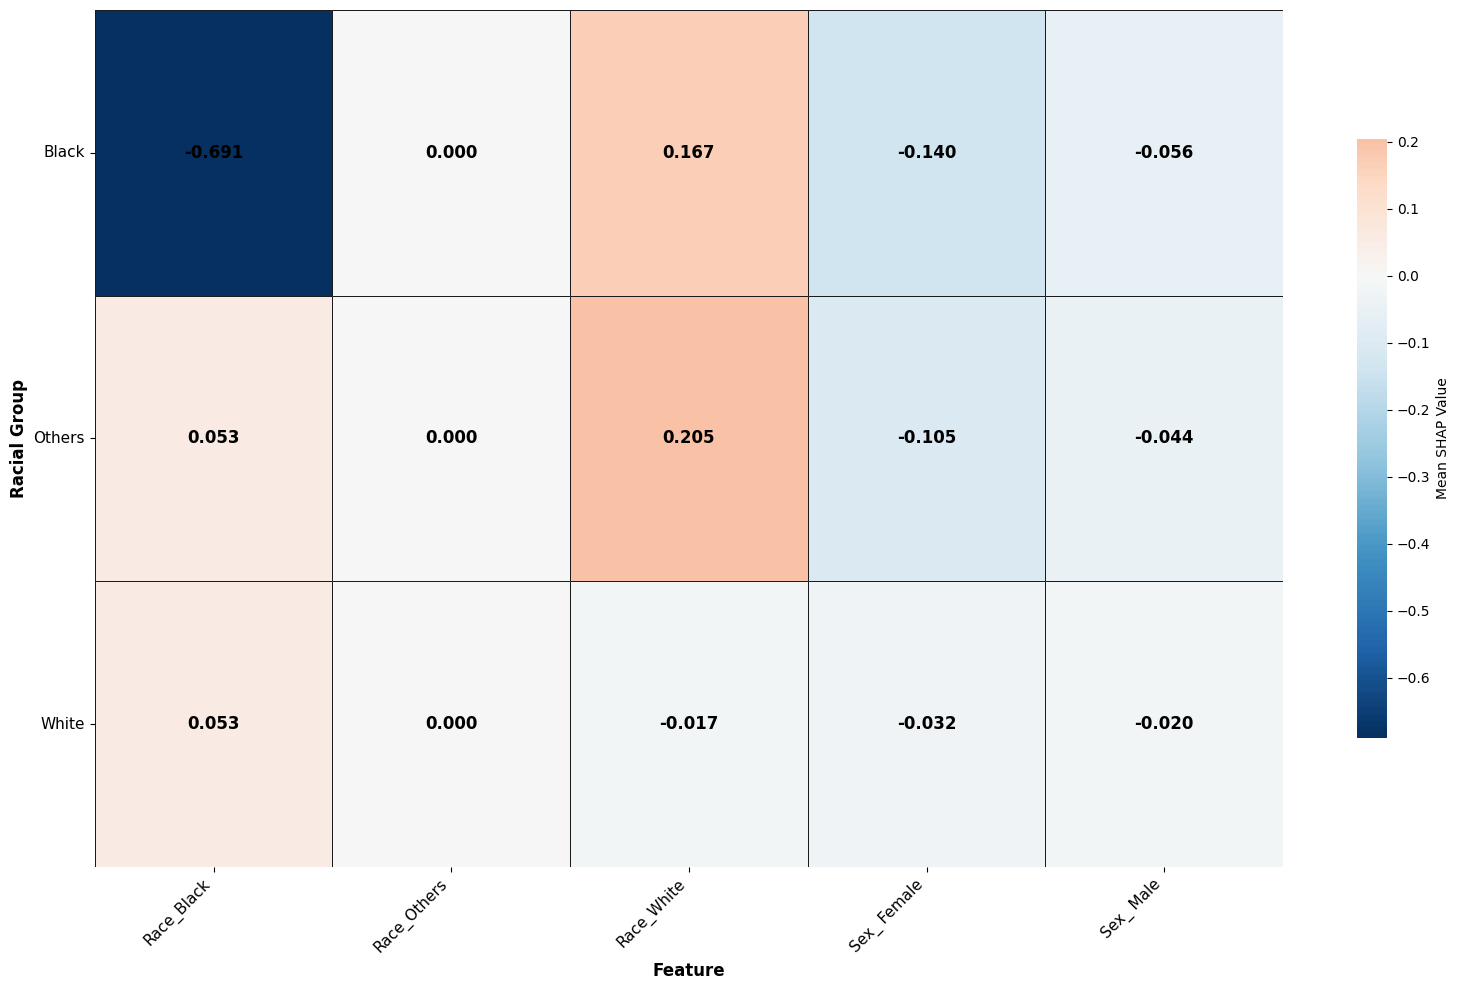


CREATING SEPARATE BAR PLOTS
Absolute influence bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_absolute_adult.png


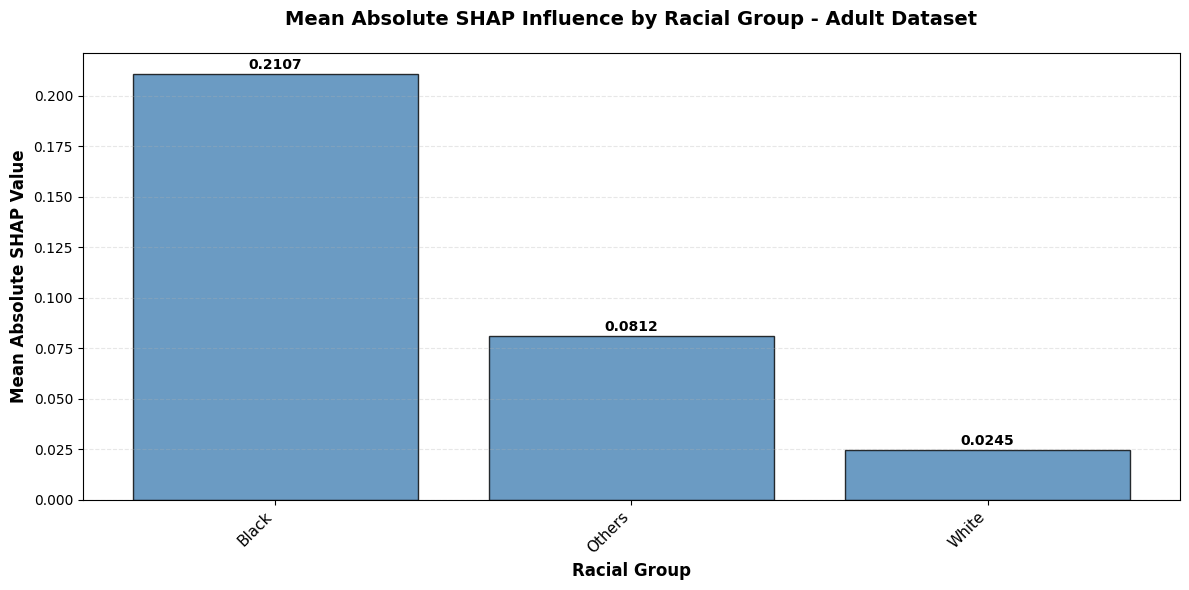

Positive influence bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_positive_adult.png


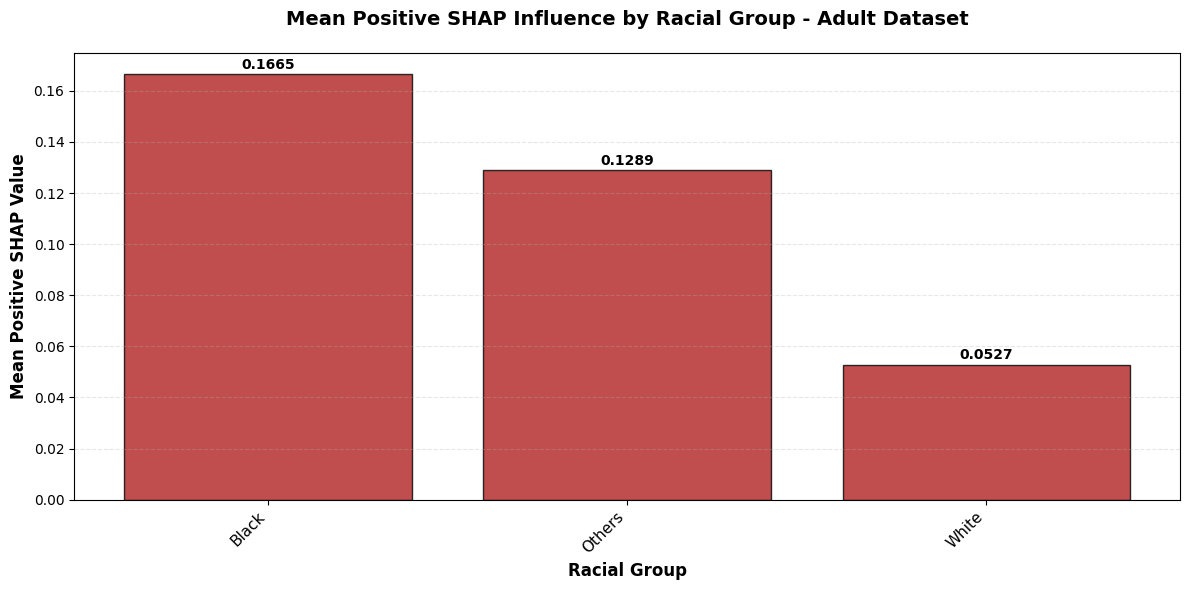

Negative influence bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_negative_adult.png


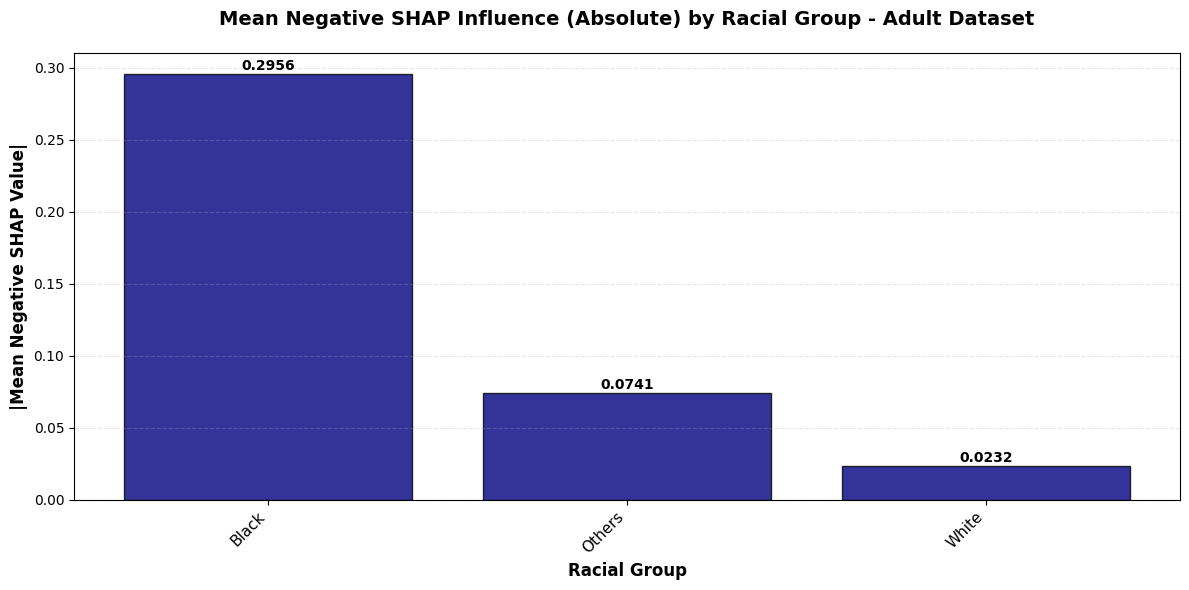

Comparison bar plot saved to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_comparison_adult.png


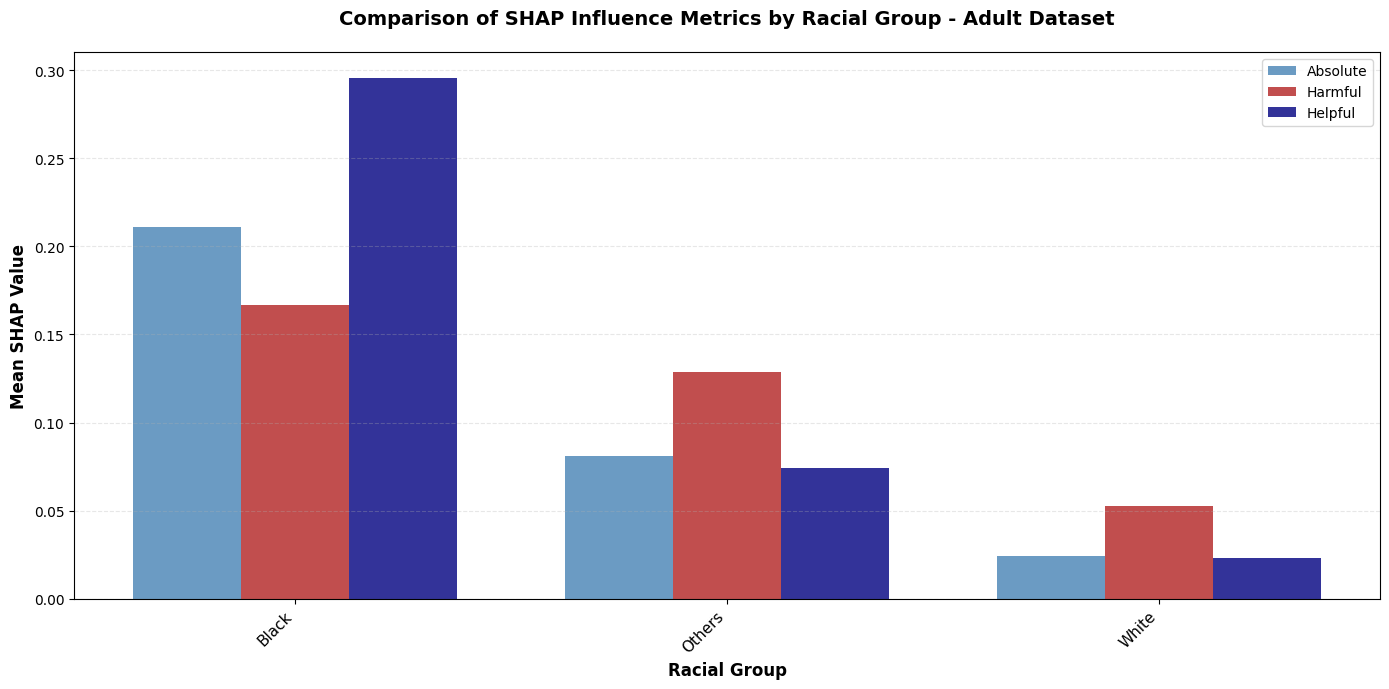


FEATURE CONTRIBUTION PATTERNS
Top features with consistent direction across groups:
  Sex_ Female: Negative
  Sex_ Male: Negative
Total consistent features: 2
Saving comprehensive results to: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/SHAP_Comprehensive_Analysis_Adult.xlsx
Comprehensive analysis saved!

ANALYSIS COMPLETE - FILES GENERATED - ADULT DATASET

Visualizations:
  1. Clear heatmap: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_heatmap_clear_adult.png
  2. Absolute influence bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_absolute_adult.png
  3. Positive influence bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_positive_adult.png
  4. Negative influence bar plot: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult/shap_bar_negative_adult.png
  5. Comparis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats
import matplotlib

# =============================================================================
# 1. LOAD SHAP DATA
# =============================================================================

file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx"  # CHANGED for Adult

print("="*80)
print("SHAP XAI ANALYSIS BY RACIAL GROUP - ADULT DATASET")
print("="*80)

print(f"Loading data from: {file_path}")

if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    exit()

# Load the SHAP data
try:
    xl = pd.ExcelFile(file_path)
    
    # Try to load SHAP sheet
    sheet_name = None
    possible_shap_sheets = ['SHAP_Main_Effects', 'SHAP', 'shap', 'Main_Effects', 'SHAP_values']
    
    for sheet in possible_shap_sheets:
        if sheet in xl.sheet_names:
            sheet_name = sheet
            break
    
    if sheet_name:
        df_shap = pd.read_excel(file_path, sheet_name=sheet_name)
        print(f"Loaded SHAP data from sheet: {sheet_name}")
    else:
        print("ERROR: No SHAP sheet found. Available sheets:")
        for sheet in xl.sheet_names:
            print(f"  - {sheet}")
        exit()
    
except Exception as e:
    print(f"ERROR loading file: {e}")
    exit()

print(f"\nSHAP data shape: {df_shap.shape}")
print(f"Columns: {df_shap.columns.tolist()}")

# =============================================================================
# 2. IDENTIFY RACIAL GROUPS AND PREPARE DATA
# =============================================================================

# Look for race-related columns
race_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
             ['race', 'ethnic', 'demographic', 'group', 'white', 'black', 'others', 'african', 'caucasian', 'hispanic'])]

print(f"Race-related columns found: {race_cols}")

# Check if we have SHAP values
shap_cols = [col for col in df_shap.columns if any(term in col.lower() for term in 
             ['shap', 'value', 'influence', 'effect', 'contribution'])]

if not shap_cols:
    # Assume all numeric columns except ID/metadata are SHAP values
    numeric_cols = df_shap.select_dtypes(include=[np.number]).columns.tolist()
    shap_cols = [col for col in numeric_cols if not any(term in col.lower() for term in 
                ['id', 'index', 'row', 'count', 'total', 'age', 'capital', 'hour', 'target'])]
    print(f"Using numeric columns as SHAP values: {shap_cols[:10]}...")

# Find grouping column
if len(race_cols) > 0:
    group_col = race_cols[0]
    print(f"Using '{group_col}' as grouping column")
else:
    # Look for any categorical column
    cat_cols = df_shap.select_dtypes(include=['object', 'category']).columns.tolist()
    if cat_cols:
        group_col = cat_cols[0]
        print(f"No race column found. Using '{group_col}' as grouping column")
    else:
        group_col = 'Group'
        df_shap[group_col] = 'All'
        print("No grouping column found. Creating 'Group' column")

# Get unique groups
unique_groups = df_shap[group_col].unique()
print(f"Unique groups found: {unique_groups}")
print(f"Number of observations per group:")
for group in unique_groups:
    count = len(df_shap[df_shap[group_col] == group])
    print(f"  {group}: {count} observations")

# =============================================================================
# 3. CALCULATE MEAN SHAP VALUES BY GROUP
# =============================================================================

print("\n" + "="*80)
print("CALCULATING MEAN SHAP VALUES BY GROUP")
print("="*80)

# Calculate mean SHAP values for each group
group_shap_means = {}
group_shap_stds = {}

for group in unique_groups:
    group_data = df_shap[df_shap[group_col] == group]
    
    if len(group_data) > 0:
        group_means = {}
        group_stds = {}
        
        for feature in shap_cols:
            if feature in group_data.columns:
                values = group_data[feature].dropna()
                if len(values) > 0:
                    group_means[feature] = np.mean(values)
                    group_stds[feature] = np.std(values)
        
        group_shap_means[group] = group_means
        group_shap_stds[group] = group_stds
        
        print(f"\n{group} (n={len(group_data)}):")
        print(f"Features with data: {len(group_means)}")
        print(f"Mean SHAP range: [{min(group_means.values()):.4f}, {max(group_means.values()):.4f}]")

# =============================================================================
# 4. ORDER GROUPS BY INFLUENCE METRICS
# =============================================================================

print("\n" + "="*80)
print("ORDERING GROUPS BY INFLUENCE METRICS")
print("="*80)

# Calculate overall influence metrics for each group
group_metrics = {}

for group in group_shap_means:
    means = list(group_shap_means[group].values())
    
    if means:
        # Calculate various metrics
        abs_means = [abs(m) for m in means]
        positive_vals = [m for m in means if m > 0]
        negative_vals = [m for m in means if m < 0]
        
        group_metrics[group] = {
            'mean_abs': np.mean(abs_means),
            'mean_pos': np.mean(positive_vals) if positive_vals else 0,
            'mean_neg': np.mean(negative_vals) if negative_vals else 0,
            'max_pos': max(positive_vals) if positive_vals else 0,
            'min_neg': min(negative_vals) if negative_vals else 0,
            'n_pos': len(positive_vals),
            'n_neg': len(negative_vals),
            'total_features': len(means)
        }

# Sort groups by different metrics
sorted_by_abs = sorted(group_metrics.items(), 
                      key=lambda x: x[1]['mean_abs'], 
                      reverse=True)

sorted_by_pos = sorted(group_metrics.items(),
                      key=lambda x: x[1]['mean_pos'],
                      reverse=True)

sorted_by_neg = sorted(group_metrics.items(),
                      key=lambda x: x[1]['mean_neg'])

print("\nGroups sorted by mean absolute influence:")
for group, metrics in sorted_by_abs:
    print(f"  {group}: {metrics['mean_abs']:.4f}")

print("\nGroups sorted by mean positive influence:")
for group, metrics in sorted_by_pos:
    if metrics['mean_pos'] > 0:
        print(f"  {group}: {metrics['mean_pos']:.4f}")

print("\nGroups sorted by mean negative influence:")
for group, metrics in sorted_by_neg:
    if metrics['mean_neg'] < 0:
        print(f"  {group}: {metrics['mean_neg']:.4f}")

# =============================================================================
# 5. IMPROVED HEATMAP WITH CLEARER ANNOTATIONS
# =============================================================================

print("\n" + "="*80)
print("CREATING HEATMAP WITH CLEAR ANNOTATIONS")
print("="*80)

# Prepare data for heatmap
# Get top 10 features overall by variance across groups
feature_variance = {}
for feature in shap_cols:
    values = []
    for group in group_shap_means:
        if feature in group_shap_means[group]:
            values.append(group_shap_means[group][feature])
    if len(values) > 1:
        feature_variance[feature] = np.var(values)

# Get top 15 features by variance
top_features = sorted(feature_variance.items(), key=lambda x: x[1], reverse=True)[:15]
top_feature_names = [f[0] for f in top_features]

# Create heatmap data
heatmap_data = []
for group in [g[0] for g in sorted_by_abs]:  # Use absolute order
    for feature in top_feature_names:
        if feature in group_shap_means[group]:
            value = group_shap_means[group][feature]
            heatmap_data.append({
                'Group': group,
                'Feature': feature,
                'SHAP_Value': value
            })

heatmap_df = pd.DataFrame(heatmap_data)
pivot_table = heatmap_df.pivot_table(index='Group', columns='Feature', values='SHAP_Value')

# Reorder groups
pivot_table = pivot_table.reindex([g[0] for g in sorted_by_abs])

# Create figure with improved styling
plt.figure(figsize=(16, 10))

# Create custom colormap
cmap = plt.cm.RdBu_r

# Create heatmap with clearer annotations
ax = sns.heatmap(pivot_table,
                 cmap=cmap,
                 center=0,
                 annot=True,
                 fmt='.3f',  # 3 decimal places
                 annot_kws={
                     'size': 12,
                     'weight': 'bold',  # Bold annotations
                     'color': 'black'   # Black text for contrast
                 },
                 linewidths=0.5,
                 linecolor='black', #gray
                 cbar_kws={
                     'label': 'Mean SHAP Value',
                     'shrink': 0.7
                 },
                 square=False)

# Improve readability
plt.title('', #SHAP Explanations by Racial Group (Top 15 Features)
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Feature', fontsize=12, fontweight='bold')
plt.ylabel('Racial Group', fontsize=12, fontweight='bold')

# Rotate feature names for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Add grid lines for better separation
ax.hlines(range(len(pivot_table.index)), *ax.get_xlim(), colors='gray', linewidth=0.5, alpha=0.3)
ax.vlines(range(len(pivot_table.columns)), *ax.get_ylim(), colors='gray', linewidth=0.5, alpha=0.3)

plt.tight_layout()

# Save heatmap
output_dir = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/SHAP_Analysis_Adult"  # CHANGED
os.makedirs(output_dir, exist_ok=True)
heatmap_path = os.path.join(output_dir, "shap_heatmap_clear_adult.png")  # CHANGED
plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
print(f"Clear heatmap saved to: {heatmap_path}")
plt.show()

# =============================================================================
# 6. SEPARATE BAR PLOTS FOR DIFFERENT METRICS
# =============================================================================

print("\n" + "="*80)
print("CREATING SEPARATE BAR PLOTS")
print("="*80)

# Prepare data for bar plots
groups = [g[0] for g in sorted_by_abs]
abs_values = [group_metrics[g]['mean_abs'] for g in groups]
pos_values = [group_metrics[g]['mean_pos'] for g in groups]
neg_values = [group_metrics[g]['mean_neg'] for g in groups]
n_pos = [group_metrics[g]['n_pos'] for g in groups]
n_neg = [group_metrics[g]['n_neg'] for g in groups]

x_pos = np.arange(len(groups))

# 1. BAR PLOT: ABSOLUTE INFLUENCE
plt.figure(figsize=(12, 6))
bars = plt.bar(x_pos, abs_values, color='steelblue', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, abs_values)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('Mean Absolute SHAP Value', fontsize=12, fontweight='bold')
plt.title('Mean Absolute SHAP Influence by Racial Group - Adult Dataset', fontsize=14, fontweight='bold', pad=20)  # CHANGED
plt.xticks(x_pos, groups, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

abs_bar_path = os.path.join(output_dir, "shap_bar_absolute_adult.png")  # CHANGED
plt.savefig(abs_bar_path, dpi=300, bbox_inches='tight')
print(f"Absolute influence bar plot saved to: {abs_bar_path}")
plt.show()

# 2. BAR PLOT: POSITIVE INFLUENCE
plt.figure(figsize=(12, 6))
bars_pos = plt.bar(x_pos, pos_values, color='firebrick', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels
for i, (bar, value) in enumerate(zip(bars_pos, pos_values)):
    if value > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{value:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('Mean Positive SHAP Value', fontsize=12, fontweight='bold')
plt.title('Mean Positive SHAP Influence by Racial Group - Adult Dataset', fontsize=14, fontweight='bold', pad=20)  # CHANGED
plt.xticks(x_pos, groups, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

pos_bar_path = os.path.join(output_dir, "shap_bar_positive_adult.png")  # CHANGED
plt.savefig(pos_bar_path, dpi=300, bbox_inches='tight')
print(f"Positive influence bar plot saved to: {pos_bar_path}")
plt.show()

# 3. BAR PLOT: NEGATIVE INFLUENCE
plt.figure(figsize=(12, 6))
bars_neg = plt.bar(x_pos, [abs(v) for v in neg_values], color='navy', alpha=0.8, edgecolor='black', linewidth=1)

# Add value labels (using absolute values for display)
for i, (bar, value) in enumerate(zip(bars_neg, neg_values)):
    if value < 0:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{abs(value):.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('|Mean Negative SHAP Value|', fontsize=12, fontweight='bold')
plt.title('Mean Negative SHAP Influence (Absolute) by Racial Group - Adult Dataset', fontsize=14, fontweight='bold', pad=20)  # CHANGED
plt.xticks(x_pos, groups, rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

neg_bar_path = os.path.join(output_dir, "shap_bar_negative_adult.png")  # CHANGED
plt.savefig(neg_bar_path, dpi=300, bbox_inches='tight')
print(f"Negative influence bar plot saved to: {neg_bar_path}")
plt.show()

# 4. SIDE-BY-SIDE COMPARISON BAR PLOT
plt.figure(figsize=(14, 7))
bar_width = 0.25

# Create positions for each group
r1 = np.arange(len(groups))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width * 2 for x in r1]

# Create bars
plt.bar(r1, abs_values, width=bar_width, label='Absolute', color='steelblue', alpha=0.8)
plt.bar(r2, pos_values, width=bar_width, label='Harmful', color='firebrick', alpha=0.8)
plt.bar(r3, [abs(v) for v in neg_values], width=bar_width, label='Helpful', color='navy', alpha=0.8)

plt.xlabel('Racial Group', fontsize=12, fontweight='bold')
plt.ylabel('Mean SHAP Value', fontsize=12, fontweight='bold')
plt.title('Comparison of SHAP Influence Metrics by Racial Group - Adult Dataset', fontsize=14, fontweight='bold', pad=20)  # CHANGED
plt.xticks([r + bar_width for r in range(len(groups))], groups, rotation=45, ha='right', fontsize=11)
plt.legend()
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

comparison_path = os.path.join(output_dir, "shap_bar_comparison_adult.png")  # CHANGED
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
print(f"Comparison bar plot saved to: {comparison_path}")
plt.show()

# =============================================================================
# 7. ADDITIONAL ANALYSIS: FEATURE CONTRIBUTION PATTERNS
# =============================================================================

print("\n" + "="*80)
print("FEATURE CONTRIBUTION PATTERNS")
print("="*80)

# Identify features with consistent vs variable patterns
print("Top features with consistent direction across groups:")
consistent_features = []
for feature in shap_cols[:20]:  # Check first 20 features
    directions = []
    for group in groups:
        if feature in group_shap_means[group]:
            value = group_shap_means[group][feature]
            directions.append(1 if value > 0 else -1 if value < 0 else 0)
    
    # Check if all non-zero directions are the same
    non_zero = [d for d in directions if d != 0]
    if len(non_zero) > 0 and all(d == non_zero[0] for d in non_zero):
        consistent_features.append((feature, non_zero[0]))

for feature, direction in consistent_features[:10]:
    print(f"  {feature}: {'Positive' if direction > 0 else 'Negative'}")

print(f"Total consistent features: {len(consistent_features)}")

# =============================================================================
# 8. SAVE COMPREHENSIVE RESULTS
# =============================================================================

output_excel = os.path.join(output_dir, "SHAP_Comprehensive_Analysis_Adult.xlsx")  # CHANGED

print(f"Saving comprehensive results to: {output_excel}")

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:
    # Save group metrics
    metrics_data = []
    for group in groups:
        metrics = group_metrics[group]
        metrics_data.append({
            'Group': group,
            'Mean_Absolute_Influence': metrics['mean_abs'],
            'Mean_Positive_Influence': metrics['mean_pos'],
            'Mean_Negative_Influence': metrics['mean_neg'],
            'Max_Positive': metrics['max_pos'],
            'Min_Negative': metrics['min_neg'],
            'N_Positive_Features': metrics['n_pos'],
            'N_Negative_Features': metrics['n_neg'],
            'Total_Features': metrics['total_features']
        })
    
    metrics_df = pd.DataFrame(metrics_data)
    metrics_df.to_excel(writer, sheet_name='Group_Metrics', index=False)
    
    # Save detailed SHAP values
    detailed_data = []
    for group in groups:
        for feature in shap_cols:
            if feature in group_shap_means[group]:
                detailed_data.append({
                    'Group': group,
                    'Feature': feature,
                    'Mean_SHAP': group_shap_means[group][feature],
                    'Std_SHAP': group_shap_stds[group][feature],
                    'Direction': 'Positive' if group_shap_means[group][feature] > 0 else 'Negative'
                })
    
    detailed_df = pd.DataFrame(detailed_data)
    detailed_df.to_excel(writer, sheet_name='Detailed_SHAP_Values', index=False)
    
    # Save heatmap data
    heatmap_df.to_excel(writer, sheet_name='Heatmap_Data', index=False)
    
    # Save feature variance
    variance_df = pd.DataFrame(list(feature_variance.items()), columns=['Feature', 'Variance'])
    variance_df = variance_df.sort_values('Variance', ascending=False)
    variance_df.to_excel(writer, sheet_name='Feature_Variance', index=False)

print("Comprehensive analysis saved!")
print("\n" + "="*80)
print("ANALYSIS COMPLETE - FILES GENERATED - ADULT DATASET")  # CHANGED
print("="*80)
print(f"\nVisualizations:")
print(f"1. Clear heatmap: {heatmap_path}")
print(f"2. Absolute influence bar plot: {abs_bar_path}")
print(f"3. Positive influence bar plot: {pos_bar_path}")
print(f"4. Negative influence bar plot: {neg_bar_path}")
print(f"5. Comparison bar plot: {comparison_path}")
print(f"Data:")
print(f"6. Comprehensive Excel results: {output_excel}")

In [ ]:
#... Violin plots with external legends ...#

Generating violin boxplots for Adult dataset...



ValueError: zero-size array to reduction operation minimum which has no identity

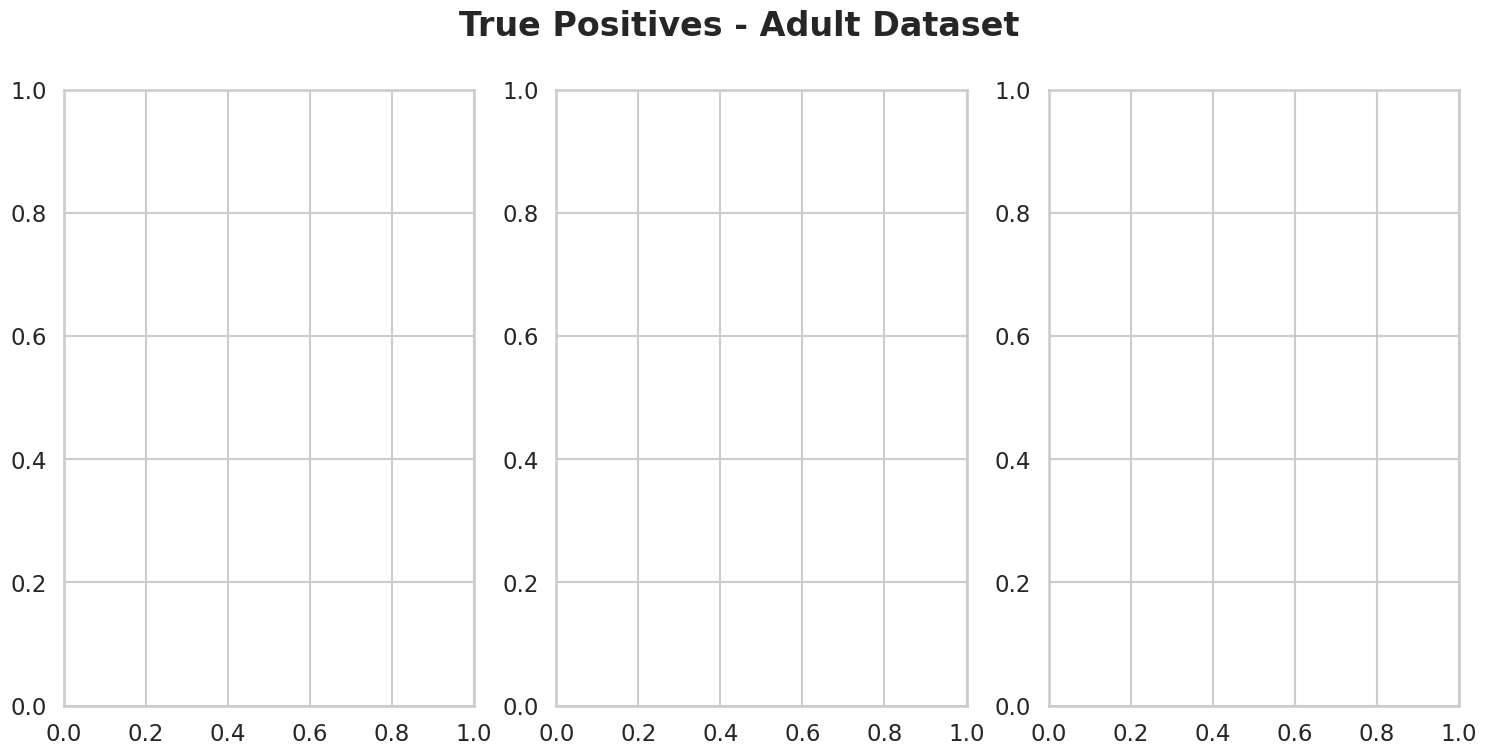

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ========================== LOAD & PREPARE ==========================

file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx"  # CHANGED for Adult
df_influence = pd.read_excel(file_path, sheet_name="Influence_Test_vs_Train")
df_preds     = pd.read_excel(file_path, sheet_name="Predictions_By_Race")
df_preds.columns = df_preds.columns.str.strip()
df_preds = df_preds.rename(columns=lambda x: x.replace('Predicated-Label', 'Predicted_Label'))

def find_id(df):
    for c in df.columns:
        if str(c).lower() in ['id', 'person_id', 'caseid', 'index', 'unnamed: 0']:
            return c
    return df.columns[0]

df_influence = df_influence.rename(columns={find_id(df_influence): 'ID'})
df_preds = df_preds.rename(columns={find_id(df_preds): 'ID'})
df = df_influence.merge(df_preds[['ID', 'Race', 'Actual_Label', 'Predicted_Label']], on='ID', how='inner')

df['Case_Type'] = np.select(
    [(df['Actual_Label']==1) & (df['Predicted_Label']==1),
     (df['Actual_Label']==0) & (df['Predicted_Label']==0),
     (df['Actual_Label']==0) & (df['Predicted_Label']==1),
     (df['Actual_Label']==1) & (df['Predicted_Label']==0)],
    ['TP', 'TN', 'FP', 'FN'], default=None
)

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("talk")

# CHANGED race categories for Adult dataset
races = ['White', 'Black', 'Others']  # Adult dataset races
short = ['W', 'B', 'O']  # Short codes
colors = ['#e6194b', '#4363d8', '#ffe119']  # Adjusted for 3 races
case_names = {'TP': 'True Positives', 'TN': 'True Negatives',
              'FP': 'False Positives', 'FN': 'False Negatives'}

# ========================== VIOLIN BOXPLOT FUNCTION ==========================

def plot_violin_boxplot(case_type):
    """Create violin plots with box plots inside (violin boxplots)."""
    
    # Prepare all data first for consistent scaling
    all_influence_data = []
    for actual_race in races:
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        for p_race in races:
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            all_influence_data.extend(values)
    
    # Calculate overall y limits with some padding
    if all_influence_data:
        y_min = np.min(all_influence_data) * 1.2
        y_max = np.max(all_influence_data) * 1.2
        # Ensure we include zero in the range
        y_min = min(y_min, -0.01) if y_min < 0 else -0.01
        y_max = max(y_max, 0.01) if y_max > 0 else 0.01
    else:
        y_min, y_max = -0.1, 0.1
    
    # Create figure with grid layout (3 subplots for 3 races)
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))  # Changed to 1x3 grid
    axes = axes.flatten()
    
    fig.suptitle(f"{case_names[case_type]} - Adult Dataset",  # CHANGED title
                 fontsize=24, fontweight='bold', y=0.98)
    
    # Store statistics for legend
    all_legend_stats = []
    
    for idx, (ax, actual_race) in enumerate(zip(axes, races)):
        
        # Prepare data for this actual race
        plot_data = []
        stats_list = []
        
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        
        for p_idx, p_race in enumerate(races):
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            
            if len(values) > 0:
                plot_data.append(values)
                mean_val = np.mean(values)
                std_val = np.std(values, ddof=1) if len(values) > 1 else 0
                median_val = np.median(values)
                q1_val = np.percentile(values, 25)
                q3_val = np.percentile(values, 75)
                stats_list.append({
                    'mean': mean_val,
                    'std': std_val,
                    'median': median_val,
                    'q1': q1_val,
                    'q3': q3_val,
                    'n': len(values)
                })
            else:
                plot_data.append([])
                stats_list.append({
                    'mean': 0,
                    'std': 0,
                    'median': 0,
                    'q1': 0,
                    'q3': 0,
                    'n': 0
                })
        
        # Create violin plot with inner boxplot
        positions = range(len(races))
        
        # Create violin plot
        vp = ax.violinplot([d for d in plot_data if len(d) > 0], 
                          positions=[i for i in range(len(races)) if len(plot_data[i]) > 0],
                          showmeans=False, showmedians=False, widths=0.8)
        
        # Color the violins
        for i, pc in enumerate(vp['bodies']):
            actual_idx = [j for j in range(len(races)) if len(plot_data[j]) > 0][i]
            pc.set_facecolor(colors[actual_idx])
            pc.set_alpha(0.5)  # More transparent for box visibility
            pc.set_edgecolor('black')
            pc.set_linewidth(1)
        
        # Add boxplot inside violins
        for i, data in enumerate(plot_data):
            if len(data) > 0:
                # Calculate boxplot statistics
                q1, median, q3 = np.percentile(data, [25, 50, 75])
                iqr = q3 - q1
                lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
                upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])
                
                # Draw box
                box_width = 0.4
                rect = plt.Rectangle((i - box_width/2, q1), box_width, q3 - q1,
                                    facecolor='white', edgecolor='black', 
                                    linewidth=2, alpha=0.9, zorder=10)
                ax.add_patch(rect)
                
                # Draw median line
                ax.plot([i - box_width/2, i + box_width/2], [median, median], 
                       color='red', linewidth=2.5, zorder=11)
                
                # Draw whiskers
                ax.plot([i, i], [lower_whisker, q1], 
                       color='black', linewidth=1.5, linestyle='-', zorder=9)
                ax.plot([i, i], [q3, upper_whisker], 
                       color='black', linewidth=1.5, linestyle='-', zorder=9)
                
                # Draw whisker caps
                cap_width = 0.2
                ax.plot([i - cap_width/2, i + cap_width/2], [lower_whisker, lower_whisker], 
                       color='black', linewidth=1.5, zorder=9)
                ax.plot([i - cap_width/2, i + cap_width/2], [upper_whisker, upper_whisker], 
                       color='black', linewidth=1.5, zorder=9)
                
                # Add mean marker (yellow diamond)
                mean_val = np.mean(data)
                ax.plot(i, mean_val, 'D', color='yellow', markersize=8,
                       markeredgecolor='black', markeredgewidth=1, zorder=12)
        
        # Add individual data points with jitter
        for i, data in enumerate(plot_data):
            if len(data) > 0 and len(data) <= 100:  # Only if not too many points
                jitter = np.random.normal(0, 0.03, len(data))
                ax.scatter(np.full(len(data), i) + jitter, data, 
                          alpha=0.3, s=20, color='gray', edgecolor='none', zorder=5)
        
        # Zero line
        ax.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.6, zorder=1)
        
        # Set labels and ticks
        ax.set_xticks(range(len(races)))
        ax.set_xticklabels([f"{short[idx]}→{short[i]}" for i in range(len(races))],
                          fontsize=14, fontweight='bold')
        ax.set_ylabel('Influence on L(θ)', fontsize=14, fontweight='semibold', labelpad=10)
        
        # Title
        ax.set_title(f"{actual_race}", fontsize=16, fontweight='bold', pad=15)
        
        # Set consistent y limits
        ax.set_ylim(y_min, y_max)
        
        # Grid and frame
        ax.grid(True, axis='y', alpha=0.2, linestyle=':')
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        
        # Store statistics for legend
        all_legend_stats.append(stats_list)
    
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])  # Make room for legend
    
    # ===== CREATE EXTERNAL LEGEND =====
    
    # Create a separate axes for the legend
    legend_ax = fig.add_axes([0.15, 0.02, 0.7, 0.08])
    legend_ax.axis('off')
    
    # Create legend patches with statistics
    legend_patches = []
    legend_labels = []
    
    for i, race in enumerate(races):
        # Calculate average statistics across all subplots for this predicted race
        avg_mean = np.mean([all_legend_stats[j][i]['mean'] for j in range(len(races))])
        avg_std = np.mean([all_legend_stats[j][i]['std'] for j in range(len(races))])
        
        # Format the statistics string
        if abs(avg_mean) < 0.001:
            stat_str = f"{short[i]}: 0.000±{avg_std:.3f}"
        else:
            stat_str = f"{short[i]}: {avg_mean:+.3f}±{avg_std:.3f}"
        
        # Create colored patch
        patch = plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], 
                             edgecolor='black', linewidth=1.5, alpha=0.6)
        legend_patches.append(patch)
        legend_labels.append(stat_str)
    
    # Add mean marker to legend
    mean_patch = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='yellow',
                           markeredgecolor='black', markersize=10, linewidth=0)
    legend_patches.append(mean_patch)
    legend_labels.append("Mean")
    
    # Add median indicator to legend
    median_line = plt.Line2D([0], [0], color='red', linewidth=3)
    legend_patches.append(median_line)
    legend_labels.append("Median")
    
    # Create the legend
    legend = legend_ax.legend(legend_patches, legend_labels,
                             loc='center', ncol=len(legend_patches)//2 + 1,
                             fontsize=12, frameon=True,
                             fancybox=True, edgecolor='black',
                             borderpad=1.2, handletextpad=1.5,
                             columnspacing=2.0)
    
    legend.get_frame().set_linewidth(2)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    # Add title to legend
    legend.set_title("Predicted Race: Mean ± Std | Box: IQR, Line: Median", 
                    prop={'size': 12, 'weight': 'bold'})
    
    # Save the figure
    filename = f"Violin_Boxplot_Adult_{case_type}.png"  # CHANGED filename
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"SAVED: {filename}")
    plt.show()

# ========================== SIMPLIFIED VIOLIN BOXPLOT (using seaborn) ==========================

def plot_violin_boxplot_seaborn(case_type):
    """Simplified version using seaborn's violinplot with inner='box'."""
    
    # Prepare data in long format for seaborn
    plot_data = []
    
    for actual_race in races:
        subset = df[(df['Case_Type'] == case_type) & (df['Race'] == actual_race)]
        
        for p_idx, p_race in enumerate(races):
            cols = [c for c in df.columns if c.endswith(f'_{p_race}_Male') or c.endswith(f'_{p_race}_Female')]
            values = subset[cols].stack().dropna().values
            
            for val in values:
                plot_data.append({
                    'Actual_Race': actual_race,
                    'Predicted_Race': p_race,
                    'Influence': val,
                    'Combination': f"{short[races.index(actual_race)]}→{short[p_idx]}"
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        print(f"No data for {case_type}")
        return
    
    # Create figure with subplots (1x3 for Adult dataset)
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))  # CHANGED to 1x3
    axes = axes.flatten()
    
    fig.suptitle(f"{case_names[case_type]} - Adult Dataset",  # CHANGED title
                 fontsize=24, fontweight='bold', y=0.98)
    
    for idx, (ax, actual_race) in enumerate(zip(axes, races)):
        # Filter data for this actual race
        race_data = plot_df[plot_df['Actual_Race'] == actual_race]
        
        if not race_data.empty:
            # Create violin plot with box inside
            sns.violinplot(data=race_data, x='Combination', y='Influence',
                          ax=ax, inner='box',  # This creates boxplot inside violin
                          palette=colors, saturation=0.7,
                          linewidth=1.5, width=0.8)
            
            # Add mean markers
            means = race_data.groupby('Combination')['Influence'].mean()
            for i, (combo, mean_val) in enumerate(means.items()):
                ax.plot(i, mean_val, 'D', color='yellow', markersize=10,
                       markeredgecolor='black', markeredgewidth=1.5, zorder=10)
        
        # Zero line
        ax.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.6)
        
        # Title and labels
        ax.set_title(f"{actual_race}", fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel('')
        ax.set_ylabel('Influence on L(θ)', fontsize=14, fontweight='semibold')
        
        # Rotate x labels if needed
        ax.tick_params(axis='x', rotation=0)
        
        # Grid
        ax.grid(True, axis='y', alpha=0.2, linestyle=':')
    
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    
    # Save the figure
    filename = f"Violin_Boxplot_Seaborn_Adult_{case_type}.png"  # CHANGED filename
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"SAVED: {filename}")
    plt.show()

# ========================== GENERATE PLOTS ==========================
print("Generating violin boxplots for Adult dataset...\n")

for case in ['TP', 'TN', 'FP', 'FN']:
    # Choose which version to use:
    plot_violin_boxplot(case)  # Custom violin with boxplot inside
    # plot_violin_boxplot_seaborn(case)  # Simplified seaborn version (uncomment to use)

print("All violin boxplots for Adult dataset generated!")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ========================== LOAD & PREPARE ==========================

file_path = "/home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx"
print(f"Loading from: {file_path}")

# First, let's examine the structure of the Excel file
xl = pd.ExcelFile(file_path)
print(f"\nAvailable sheets: {xl.sheet_names}")

# Load the data
df_influence = pd.read_excel(file_path, sheet_name="Influence_Test_vs_Train")
df_preds = pd.read_excel(file_path, sheet_name="Predictions_By_Race")

print(f"\n=== Influence Sheet Shape: {df_influence.shape} ===")
print("First few columns of Influence sheet:")
print(df_influence.columns.tolist()[:20])

print(f"\n=== Predictions Sheet Shape: {df_preds.shape} ===")
print("Predictions sheet columns:")
print(df_preds.columns.tolist())

# Clean column names
df_preds.columns = df_preds.columns.str.strip()
df_preds = df_preds.rename(columns=lambda x: x.replace('Predicated-Label', 'Predicted_Label'))

def find_id(df):
    for c in df.columns:
        if str(c).lower() in ['id', 'person_id', 'caseid', 'index', 'unnamed: 0', 'test_id', 'train_id']:
            return c
    return df.columns[0]

# Find the ID column in influence sheet
print(f"\nLooking for ID column in influence sheet...")
id_col_influence = find_id(df_influence)
print(f"Using '{id_col_influence}' as ID column in influence sheet")

# Find the ID column in predictions sheet
id_col_preds = find_id(df_preds)
print(f"Using '{id_col_preds}' as ID column in predictions sheet")

df_influence = df_influence.rename(columns={id_col_influence: 'ID'})
df_preds = df_preds.rename(columns={id_col_preds: 'ID'})

print(f"\nMerging dataframes...")
df = df_influence.merge(df_preds[['ID', 'Race', 'Actual_Label', 'Predicted_Label']], on='ID', how='inner')
print(f"Merged dataframe shape: {df.shape}")

# Create case types
df['Case_Type'] = np.select(
    [(df['Actual_Label']==1) & (df['Predicted_Label']==1),
     (df['Actual_Label']==0) & (df['Predicted_Label']==0),
     (df['Actual_Label']==0) & (df['Predicted_Label']==1),
     (df['Actual_Label']==1) & (df['Predicted_Label']==0)],
    ['TP', 'TN', 'FP', 'FN'], default=None
)

print(f"\n=== Data Summary ===")
print(f"Total merged rows: {len(df)}")
print(f"Case Type distribution:")
for case in ['TP', 'TN', 'FP', 'FN']:
    count = len(df[df['Case_Type'] == case])
    print(f"  {case}: {count} instances")

# Show column names to understand the structure
print(f"\n=== Column Analysis ===")
print(f"Total columns: {len(df.columns)}")
print(f"First 30 columns: {df.columns.tolist()[:30]}")
print(f"\nColumns containing 'Race': {[c for c in df.columns if 'Race' in str(c)]}")
print(f"Columns containing 'Sex': {[c for c in df.columns if 'Sex' in str(c)]}")

# Let's look at the actual column names that contain race information
print(f"\n=== Sample column names that might be influence columns ===")
influence_cols = []
for col in df.columns:
    if col not in ['ID', 'Race', 'Actual_Label', 'Predicted_Label', 'Case_Type']:
        influence_cols.append(col)
        
print(f"Found {len(influence_cols)} potential influence columns")
print(f"Sample influence columns:")
for col in influence_cols[:20]:
    print(f"  {col}")

# ========================== FIXED: IDENTIFY RACE AND SEX IN COLUMN NAMES ==========================

# Set seaborn style
sns.set_style("whitegrid")
sns.set_context("talk")

# CHANGED race categories for Adult dataset
races = ['White', 'Black', 'Others']  # Adult dataset races
short = ['W', 'B', 'O']  # Short codes
colors = ['#e6194b', '#4363d8', '#ffe119']  # Adjusted for 3 races
case_names = {'TP': 'True Positives', 'TN': 'True Negatives',
              'FP': 'False Positives', 'FN': 'False Negatives'}

# Let's examine a sample column name to understand the pattern
print(f"\n=== Analyzing column name pattern ===")
sample_cols = [c for c in df.columns if isinstance(c, str) and c.startswith('ID')][:5]
for col in sample_cols:
    print(f"Sample column: {col}")
    
# Based on the pattern, let's extract race and sex from column names
def extract_race_sex_from_column(col_name):
    """Extract race and sex from column names like 'ID12345_White_Male'"""
    if not isinstance(col_name, str):
        return None, None
    
    parts = str(col_name).split('_')
    if len(parts) >= 3:
        # Format: ID{number}_{Race}_{Sex}
        race = parts[1] if len(parts) > 1 else None
        sex = parts[2] if len(parts) > 2 else None
        return race, sex
    elif len(parts) == 2:
        # Format: ID{number}_{Race}
        race = parts[1]
        return race, 'Unknown'
    else:
        return None, None

# Test the extraction
print(f"\n=== Testing column name extraction ===")
test_cols = [c for c in df.columns if isinstance(c, str)][:10]
for col in test_cols:
    race, sex = extract_race_sex_from_column(col)
    print(f"{col} -> Race: {race}, Sex: {sex}")

# ========================== FIXED VIOLIN BOXPLOT FUNCTION ==========================

def plot_violin_boxplot_fixed(case_type):
    """Fixed version that properly identifies influence columns."""
    
    print(f"\n{'='*60}")
    print(f"Creating plot for {case_type} ({case_names[case_type]})")
    print(f"{'='*60}")
    
    # Filter data for this case type
    subset = df[df['Case_Type'] == case_type]
    print(f"Found {len(subset)} instances for {case_type}")
    
    if len(subset) == 0:
        print(f"No data for {case_type}")
        return
    
    # Prepare all data first for consistent scaling
    all_influence_data = []
    
    # Collect all influence values to determine y-axis limits
    for col in influence_cols:
        values = subset[col].dropna().values
        if len(values) > 0:
            all_influence_data.extend(values)
    
    if not all_influence_data:
        print(f"No influence data found for {case_type}")
        print("Available columns that might contain influence data:")
        for col in df.columns[:20]:
            if col not in ['ID', 'Race', 'Actual_Label', 'Predicted_Label', 'Case_Type']:
                non_null = subset[col].notna().sum()
                if non_null > 0:
                    print(f"  {col}: {non_null} non-null values")
        return
    
    print(f"Total influence values: {len(all_influence_data)}")
    print(f"Influence value range: [{np.min(all_influence_data):.6f}, {np.max(all_influence_data):.6f}]")
    
    # Calculate overall y limits with some padding
    y_min = np.min(all_influence_data) * 1.2
    y_max = np.max(all_influence_data) * 1.2
    # Ensure we include zero in the range
    y_min = min(y_min, -0.01) if y_min < 0 else -0.01
    y_max = max(y_max, 0.01) if y_max > 0 else 0.01
    
    print(f"Y-axis limits: [{y_min:.6f}, {y_max:.6f}]")
    
    # Create figure with grid layout (3 subplots for 3 races)
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    axes = axes.flatten()
    
    fig.suptitle(f"{case_names[case_type]} - Adult Dataset", 
                 fontsize=24, fontweight='bold', y=0.98)
    
    # Store statistics for legend
    all_legend_stats = []
    
    for idx, (ax, actual_race) in enumerate(zip(axes, races)):
        
        print(f"\nProcessing {actual_race}...")
        
        # Filter for this actual race
        race_subset = subset[subset['Race'] == actual_race]
        print(f"  Found {len(race_subset)} instances for {actual_race}")
        
        # Prepare data for this actual race
        plot_data = []
        stats_list = []
        
        for p_idx, p_race in enumerate(races):
            # Find columns for this predicted race
            # Look for columns containing the predicted race
            matching_cols = []
            for col in influence_cols:
                race_from_col, sex_from_col = extract_race_sex_from_column(col)
                if race_from_col == p_race:
                    matching_cols.append(col)
            
            print(f"  {actual_race}→{p_race}: Found {len(matching_cols)} matching columns")
            
            if matching_cols:
                # Get all values from matching columns
                values = []
                for col in matching_cols:
                    col_values = race_subset[col].dropna().values
                    if len(col_values) > 0:
                        values.extend(col_values)
                
                if len(values) > 0:
                    plot_data.append(values)
                    mean_val = np.mean(values)
                    std_val = np.std(values, ddof=1) if len(values) > 1 else 0
                    median_val = np.median(values)
                    q1_val = np.percentile(values, 25) if len(values) >= 4 else np.median(values)
                    q3_val = np.percentile(values, 75) if len(values) >= 4 else np.median(values)
                    
                    stats_list.append({
                        'mean': mean_val,
                        'std': std_val,
                        'median': median_val,
                        'q1': q1_val,
                        'q3': q3_val,
                        'n': len(values)
                    })
                    print(f"    Values: {len(values)}, Mean: {mean_val:.6f}, Std: {std_val:.6f}")
                else:
                    plot_data.append([])
                    stats_list.append({
                        'mean': 0,
                        'std': 0,
                        'median': 0,
                        'q1': 0,
                        'q3': 0,
                        'n': 0
                    })
                    print(f"    No values found")
            else:
                plot_data.append([])
                stats_list.append({
                    'mean': 0,
                    'std': 0,
                    'median': 0,
                    'q1': 0,
                    'q3': 0,
                    'n': 0
                })
                print(f"    No matching columns found")
        
        # Filter out empty arrays for violin plot
        valid_data = [d for d in plot_data if len(d) > 0]
        valid_positions = [i for i, d in enumerate(plot_data) if len(d) > 0]
        
        if len(valid_data) > 0:
            # Create violin plot
            vp = ax.violinplot(valid_data, 
                              positions=valid_positions,
                              showmeans=False, showmedians=False, widths=0.8)
            
            # Color the violins
            for i, pc in enumerate(vp['bodies']):
                actual_idx = valid_positions[i]
                pc.set_facecolor(colors[actual_idx])
                pc.set_alpha(0.5)
                pc.set_edgecolor('black')
                pc.set_linewidth(1)
        else:
            print(f"  No valid data for violin plot")
        
        # Add boxplot inside violins only for non-empty data
        for i, data in enumerate(plot_data):
            if len(data) > 1:
                # Calculate boxplot statistics
                q1, median, q3 = np.percentile(data, [25, 50, 75])
                iqr = q3 - q1
                
                # Handle whiskers
                if len(data) > 5:
                    lower_whisker = np.min(data[data >= q1 - 1.5 * iqr])
                    upper_whisker = np.max(data[data <= q3 + 1.5 * iqr])
                else:
                    lower_whisker = np.min(data)
                    upper_whisker = np.max(data)
                
                # Draw box
                box_width = 0.4
                rect = plt.Rectangle((i - box_width/2, q1), box_width, q3 - q1,
                                    facecolor='white', edgecolor='black', 
                                    linewidth=2, alpha=0.9, zorder=10)
                ax.add_patch(rect)
                
                # Draw median line
                ax.plot([i - box_width/2, i + box_width/2], [median, median], 
                       color='red', linewidth=2.5, zorder=11)
                
                # Draw whiskers
                ax.plot([i, i], [lower_whisker, q1], 
                       color='black', linewidth=1.5, linestyle='-', zorder=9)
                ax.plot([i, i], [q3, upper_whisker], 
                       color='black', linewidth=1.5, linestyle='-', zorder=9)
                
                # Draw whisker caps
                cap_width = 0.2
                ax.plot([i - cap_width/2, i + cap_width/2], [lower_whisker, lower_whisker], 
                       color='black', linewidth=1.5, zorder=9)
                ax.plot([i - cap_width/2, i + cap_width/2], [upper_whisker, upper_whisker], 
                       color='black', linewidth=1.5, zorder=9)
                
                # Add mean marker (yellow diamond)
                mean_val = np.mean(data)
                ax.plot(i, mean_val, 'D', color='yellow', markersize=8,
                       markeredgecolor='black', markeredgewidth=1, zorder=12)
        
        # Zero line
        ax.axhline(y=0, color='black', linewidth=2, linestyle='--', alpha=0.6, zorder=1)
        
        # Set labels and ticks
        ax.set_xticks(range(len(races)))
        ax.set_xticklabels([f"{short[idx]}→{short[i]}" for i in range(len(races))],
                          fontsize=14, fontweight='bold')
        ax.set_ylabel('Influence on L(θ)', fontsize=14, fontweight='semibold', labelpad=10)
        
        # Title
        ax.set_title(f"{actual_race}", fontsize=16, fontweight='bold', pad=15)
        
        # Set consistent y limits
        ax.set_ylim(y_min, y_max)
        
        # Grid and frame
        ax.grid(True, axis='y', alpha=0.2, linestyle=':')
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
        
        all_legend_stats.append(stats_list)
    
    plt.tight_layout(rect=[0, 0.1, 1, 0.95])
    
    # Create legend
    legend_ax = fig.add_axes([0.15, 0.02, 0.7, 0.08])
    legend_ax.axis('off')
    
    legend_patches = []
    legend_labels = []
    
    for i, race in enumerate(races):
        # Calculate average statistics
        valid_means = [all_legend_stats[j][i]['mean'] for j in range(len(races)) 
                      if all_legend_stats[j][i]['n'] > 0]
        
        if valid_means:
            avg_mean = np.mean(valid_means)
            avg_std = np.mean([all_legend_stats[j][i]['std'] for j in range(len(races)) 
                             if all_legend_stats[j][i]['n'] > 0])
            
            if abs(avg_mean) < 0.001:
                stat_str = f"{short[i]}: 0.000±{avg_std:.3f}"
            else:
                stat_str = f"{short[i]}: {avg_mean:+.3f}±{avg_std:.3f}"
        else:
            stat_str = f"{short[i]}: No data"
        
        patch = plt.Rectangle((0, 0), 1, 1, facecolor=colors[i], 
                             edgecolor='black', linewidth=1.5, alpha=0.6)
        legend_patches.append(patch)
        legend_labels.append(stat_str)
    
    # Add mean marker to legend
    mean_patch = plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='yellow',
                           markeredgecolor='black', markersize=10, linewidth=0)
    legend_patches.append(mean_patch)
    legend_labels.append("Mean")
    
    # Add median indicator to legend
    median_line = plt.Line2D([0], [0], color='red', linewidth=3)
    legend_patches.append(median_line)
    legend_labels.append("Median")
    
    # Create the legend
    legend = legend_ax.legend(legend_patches, legend_labels,
                             loc='center', ncol=len(legend_patches)//2 + 1,
                             fontsize=12, frameon=True,
                             fancybox=True, edgecolor='black',
                             borderpad=1.2, handletextpad=1.5,
                             columnspacing=2.0)
    
    legend.get_frame().set_linewidth(2)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    legend.set_title("Predicted Race: Mean ± Std | Box: IQR, Line: Median", 
                    prop={'size': 12, 'weight': 'bold'})
    
    # Save the figure
    filename = f"Violin_Boxplot_Adult_{case_type}.png"
    plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
    print(f"\n✓ SAVED: {filename}")
    plt.show()

# ========================== GENERATE PLOTS ==========================
print("\n" + "="*80)
print("GENERATING VIOLIN BOXPLOTS FOR ADULT DATASET")
print("="*80)

# Generate plots for all case types
for case in ['TP', 'TN', 'FP', 'FN']:
    plot_violin_boxplot_fixed(case)

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

Loading from: /home/ojoak/ProjectWorks/ProjectCode/Project_code/MLLS Hackaton/results_adult_downsample.xlsx

Available sheets: ['Predictions_By_Race', 'Influence_Test_vs_Train', 'CrossGroup_Means_Race', 'CrossGroup_Means_Inter', 'SHAP_Sex_Summary', 'SHAP_Race_Summary', 'SHAP_Numeric_Summary', 'Permutation_Pvalues_Race', 'Permutation_Pvalues_Inter', 'Top10_Black_to_White', 'SHAP_Main_Effects', 'Inter_ID29727_White', 'Inter_ID40561_White', 'Inter_ID24982_White', 'Inter_ID19083_White', 'Inter_ID12924_White', 'Model_Performance', 'Feature_Info', 'Fairness_Metrics', 'Fairness_Metrics_Inter', 'Fairness_Decomposition', 'Mitigated_Performance', 'Mitigated_Fairness', 'Mitigated_Fairness_Inter', 'Mitigated_SHAP_Race', 'Mitigated_SHAP_Main_Effects', 'Mitigated_Inter_ID29727_White', 'Mitigated_Inter_ID40561_White', 'Mitigated_Inter_ID24982_White', 'Mitigated_Inter_ID19083_White', 'Mitigated_Inter_ID12924_White']

=== Influence Sheet Shape: (1400, 4483) ===
First few columns of Influence sheet:
['T

UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U32'), dtype('<U32')) -> None